<a href="https://colab.research.google.com/github/jamesbr4/MVP_Analise_de_Dados_e_Boas_Praticas/blob/main/MVP_An%C3%A1lise_de_Dados_e_Boas_Pr%C3%A1ticas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1><b>MVP Análise de Dados e Boas Práticas</b></h1>

<b>Nome:</b>  James Bispo da Silva Reis

<b>Matrícula (RA):</b>  4052024002168

<b>Dataset:</b>  [Preços de matérias-primas agrícolas (1990-2020)](https://www.kaggle.com/datasets/kianwee/agricultural-raw-material-prices-19902020?resource=download)

<h1><b>Importação das Bibliotecas Necessárias e Carga de Dados</b></h1>

In [49]:
#importando bibliotecas
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import random as random
%matplotlib inline
sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (9, 5)
matplotlib.rcParams['figure.facecolor'] = '#00000000'
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [50]:
# Importando dataset do meu repository do github
url = "https://raw.githubusercontent.com/jamesbr4/MVP_Analise_de_Dados_e_Boas_Praticas/refs/heads/main/agricultural_raw_material.csv"
materiaPrima = pd.read_csv(url)
#Verificando o inicio do dataset
materiaPrima.head()

,Month,Coarse wool Price,Coarse wool price % Change,Copra Price,Copra price % Change,Cotton Price,Cotton price % Change,Fine wool Price,Fine wool price % Change,Hard log Price,...,Plywood Price,Plywood price % Change,Rubber Price,Rubber price % Change,Softlog Price,Softlog price % Change,Soft sawnwood Price,Soft sawnwood price % Change,Wood pulp Price,Wood pulp price % Change
0,Apr-90,482.34,-,236,-,1.83,-,"1,071.63",-,161.20,...,312.36,-,0.84,-,120.66,-,218.76,-,829.29,-
1,May-90,447.26,-7.27%,234,-0.85%,1.89,3.28%,"1,057.18",-1.35%,172.86,...,350.12,12.09%,0.85,1.19%,124.28,3.00%,213.00,-2.63%,842.51,1.59%
2,Jun-90,440.99,-1.40%,216,-7.69%,1.99,5.29%,898.24,-15.03%,181.67,...,373.94,6.80%,0.85,0.00%,129.45,4.16%,200.00,-6.10%,831.35,-1.32%
3,Jul-90,418.44,-5.11%,205,-5.09%,2.01,1.01%,895.83,-0.27%,187.96,...,378.48,1.21%,0.86,1.18%,124.23,-4.03%,210.05,5.03%,798.83,-3.91%
4,Aug-90,418.44,0.00%,198,-3.41%,1.79,-10.95%,951.22,6.18%,186.13,...,364.60,-3.67%,0.88,2.33%,129.70,4.40%,208.30,-0.83%,818.74,2.49%


In [51]:
#Verificando o fim do dataset
materiaPrima.tail()

,Month,Coarse wool Price,Coarse wool price % Change,Copra Price,Copra price % Change,Cotton Price,Cotton price % Change,Fine wool Price,Fine wool price % Change,Hard log Price,...,Plywood Price,Plywood price % Change,Rubber Price,Rubber price % Change,Softlog Price,Softlog price % Change,Soft sawnwood Price,Soft sawnwood price % Change,Wood pulp Price,Wood pulp price % Change
356,Dec-19,NaN,NaN,NaN,NaN,1.67,1.21%,NaN,NaN,272.80,...,500.37,-0.22%,1.66,7.79%,NaN,NaN,NaN,NaN,875.0,0.00%
357,Jan-20,NaN,NaN,NaN,NaN,1.74,4.19%,NaN,NaN,272.40,...,499.64,-0.15%,1.68,1.20%,NaN,NaN,NaN,NaN,875.0,0.00%
358,Feb-20,NaN,NaN,NaN,NaN,1.69,-2.87%,NaN,NaN,270.56,...,496.28,-0.67%,1.61,-4.17%,NaN,NaN,NaN,NaN,875.0,0.00%
359,Mar-20,NaN,NaN,NaN,NaN,1.49,-11.83%,NaN,NaN,276.93,...,507.96,2.35%,1.50,-6.83%,NaN,NaN,NaN,NaN,875.0,0.00%
360,Apr-20,NaN,NaN,NaN,NaN,1.40,-6.04%,NaN,NaN,276.24,...,506.68,-0.25%,1.33,-11.33%,NaN,NaN,NaN,NaN,NaN,NaN


Observamos que as colunas estão em inglês, temos porcentagens negativas (assumirei que tenha somente positivas), valores NaN e preços com vírgulas.

<h1><b> Explorando o conjunto de dados - Análise dos dados</b></h1>

In [52]:
# Verifica as informações das colunas do dataset
materiaPrima.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 361 entries, 0 to 360
Data columns (total 25 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Month                         361 non-null    object 
 1   Coarse wool Price             327 non-null    object 
 2   Coarse wool price % Change    327 non-null    object 
 3   Copra Price                   339 non-null    object 
 4   Copra price % Change          339 non-null    object 
 5   Cotton Price                  361 non-null    float64
 6   Cotton price % Change         361 non-null    object 
 7   Fine wool Price               327 non-null    object 
 8   Fine wool price % Change      327 non-null    object 
 9   Hard log Price                361 non-null    float64
 10  Hard log price % Change       361 non-null    object 
 11  Hard sawnwood Price           327 non-null    float64
 12  Hard sawnwood price % Change  327 non-null    object 
 13  Hide 

Verificamos que o tipo da maioria das colunas estão como 'object' e 'float64'.

In [53]:
#Verificando valores nulos de cada coluna
materiaPrima.isnull().sum()

,0
Month,0
Coarse wool Price,34
Coarse wool price % Change,34
Copra Price,22
Copra price % Change,22
Cotton Price,0
Cotton price % Change,0
Fine wool Price,34
Fine wool price % Change,34
Hard log Price,0


Podemos verificar com o resultado acima que temos diversos valores nulos nas colunas. Optarei por remove-los, pois gostaria de fazer uma análise com os dados reais do dataset.

<h1><b> Tratando os dados do dataset </b></h1>

In [54]:
# Trocando %, "," , "-", NaN e nomes
materiaPrima = materiaPrima.replace('%', '', regex=True)
materiaPrima = materiaPrima.replace(',', '', regex=True)
materiaPrima = materiaPrima.replace('-', '', regex=True)
materiaPrima = materiaPrima.replace('', np.nan)
materiaPrima = materiaPrima.rename(columns={'Month' : 'Mês'})
materiaPrima = materiaPrima.rename(columns={'Coarse wool Price': 'Preço da lã grossa'})
materiaPrima = materiaPrima.rename(columns={'Coarse wool price % Change' : 'Preço da lã grossa % Variação'})
materiaPrima = materiaPrima.rename(columns={'Copra Price': 'Preço Copra'})
materiaPrima = materiaPrima.rename(columns={'Copra price % Change': 'Preço da Copra % Variação'})
materiaPrima = materiaPrima.rename(columns={'Cotton Price': 'Preço do algodão'})
materiaPrima = materiaPrima.rename(columns={'Cotton price % Change': 'Preço do algodão % Variação'})
materiaPrima = materiaPrima.rename(columns={'Fine wool Price': 'Preço de lã fina'})
materiaPrima = materiaPrima.rename(columns={'Fine wool price % Change': 'Preço de lã fina % Variação'})
materiaPrima = materiaPrima.rename(columns={'Hard log Price': 'Preço da tora dura'})
materiaPrima = materiaPrima.rename(columns={'Hard log price % Change': 'Preço da tora dura % Variação'})
materiaPrima = materiaPrima.rename(columns={'Hard sawnwood Price': 'Preço da madeira serrada dura'})
materiaPrima = materiaPrima.rename(columns={'Hard sawnwood price % Change': 'Preço da madeira serrada dura % Variação'})
materiaPrima = materiaPrima.rename(columns={'Hide Price': 'Preço do couro'})
materiaPrima = materiaPrima.rename(columns={'Hide price % change': 'Preço do couro % Variação'})
materiaPrima = materiaPrima.rename(columns={'Plywood Price': 'Preço da madeira compensada'})
materiaPrima = materiaPrima.rename(columns={'Plywood price % Change': 'Preço da madeira compensada % Variação'})
materiaPrima = materiaPrima.rename(columns={'Rubber Price': 'Preço da borracha'})
materiaPrima = materiaPrima.rename(columns={'Rubber price % Change': 'Preço da borracha % Variação'})
materiaPrima = materiaPrima.rename(columns={'Softlog Price': 'Preço da lenha'})
materiaPrima = materiaPrima.rename(columns={'Softlog price % Change': 'Preço da lenha % Variação'})
materiaPrima = materiaPrima.rename(columns={'Soft sawnwood Price': 'Preço da madeira serrada macia'})
materiaPrima = materiaPrima.rename(columns={'Soft sawnwood price % Change': 'Preço da madeira serrada macia % Variação'})
materiaPrima = materiaPrima.rename(columns={'Wood pulp Price': 'Preço da polpa de madeira'})
materiaPrima = materiaPrima.rename(columns={'Wood pulp price % Change': 'Preço da polpa de madeira % Variação'})

# Verificando o dataset após alterações
materiaPrima.head()

,Mês,Preço da lã grossa,Preço da lã grossa % Variação,Preço Copra,Preço da Copra % Variação,Preço do algodão,Preço do algodão % Variação,Preço de lã fina,Preço de lã fina % Variação,Preço da tora dura,...,Preço da madeira compensada,Preço da madeira compensada % Variação,Preço da borracha,Preço da borracha % Variação,Preço da lenha,Preço da lenha % Variação,Preço da madeira serrada macia,Preço da madeira serrada macia % Variação,Preço da polpa de madeira,Preço da polpa de madeira % Variação
0,Apr90,482.34,NaN,236,NaN,1.83,NaN,1071.63,NaN,161.20,...,312.36,NaN,0.84,NaN,120.66,NaN,218.76,NaN,829.29,NaN
1,May90,447.26,7.27,234,0.85,1.89,3.28,1057.18,1.35,172.86,...,350.12,12.09,0.85,1.19,124.28,3.00,213.00,2.63,842.51,1.59
2,Jun90,440.99,1.40,216,7.69,1.99,5.29,898.24,15.03,181.67,...,373.94,6.80,0.85,0.00,129.45,4.16,200.00,6.10,831.35,1.32
3,Jul90,418.44,5.11,205,5.09,2.01,1.01,895.83,0.27,187.96,...,378.48,1.21,0.86,1.18,124.23,4.03,210.05,5.03,798.83,3.91
4,Aug90,418.44,0.00,198,3.41,1.79,10.95,951.22,6.18,186.13,...,364.60,3.67,0.88,2.33,129.70,4.40,208.30,0.83,818.74,2.49


In [55]:
# Descartando linhas com valores NaN
materiaPrima = materiaPrima.dropna()

In [56]:
# Verificando se todos os valores NaN foram resolvidos
materiaPrima.isnull().sum()

,0
Mês,0
Preço da lã grossa,0
Preço da lã grossa % Variação,0
Preço Copra,0
Preço da Copra % Variação,0
Preço do algodão,0
Preço do algodão % Variação,0
Preço de lã fina,0
Preço de lã fina % Variação,0
Preço da tora dura,0


Verificamos que não há mais dados nulos no dataset.

In [57]:
# Convertendo tipo de dados de int para float
lst = ["Preço da lã grossa", "Preço da lã grossa % Variação", "Preço Copra", "Preço da Copra % Variação", "Preço do algodão", "Preço do algodão % Variação","Preço de lã fina", "Preço de lã fina % Variação",
"Preço da tora dura", "Preço da tora dura % Variação", "Preço da madeira serrada dura", "Preço da madeira serrada dura % Variação", "Preço do couro", "Preço do couro % Variação", "Preço da madeira compensada",
"Preço da madeira compensada % Variação", "Preço da borracha", "Preço da borracha % Variação", "Preço da lenha",  "Preço da lenha % Variação", "Preço da madeira serrada macia", "Preço da madeira serrada macia % Variação",
"Preço da polpa de madeira", "Preço da polpa de madeira % Variação"]
materiaPrima[lst] = materiaPrima[lst].astype("float")
materiaPrima.dtypes

,0
Mês,object
Preço da lã grossa,float64
Preço da lã grossa % Variação,float64
Preço Copra,float64
Preço da Copra % Variação,float64
Preço do algodão,float64
Preço do algodão % Variação,float64
Preço de lã fina,float64
Preço de lã fina % Variação,float64
Preço da tora dura,float64


Converti as colunas numéricas para 'float64' por se tratar de valores de porcentagem e dinheiro.

In [59]:
#Verificando como ficou o inicio do dataset
materiaPrima.head()

,Mês,Preço da lã grossa,Preço da lã grossa % Variação,Preço Copra,Preço da Copra % Variação,Preço do algodão,Preço do algodão % Variação,Preço de lã fina,Preço de lã fina % Variação,Preço da tora dura,...,Preço da madeira compensada,Preço da madeira compensada % Variação,Preço da borracha,Preço da borracha % Variação,Preço da lenha,Preço da lenha % Variação,Preço da madeira serrada macia,Preço da madeira serrada macia % Variação,Preço da polpa de madeira,Preço da polpa de madeira % Variação
1,May90,447.26,7.27,234.0,0.85,1.89,3.28,1057.18,1.35,172.86,...,350.12,12.09,0.85,1.19,124.28,3.00,213.00,2.63,842.51,1.59
2,Jun90,440.99,1.40,216.0,7.69,1.99,5.29,898.24,15.03,181.67,...,373.94,6.80,0.85,0.00,129.45,4.16,200.00,6.10,831.35,1.32
3,Jul90,418.44,5.11,205.0,5.09,2.01,1.01,895.83,0.27,187.96,...,378.48,1.21,0.86,1.18,124.23,4.03,210.05,5.03,798.83,3.91
4,Aug90,418.44,0.00,198.0,3.41,1.79,10.95,951.22,6.18,186.13,...,364.60,3.67,0.88,2.33,129.70,4.40,208.30,0.83,818.74,2.49
5,Sep90,412.18,1.50,196.0,1.01,1.79,0.00,936.77,1.52,185.33,...,384.92,5.57,0.90,2.27,129.78,0.06,199.59,4.18,811.62,0.87


In [60]:
#Verificando como ficou o fim do dataset
materiaPrima.tail()

,Mês,Preço da lã grossa,Preço da lã grossa % Variação,Preço Copra,Preço da Copra % Variação,Preço do algodão,Preço do algodão % Variação,Preço de lã fina,Preço de lã fina % Variação,Preço da tora dura,...,Preço da madeira compensada,Preço da madeira compensada % Variação,Preço da borracha,Preço da borracha % Variação,Preço da lenha,Preço da lenha % Variação,Preço da madeira serrada macia,Preço da madeira serrada macia % Variação,Preço da polpa de madeira,Preço da polpa de madeira % Variação
322,Feb17,1029.58,0.18,1146.25,6.43,1.88,3.30,1368.14,6.06,263.45,...,483.23,1.88,2.71,5.86,157.58,7.39,287.43,7.73,875.0,0.0
323,Mar17,1059.60,2.92,1016.00,11.36,1.91,1.60,1454.83,6.34,263.48,...,483.27,0.01,2.35,13.28,160.05,1.57,300.42,4.52,875.0,0.0
324,Apr17,991.12,6.46,1044.00,2.76,1.92,0.52,1404.98,3.43,270.34,...,495.87,2.61,2.21,5.96,159.84,0.13,306.60,2.06,875.0,0.0
325,May17,1019.95,2.91,1112.50,6.56,1.95,1.56,1433.47,2.03,265.28,...,486.59,1.87,2.10,4.98,159.84,0.00,306.60,0.00,875.0,0.0
326,Jun17,1065.81,4.50,1119.00,0.58,1.87,4.10,1403.83,2.07,268.39,...,492.29,1.17,1.72,18.10,159.84,0.00,306.60,0.00,875.0,0.0


Observamos que os problemas identificado no inicio, foram ajustados e resolvidos.

In [61]:
#formatando a coluna datetime e definindo como índice para o conjunto de dados
materiaPrima.Mês  = pd.to_datetime(materiaPrima.Mês.str.upper(), format='%b%y', yearfirst=False)
# Indexando mês
materiaPrima = materiaPrima.set_index('Mês')
materiaPrima.head()

,Preço da lã grossa,Preço da lã grossa % Variação,Preço Copra,Preço da Copra % Variação,Preço do algodão,Preço do algodão % Variação,Preço de lã fina,Preço de lã fina % Variação,Preço da tora dura,Preço da tora dura % Variação,...,Preço da madeira compensada,Preço da madeira compensada % Variação,Preço da borracha,Preço da borracha % Variação,Preço da lenha,Preço da lenha % Variação,Preço da madeira serrada macia,Preço da madeira serrada macia % Variação,Preço da polpa de madeira,Preço da polpa de madeira % Variação
Mês,,,,,,,,,,,,,,,,,,,,,
1990-05-01,447.26,7.27,234.0,0.85,1.89,3.28,1057.18,1.35,172.86,7.23,...,350.12,12.09,0.85,1.19,124.28,3.00,213.00,2.63,842.51,1.59
1990-06-01,440.99,1.40,216.0,7.69,1.99,5.29,898.24,15.03,181.67,5.10,...,373.94,6.80,0.85,0.00,129.45,4.16,200.00,6.10,831.35,1.32
1990-07-01,418.44,5.11,205.0,5.09,2.01,1.01,895.83,0.27,187.96,3.46,...,378.48,1.21,0.86,1.18,124.23,4.03,210.05,5.03,798.83,3.91
1990-08-01,418.44,0.00,198.0,3.41,1.79,10.95,951.22,6.18,186.13,0.97,...,364.60,3.67,0.88,2.33,129.70,4.40,208.30,0.83,818.74,2.49
1990-09-01,412.18,1.50,196.0,1.01,1.79,0.00,936.77,1.52,185.33,0.43,...,384.92,5.57,0.90,2.27,129.78,0.06,199.59,4.18,811.62,0.87


Criei um index para podermos usar como base em outra etapa da análise.

Text(0, 0.5, 'Quantidade de itens')

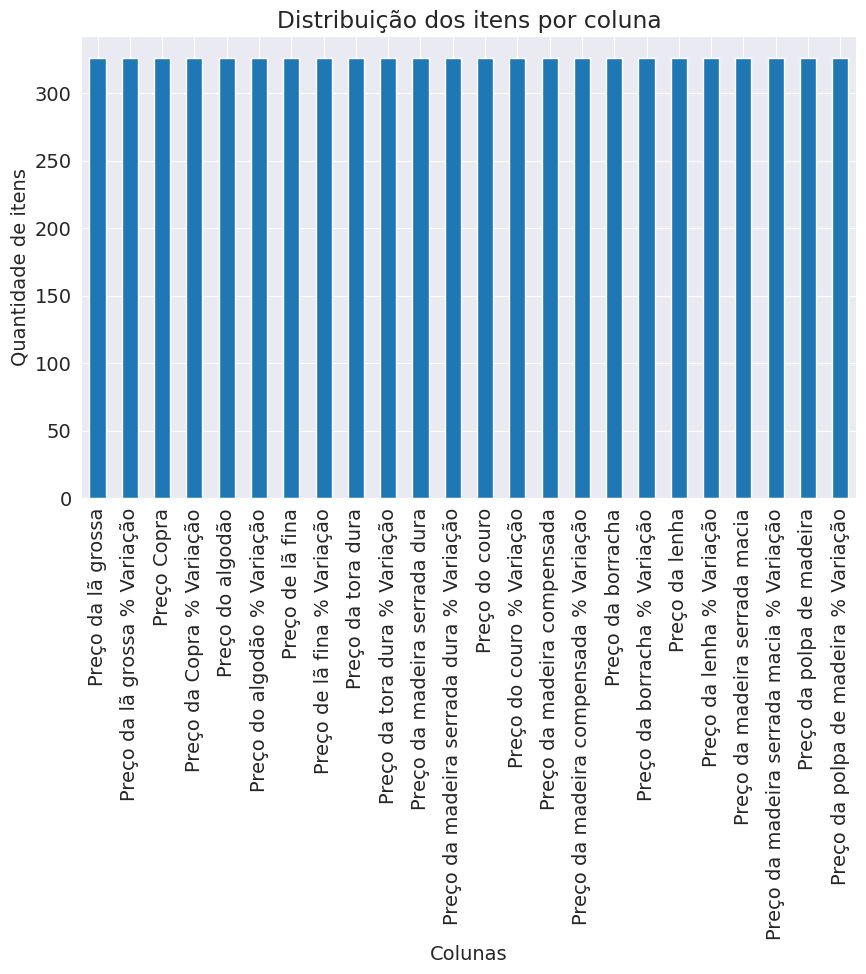

In [62]:
#gráfico de dados simples que mostra a contagem de itens de todas as colunas
plt.figure(figsize=(10, 6))
materiaPrima.count().plot(kind='bar')
plt.title('Distribuição dos itens por coluna')
plt.xlabel('Colunas')
plt.ylabel('Quantidade de itens')

O gráfico de barras mostra que temos a mesma quantidade de itens para cada coluna (Preço da lã grossa, Preço da lã grossa % Variação, Preço Copra, Preço da Copra % Variação, Preço do algodão, Preço do algodão % Variação,
Preço de lã fina, Preço de lã fina % Variação, Preço da tora dura, Preço da tora dura % Variação, Preço da madeira serrada dura, Preço da madeira serrada dura % Variação, Preço do couro, Preço do couro % Variação,
Preço da madeira compensada, Preço da madeira compensada % Variação, Preço da borracha, Preço da borracha % Variação, Preço da lenha,  Preço da lenha % Variação, Preço da madeira serrada macia,
Preço da madeira serrada macia % Variação, Preço da polpa de madeira, Preço da polpa de madeira % Variação) possui 326 itens, confirmando que o dataset é balanceado em termos de itens por coluna.

<h1><b> Estatísticas Descritivas </b></h1>

In [63]:
# estatísticas descritivas básicas do dataset
materiaPrima.describe()

,Preço da lã grossa,Preço da lã grossa % Variação,Preço Copra,Preço da Copra % Variação,Preço do algodão,Preço do algodão % Variação,Preço de lã fina,Preço de lã fina % Variação,Preço da tora dura,Preço da tora dura % Variação,...,Preço da madeira compensada,Preço da madeira compensada % Variação,Preço da borracha,Preço da borracha % Variação,Preço da lenha,Preço da lenha % Variação,Preço da madeira serrada macia,Preço da madeira serrada macia % Variação,Preço da polpa de madeira,Preço da polpa de madeira % Variação
count,326.000000,326.000000,326.000000,326.000000,326.000000,326.000000,326.000000,326.000000,326.000000,326.000000,...,326.000000,326.000000,326.000000,326.000000,326.000000,326.000000,326.000000,326.000000,326.000000,326.000000
mean,626.775429,3.845307,530.047761,5.562362,1.620736,3.999663,849.440092,4.803497,249.253620,3.257914,...,510.027178,2.268466,1.663282,5.499755,164.662025,5.442454,291.283497,4.979663,678.212362,2.800000
std,299.992828,3.628820,264.001641,5.091321,0.533457,3.930971,285.248110,4.698225,68.553994,3.423842,...,93.188458,2.659446,1.068344,5.185055,25.519555,4.768734,33.929470,5.773700,158.315029,2.890238
min,247.090000,0.000000,182.000000,0.000000,0.820000,0.000000,417.470000,0.000000,133.280000,0.010000,...,335.250000,0.000000,0.490000,0.000000,119.350000,0.000000,183.610000,0.000000,384.000000,0.000000
25%,368.490000,1.300000,371.000000,1.895000,1.272500,1.377500,646.257500,1.557500,195.275000,1.190000,...,434.727500,0.402500,0.842500,1.617500,146.117500,2.152500,277.717500,1.905000,544.632500,0.662500
50%,526.890000,2.910000,449.500000,4.350000,1.540000,2.840000,747.555000,3.470000,247.550000,2.335000,...,512.495000,1.470000,1.335000,3.910000,160.430000,4.230000,294.975000,3.695000,662.160000,2.000000
75%,848.795000,5.157500,657.125000,7.775000,1.830000,5.407500,1016.352500,6.362500,287.025000,4.285000,...,582.035000,3.147500,2.157500,7.397500,180.345000,7.457500,310.887500,6.122500,832.245000,4.107500
max,1391.470000,22.250000,1503.000000,31.820000,5.060000,23.640000,1865.440000,32.840000,520.810000,34.190000,...,751.810000,19.500000,6.260000,32.160000,259.970000,33.210000,372.600000,65.240000,966.490000,21.570000


Com base na tabela de estatísticas descritivas básicas do dataset, podemos extrair diversas análises importantes:

**1. Análise dos Preços Médios (mean):**
    
  * Ao comparar os valores médios das colunas de 'Preço', é possível identificar quais matérias-primas tiveram, em média, preços mais altos e mais baixos ao longo do período analisado. O 'Preço da lã grossa' e 'Preço de lã fina' têm médias significativamente maiores que 'Preço do algodão' ou 'Preço da borracha'.
  * A matéria-prima com o menor preço médio é o 'Preço do algodão' (1.62), confirmando sua observação anterior. As matérias-primas com os preços médios mais altos incluem 'Preço da lã fina' (849.44), 'Preço da lã grossa' (626.78), 'Preço da polpa de madeira' (678.21) e 'Preço da madeira serrada dura' (708.44).

**2. Análise da Volatilidade (std):**

  * O desvio padrão é uma excelente medida da volatilidade de preço. Matérias-primas com um std maior tiveram preços que variaram mais significativamente em torno de sua média ao longo do tempo.
  * Comparando os desvios padrão das colunas de 'Preço', podemos ver que 'Preço da lã grossa' (299.99), 'Preço de lã fina' (285.25), 'Preço Copra' (264.00) e 'Preço da polpa de madeira' (158.32) apresentam os maiores desvios padrão em termos de valores absolutos, indicando que seus preços tiveram oscilações maiores em dólares ao longo dos anos.
  * Materiais de baixo preço como 'Preço do algodão' (0.53), 'Preço da borracha' (1.07) e 'Preço do couro' (13.66) têm desvios padrão absolutos muito menores, refletindo suas faixas de preço mais baixas.

 **3. Análise da Faixa de Preços (min e max) e Distribuição (Quartis):**

  * Os valores mínimos e máximos mostram a amplitude total dos preços observados para cada matéria-prima.
  * Os quartis (25%, 50%, 75%) fornecem mais detalhes sobre a distribuição dos preços. A diferença entre Q3 e Q1 (o intervalo interquartil) mostra a faixa onde os 50% centrais dos dados estão localizados.
    
 **4. Análise da Volatilidade da Variação Percentual (std e max das colunas de % Variação):**

  * As estatísticas para as colunas de '% Variação' são cruciais para entender a volatilidade relativa, independentemente da escala de preço absoluta.
  * Conforme a análise anterior, o max e std confirmam que a 'Preço da madeira serrada macia % Variação' (max=65.24, std=5.77) teve os maiores picos e maior volatilidade percentual.
  * Em contraste, 'Preço da madeira compensada % Variação' (max=19.50, std=2.66) tem os valores mais baixos de max e std, indicando menor volatilidade percentual.

As estatísticas descritivas permitem:

  * Quantificar as observações visuais feitas nos gráficos (preço médio, volatilidade).
  * Comparar numericamente a tendência central, dispersão e a amplitude dos dados entre as diferentes matérias-primas.
  * Confirmar quais materiais operam em diferentes faixas de preço e quais tiveram maiores ou menores oscilações (em valores absolutos e percentuais) ao longo do tempo.

Esses números fornecem uma base sólida para entender o comportamento histórico dos preços e da volatilidade do dataset.

# **Média**

In [64]:
# média dos atributos numéricos do dataset
materiaPrima.describe().loc['mean']

,mean
Preço da lã grossa,626.775429
Preço da lã grossa % Variação,3.845307
Preço Copra,530.047761
Preço da Copra % Variação,5.562362
Preço do algodão,1.620736
Preço do algodão % Variação,3.999663
Preço de lã fina,849.440092
Preço de lã fina % Variação,4.803497
Preço da tora dura,249.253620
Preço da tora dura % Variação,3.257914


A média de cada coluna numérica representa o valor médio dessa característica ao longo de todo o período analisado (de maio de 1990 a junho de 2017, após remover as linhas com valores ausentes).

Aqui estão algumas análises que podemos extrair:

**1. Comparação de Preços Médios:**

  * A média das colunas de 'Preço' nos permite comparar o nível de preço típico de cada matéria-prima. Como observamos anteriormente e o gráfico de barras das médias confirma, há uma clara distinção entre os materiais de "baixo preço" (como algodão, borracha, couro) e "alto preço" (como lã grossa, lã fina, polpa de madeira, madeira serrada dura, madeira compensada).
  * A média quantifica essa diferença, mostrando que, por exemplo, a lã fina teve um preço médio muito mais alto (849.44) do que o algodão (1.62).

**2. Comparação das Variações Percentuais Médias:**

  * A média das colunas de '% Variação' nos dá o aumento percentual médio mensal para cada matéria-prima ao longo do tempo. É importante notar que, como você tratou os valores negativos como positivos, essa média representa a magnitude média da mudança percentual, independentemente de ser um aumento ou diminuição original.
  * Comparando essas médias, você pode ver quais matérias-primas tiveram, em média, maiores ou menores oscilações percentuais de um mês para o outro. Por exemplo, 'Preço da borracha % Variação' tem uma média relativamente alta (5.50), enquanto 'Preço da madeira serrada dura % Variação' tem uma média menor (2.01).

**3. Identificação de Tendências Gerais (limitada pela média):**

  * Embora a média por si só não mostre tendências ao longo do tempo (para isso, olhamos os gráficos de série temporal), uma média muito diferente de zero para as % de variação (especialmente se você não tivesse tratado os negativos) poderia sugerir uma tendência geral de alta ou baixa nos preços ao longo do período. Como os negativos foram tornados positivos, as médias das % de variação refletem a volatilidade média.

A análise das médias dos atributos numéricos permite:

  * Quantificar o nível de preço típico de cada matéria-prima.
  * Quantificar a magnitude média das mudanças percentuais mensais.
  * Fazer comparações diretas entre as matérias-primas com base em seus valores médios de preço e variação.

Essa análise complementa as outras estatísticas descritivas (como desvio padrão, min, max) e as visualizações, fornecendo uma visão mais completa do comportamento dos dados.

Text(0, 0.5, 'Média')

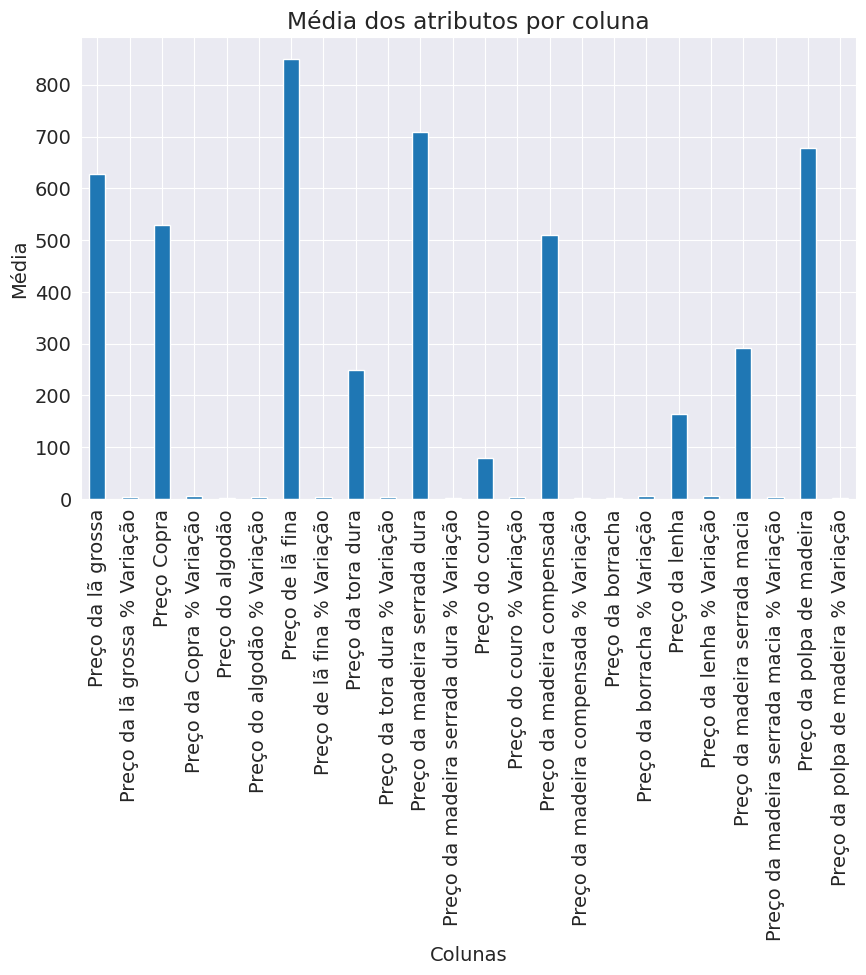

In [65]:
#Gráfico que representa a média dos atributos numéricos
plt.figure(figsize=(10, 6))
materiaPrima.describe().loc['mean'].plot(kind='bar')
plt.title('Média dos atributos por coluna')
plt.xlabel('Colunas')
plt.ylabel('Média')

Podemos observar que o preço médio da lã grossa, copra, lã fina, madeira serrada dura, madeira compensada e polpa de madeira, possuem um preço médio muito maior que as demais.


In [66]:
# desvio padrão dos atributos numéricos do dataset
materiaPrima.describe().loc['std']

,std
Preço da lã grossa,299.992828
Preço da lã grossa % Variação,3.628820
Preço Copra,264.001641
Preço da Copra % Variação,5.091321
Preço do algodão,0.533457
Preço do algodão % Variação,3.930971
Preço de lã fina,285.248110
Preço de lã fina % Variação,4.698225
Preço da tora dura,68.553994
Preço da tora dura % Variação,3.423842


O desvio padrão é uma medida estatística que indica o quanto os valores de um conjunto de dados se dispersam em relação à sua média. Em outras palavras, ele quantifica a volatilidade ou a variabilidade dos dados.

Na tabela de desvio padrão, cada valor representa o desvio padrão para a coluna numérica correspondente.

  * **Desvio Padrão para Colunas de Preço:** Um desvio padrão alto para uma coluna de preço significa que os preços dessa matéria-prima variaram muito ao longo do tempo, afastando-se significativamente do seu preço médio. Um desvio padrão baixo indica que os preços foram mais consistentes e próximos da média.
  * **Desvio Padrão para Colunas de % Variação:** Um desvio padrão alto para uma coluna de % Variação significa que a magnitude das mudanças percentuais mensais no preço dessa matéria-prima foi muito variável, com algumas mudanças sendo muito grandes e outras muito pequenas ou próximas de zero. Um desvio padrão baixo indica que as variações percentuais mensais foram mais consistentes em magnitude.

Análises que podemos tirar dos valores de desvio padrão:

  * **Comparação da Volatilidade Absoluta (Preços):** Comparando os desvios padrão das colunas de preço, você pode ver quais matérias-primas tiveram as maiores oscilações de preço em termos de dólares. Materiais de alto preço como a lã grossa, lã fina e copra tendem a ter desvios padrão absolutos maiores simplesmente porque seus preços são em uma escala mais alta.
  * **Comparação da Volatilidade Relativa (% Variação):** Comparar os desvios padrão das colunas de % Variação é crucial para entender a volatilidade relativa, pois essa métrica não é diretamente afetada pela escala absoluta do preço. Como você analisou anteriormente com o valor máximo, o desvio padrão das variações percentuais ajuda a confirmar quais materiais tiveram mudanças percentuais mais consistentes ou mais erráticas.

O gráfico que representa o desvio padrão visualiza esses valores, com barras mais altas indicando maior desvio padrão e, portanto, maior volatilidade na característica correspondente.

Text(0, 0.5, 'Desvio padrão')

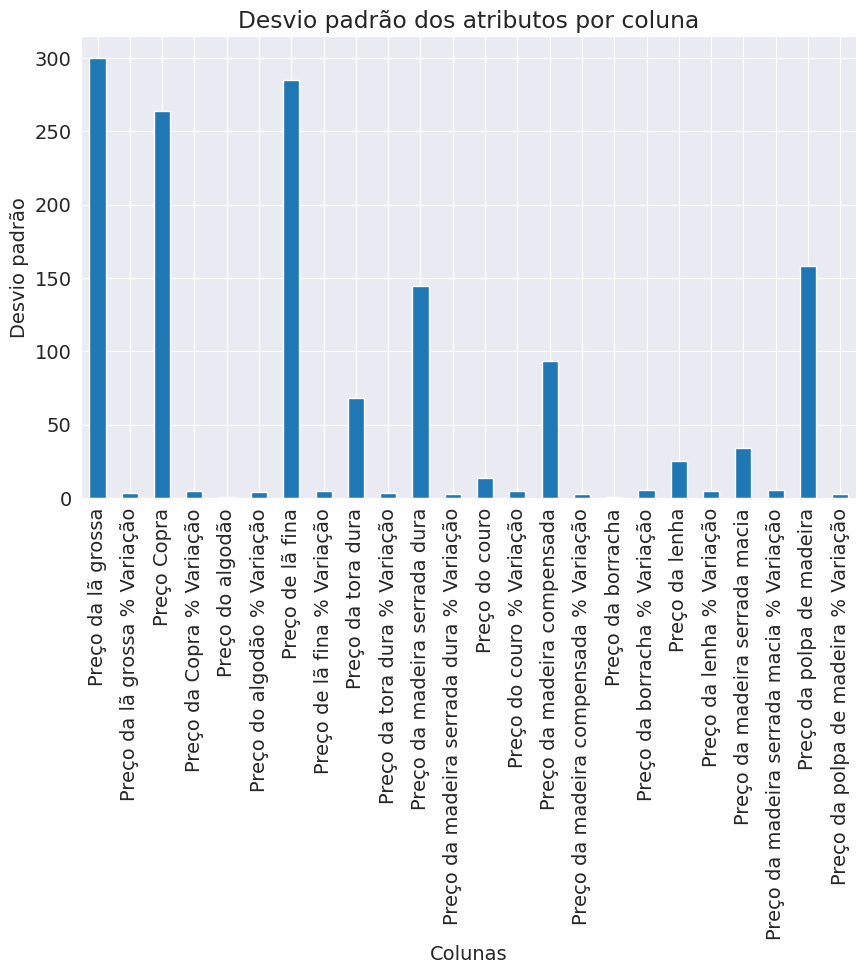

In [67]:
#Gráfico que representa o desvio padrão dos atributos numéricos
plt.figure(figsize=(10, 6))
materiaPrima.describe().loc['std'].plot(kind='bar')
plt.title('Desvio padrão dos atributos por coluna')
plt.xlabel('Colunas')
plt.ylabel('Desvio padrão')

Podemos observar que o desvio padrão da lã grossa, copra, lã fina, possuem uma variação muito maior que as demais, deixando eles mais dispersos e mais distantes da média. Referindo-se às barras correspondentes a essas matérias-primas nas colunas de preço, onde as barras são visivelmente mais altas do que as barras de preço de outros materiais, indicando maior dispersão de seus preços absolutos em torno da média.

# **Pré-Processamento de Dados**

# **Aplicando Train Test**

In [68]:
# Definindo o ponto de corte para a divisão (por exemplo, em uma data específica)
# Você pode ajustar esta data conforme necessário
split_date = '2015-01-01'

# Dividindo os dados com base na data
train_data = materiaPrima[materiaPrima.index < split_date]
test_data = materiaPrima[materiaPrima.index >= split_date]

# Definindo as features (X) e o target (y) para os conjuntos de treino e teste
# Remova a coluna alvo dos recursos em ambos os conjuntos
X_train_time = train_data.drop(columns=['Preço do algodão'])
y_train_time = train_data['Preço do algodão']

X_test_time = test_data.drop(columns=['Preço do algodão'])
y_test_time = test_data['Preço do algodão']

print("Training set shape (time-based - features):", X_train_time.shape)
print("Testing set shape (time-based - features):", X_test_time.shape)
print("Training set shape (time-based - target):", y_train_time.shape)
print("Testing set shape (time-based - target):", y_test_time.shape)


Training set shape (time-based - features): (296, 23)
Testing set shape (time-based - features): (30, 23)
Training set shape (time-based - target): (296,)
Testing set shape (time-based - target): (30,)


Essa divisão baseada em tempo garante que estou usando dados históricos para treinar um modelo e avaliando seu desempenho em dados futuros, o que é crucial para a modelagem de séries temporais.

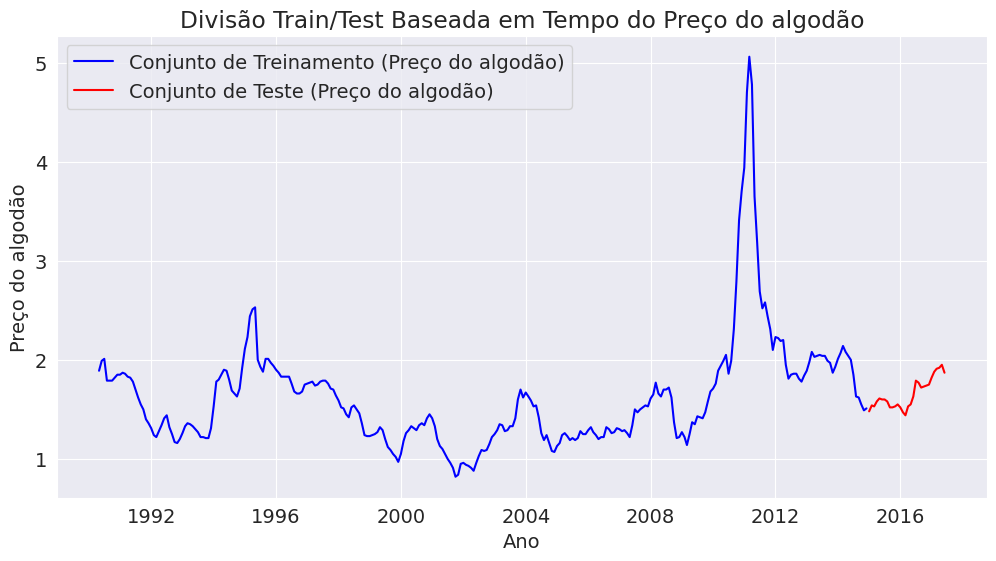

In [69]:
# Gráfico para demonstrar o train test
plt.figure(figsize=(12, 6))

plt.plot(y_train_time.index, y_train_time, label='Conjunto de Treinamento (Preço do algodão)', color='blue')
plt.plot(y_test_time.index, y_test_time, label='Conjunto de Teste (Preço do algodão)', color='red')

plt.title('Divisão Train/Test Baseada em Tempo do Preço do algodão')
plt.xlabel('Ano')
plt.ylabel('Preço do algodão')
plt.legend()
plt.grid(True)
plt.show()

Este gráfico mostra a série temporal do 'Preço do algodão' dividida em conjuntos de treinamento e teste com base no tempo.

O eixo X representa o tempo (Ano).
O eixo Y representa o 'Preço do algodão'.
A linha azul mostra os dados que foram alocados para o conjunto de treinamento (y_train_time).
A linha vermelha mostra os dados que foram alocados para o conjunto de teste (y_test_time).
A visualização da divisão Train/Test é importante para séries temporais, pois geralmente queremos garantir que o conjunto de teste esteja em um período posterior ao conjunto de treinamento para simular um cenário do mundo real onde você prevê valores futuros com base em dados passados. Neste gráfico, podemos ver que os dados foram divididos de forma que o conjunto de teste (y_test_time) contém os pontos de dados mais recentes no tempo, o que é apropriado para a previsão de séries temporais.

<h1><b>Padronização</b></h1>

Escolhi a padronização por acreditar ser uma escolha forte para este dataset, pois aborda diretamente a questão das diferentes escalas entre as features e prepara os dados para uma ampla gama de algoritmos de machine learning.

In [70]:
# Inicializando o StandardScaler
scaler = StandardScaler()

# Ajustando o scaler APENAS nos dados de treino (da divisão baseada em tempo) e transformando os dados de treino
X_train_scaled = scaler.fit_transform(X_train_time)

# Transformando os dados de teste (da divisão baseada em tempo) usando o scaler ajustado nos dados de treino
X_test_scaled = scaler.transform(X_test_time)

# Agora X_train_scaled e X_test_scaled contêm os dados padronizados
print("Dados de treino padronizados (primeiras 5 linhas):\n", X_train_scaled[:5])
print("\nDados de teste padronizados (primeiras 5 linhas):\n", X_test_scaled[:5])

Dados de treino padronizados (primeiras 5 linhas):
 [[-0.49398028  0.9091544  -1.07231126 -0.91649198 -0.2206406   0.84176955
  -0.74963123 -1.05086938  1.08432347 -1.41655167  3.12020348  1.52159023
  -0.64235791 -1.68686962  3.56042648 -0.72512407 -0.79858653 -1.54234772
  -0.49711536 -2.23282514 -0.520131    1.20970015 -0.518601  ]
 [-0.51559439 -0.67149955 -1.14722808  0.41079918  0.27856967  0.2742104
   2.100947   -0.92773708  0.47980468 -1.39295574 -0.49052755  1.40885217
  -0.42032229 -1.44043845  1.63268801 -0.72512407 -1.03105909 -1.34728183
  -0.25431721 -2.60931806  0.27968478  1.13642571 -0.61233764]
 [-0.59332934  0.32751683 -1.19301059 -0.0937267  -0.78442534  0.26560453
  -0.97467687 -0.83982538  0.01435358 -1.45702105 -0.04652505  1.32574399
  -0.50654971 -1.39346962 -0.404374   -0.71613819 -0.80054008 -1.54423424
  -0.28152735 -2.31826007  0.03305571  0.92290557  0.28683974]
 [-0.59332934 -1.04848687 -1.22214491 -0.41972803  1.68430606  0.46339679
   0.25682293 -0.865

Os valores agora são diferentes dos dados originais. Eles foram redimensionados para ter uma escala comum. Isso é útil para algoritmos de machine learning que são sensíveis à escala das features.

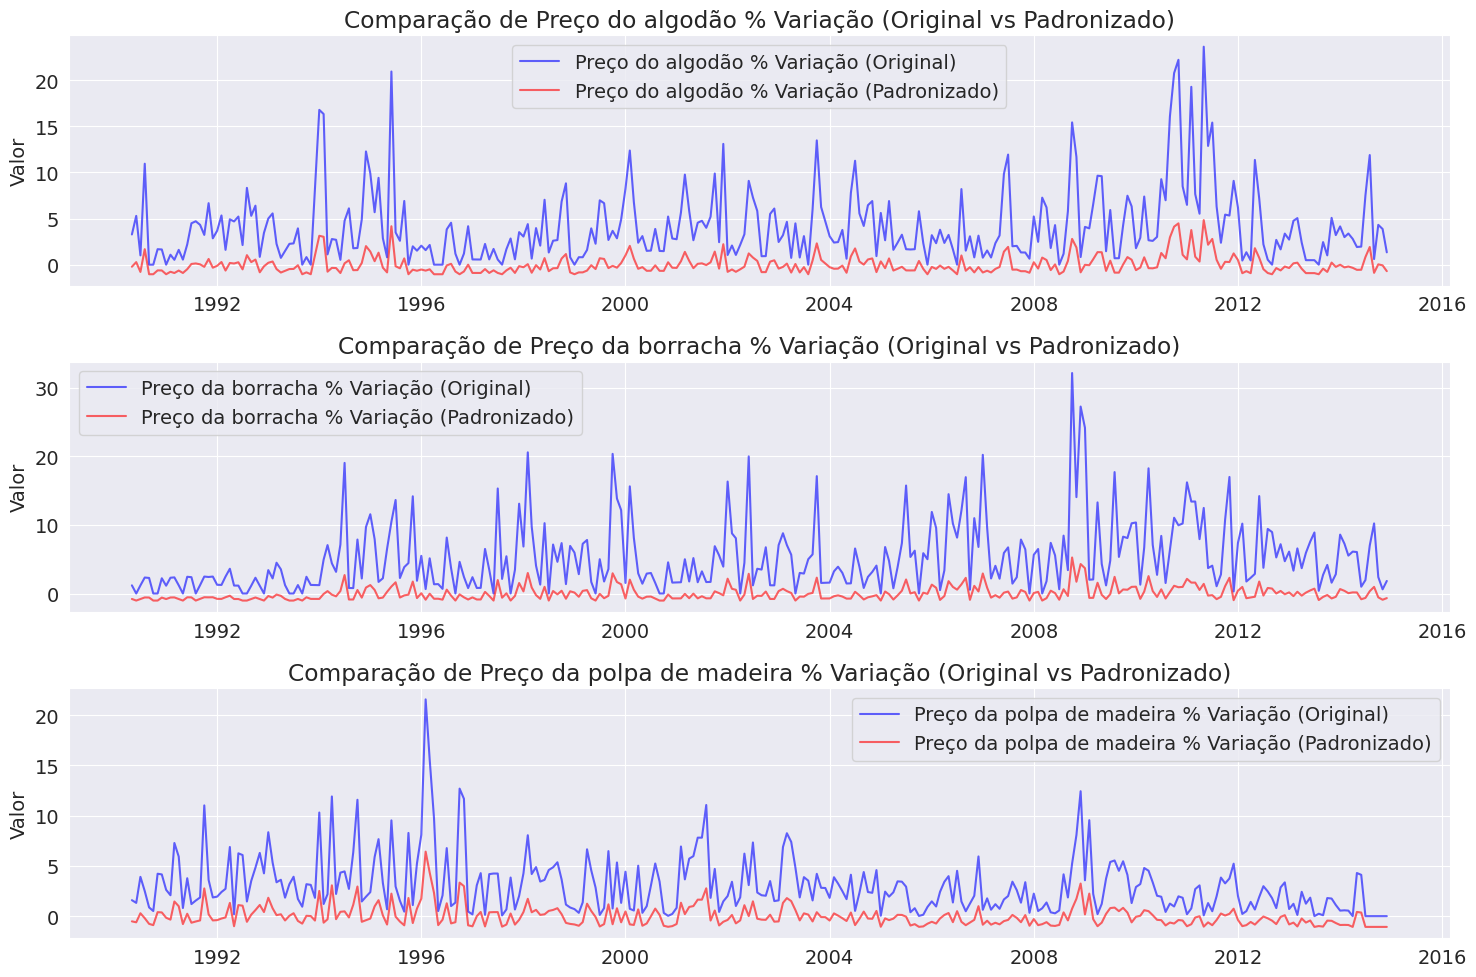

In [71]:
# Gráfico para demonstrar a padronização
# Converter os arrays padronizados de volta para DataFrames com o índice original
X_train_scaled_df = pd.DataFrame(X_train_scaled, index=X_train_time.index, columns=X_train_time.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, index=X_test_time.index, columns=X_test_time.columns)

# Selecionar algumas colunas para plotar
columns_to_plot = ['Preço do algodão % Variação', 'Preço da borracha % Variação', 'Preço da polpa de madeira % Variação']

# Plotar as colunas originais e padronizadas para comparação (conjunto de treino)
plt.figure(figsize=(15, 10))

for i, col in enumerate(columns_to_plot):
    plt.subplot(len(columns_to_plot), 1, i + 1)
    plt.plot(X_train_time.index, X_train_time[col], label=f'{col} (Original)', color='blue', alpha=0.6)
    plt.plot(X_train_scaled_df.index, X_train_scaled_df[col], label=f'{col} (Padronizado)', color='red', alpha=0.6)
    plt.title(f'Comparação de {col} (Original vs Padronizado)')
    plt.ylabel('Valor')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

O gráfico gerado mostra a comparação entre os dados originais e os dados padronizados para as colunas ('Preço do algodão % Variação', 'Preço da borracha % Variação' e 'Preço da polpa de madeira % Variação') no conjunto de treinamento.

Para cada uma das colunas, há duas linhas:

A linha azul representa os valores originais da feature ao longo do tempo. Você pode ver a escala original dos dados nesta linha.
A linha vermelha representa os valores da feature após a padronização. Observe como a escala dos dados foi alterada. A padronização transforma os dados para terem uma média próxima de zero e um desvio padrão próximo de um. Isso centraliza os dados em torno de zero e os redimensiona para que a maioria dos valores fique em uma faixa menor, geralmente entre -3 e 3 (embora valores fora dessa faixa sejam possíveis, especialmente se houver outliers).
Este gráfico visualiza o efeito da padronização: os padrões e tendências temporais dos dados são mantidos, mas a escala dos valores é alterada para uma escala comum. Isso é útil para algoritmos de machine learning que podem ter seu desempenho afetado por features com escalas muito diferentes.

<h1><b> Mapa de calor </b><h1>

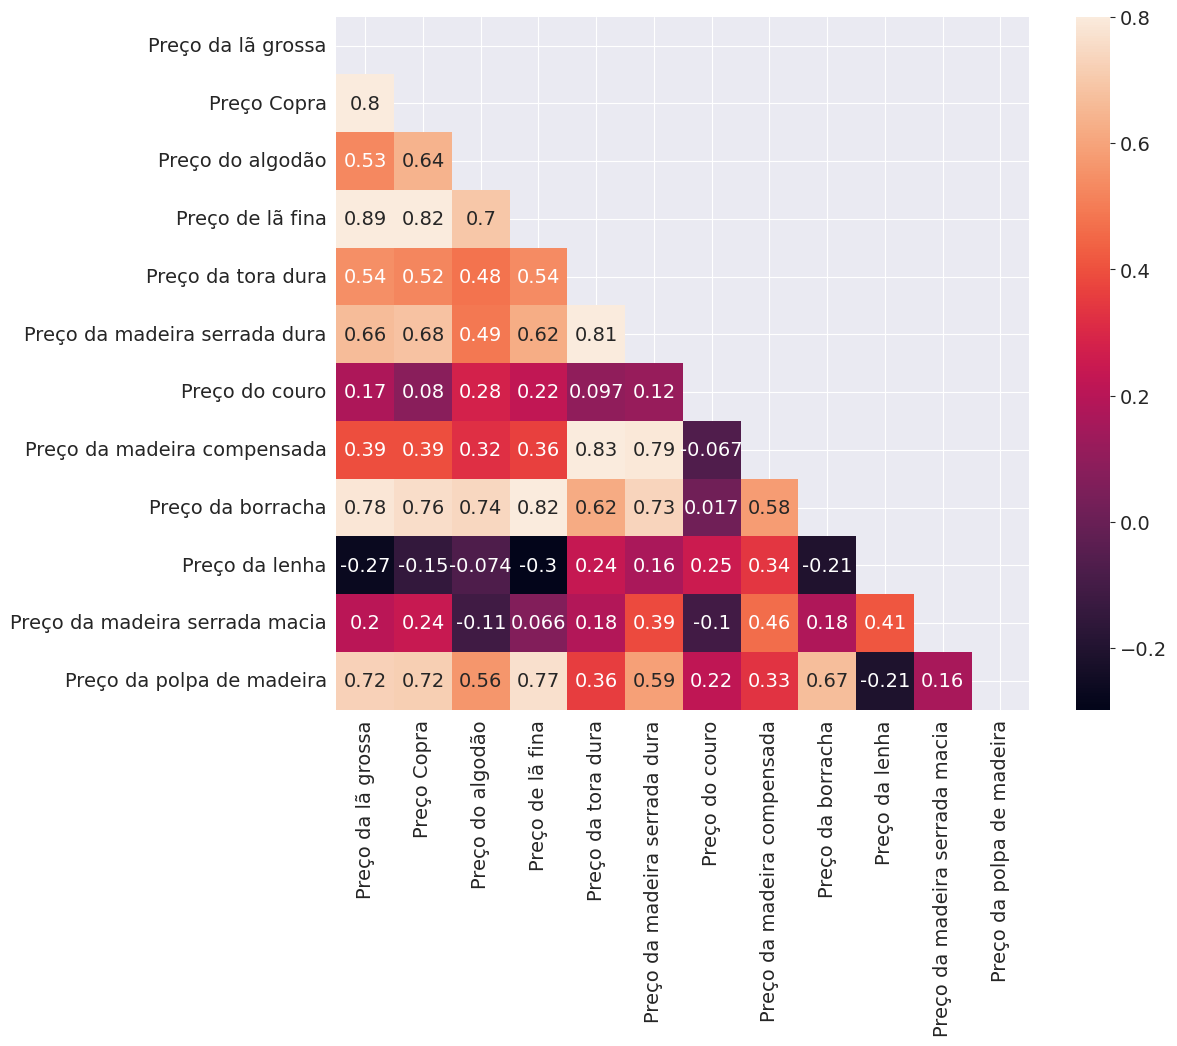

In [72]:
#lista de matérias-primas
raw_data=['Preço da lã grossa',  'Preço Copra', 'Preço do algodão', 'Preço de lã fina', 'Preço da tora dura', 'Preço da madeira serrada dura', 'Preço do couro', 'Preço da madeira compensada', 'Preço da borracha',
'Preço da lenha', 'Preço da madeira serrada macia', 'Preço da polpa de madeira']

# Criando a Figura e Subplots
fig = plt.figure(figsize = (12, 9))

#obtendo a matriz de correlação
corrmat = materiaPrima[raw_data].corr()

#mascarando a parte superior do triângulo, já que a matriz é simétrica (repetitiva)
mask = np.triu(np.ones_like(corrmat, dtype=bool))
sns.heatmap(corrmat, vmax = .8,mask=mask, square = True, annot = True)
plt.show()

Podemos observar no mapa de calor:

 * Cada célula no mapa de calor representa a correlação entre duas matérias-primas.
 * A cor da célula indica a intensidade e a direção da correlação:
    * Cores mais quentes (próximas do vermelho) indicam uma correlação positiva forte: quando o preço de uma matéria-prima aumenta, o preço da outra também tende a aumentar.
    * Cores mais frias (próximas do azul) indicam uma correlação negativa forte: quando o preço de uma matéria-prima aumenta, o preço da outra tende a diminuir.
    * Cores mais claras (próximas do branco ou cinza) indicam uma correlação fraca ou próxima de zero: não há uma relação linear clara entre os preços das duas matérias-primas.
 * Os números dentro de cada célula são os coeficientes de correlação (valores entre -1 e 1). Um valor mais próximo de 1 indica uma correlação positiva forte, um valor mais próximo de -1 indica uma correlação negativa forte, e um valor próximo de 0 indica uma correlação fraca.
 * A diagonal principal (de cima para a esquerda para baixo para a direita) sempre terá valores de 1, pois uma matéria-prima tem uma correlação perfeita consigo mesma.
 * Como a matriz de correlação é simétrica (a correlação entre A e B é a mesma que entre B e A), você mascarou a parte superior para evitar redundância.

A partir deste mapa de calor, você pode identificar quais pares de matérias-primas têm as relações de preço mais fortes (positivas ou negativas) ao longo do tempo. Por exemplo, um valor alto e positivo entre "Preço da lã grossa" e "Preço de lã fina" sugere que o preço desses dois tipos de lã tende a se mover na mesma direção.

As colunas com maior correlação são: 'Preço da lã grossa' e 'Preço de lã fina' com correlação de 0.89


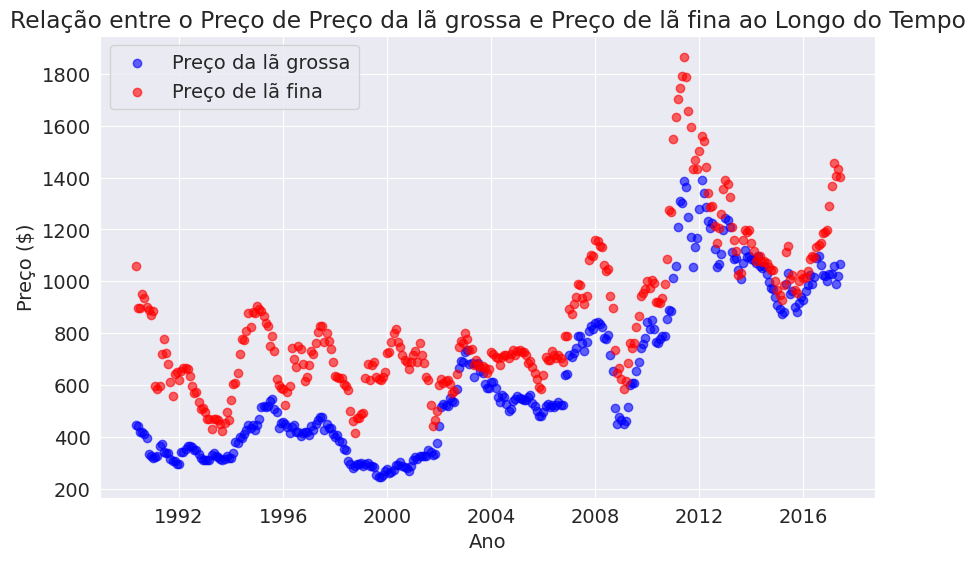

In [73]:
# Escolhendo duas colunas com alta correlação
# Lista de matérias-primas para análise de preço
raw_data = ['Preço da lã grossa',  'Preço de lã fina']

# Obtendo a matriz de correlação apenas para as colunas de preço
corrmat = materiaPrima[raw_data].corr()

# Encontrando o par de colunas com maior correlação absoluta (excluindo a diagonal)
# Inicializa as variáveis para armazenar a maior correlação e os nomes das colunas
max_corr = 0
coluna1 = ''
coluna2 = ''

# Itera sobre a matriz de correlação
for i in range(len(corrmat.columns)):
    for j in range(i + 1, len(corrmat.columns)): # Itera apenas sobre o triângulo superior
        correlation = abs(corrmat.iloc[i, j])
        if correlation > max_corr:
            max_corr = correlation
            coluna1 = corrmat.columns[i]
            coluna2 = corrmat.columns[j]

print(f"As colunas com maior correlação são: '{coluna1}' e '{coluna2}' com correlação de {max_corr:.2f}")

# Plotando o gráfico de dispersão para as colunas com maior correlação
plt.figure(figsize=(10, 6))

plt.scatter(materiaPrima.index, materiaPrima[coluna1], label=coluna1, color='blue', alpha=0.6)
plt.scatter(materiaPrima.index, materiaPrima[coluna2], label=coluna2, color='red', alpha=0.6)

plt.title(f'Relação entre o Preço de {coluna1} e {coluna2} ao Longo do Tempo')
plt.xlabel('Ano')
plt.ylabel('Preço ($)')
plt.legend()
plt.grid(True)
plt.show()

O gráfico de dispersão gerado mostra a relação entre o 'Preço da lã grossa' e o 'Preço de lã fina' ao longo do tempo.

 * Cada ponto no gráfico representa um ponto de dados para um mês específico. A posição horizontal do ponto é determinada pela data (o índice do DataFrame), e a posição vertical é determinada pelo preço da matéria-prima correspondente.
 * A linha azul mostra a variação do 'Preço da lã grossa' ao longo do tempo.
 * A linha vermelha mostra a variação do 'Preço de lã fina' ao longo do tempo.
Observamos corretamente que o gráfico mostra que o preço da lã grossa e o preço da lã fina variam juntos ao longo do tempo. Isso é consistente com o alto coeficiente de correlação (0.89) que você encontrou no mapa de calor e imprimiu antes do gráfico. Um coeficiente de correlação próximo de 1 indica uma forte relação linear positiva, o que significa que quando o preço de uma aumenta, o preço da outra também tende a aumentar de forma consistente.

Em resumo, o gráfico visualmente confirma a forte correlação positiva entre os preços da lã grossa e da lã fina, mostrando que seus movimentos de preço estão alinhados ao longo dos anos.

As colunas com menor correlação são: 'Preço do couro' e 'Preço da borracha' com correlação de 0.02


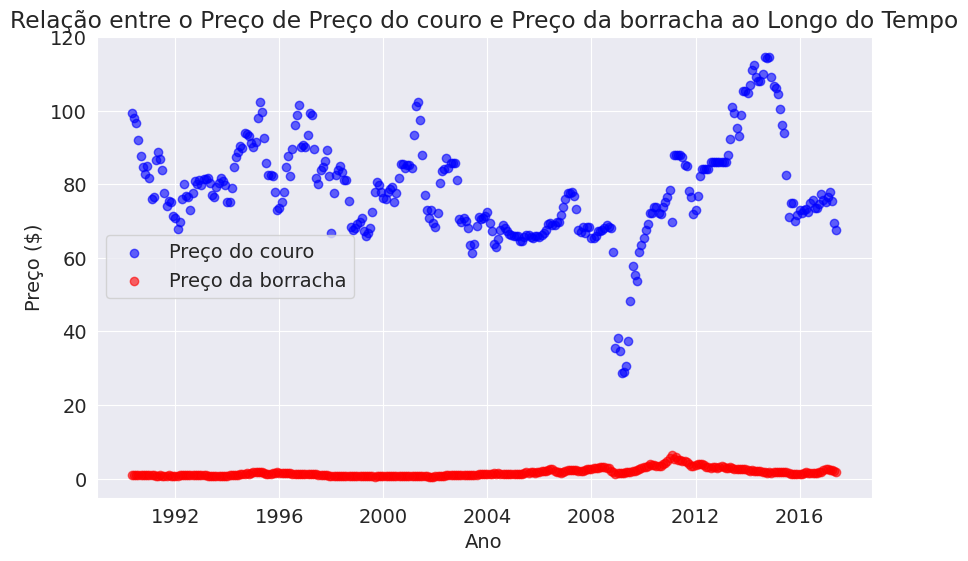

In [74]:
# Escolhendo duas colunas com baixa correlação
# Lista de matérias-primas para análise de preço
raw_data = ['Preço do couro' , 'Preço da borracha']

# Obtendo a matriz de correlação apenas para as colunas de preço
corrmat = materiaPrima[raw_data].corr()

# Encontrando o par de colunas com maior correlação absoluta (excluindo a diagonal)
# Inicializa as variáveis para armazenar a maior correlação e os nomes das colunas
max_corr = 0
coluna1 = ''
coluna2 = ''

# Itera sobre a matriz de correlação
for i in range(len(corrmat.columns)):
    for j in range(i + 1, len(corrmat.columns)): # Itera apenas sobre o triângulo superior
        correlation = abs(corrmat.iloc[i, j])
        if correlation > max_corr:
            max_corr = correlation
            coluna1 = corrmat.columns[i]
            coluna2 = corrmat.columns[j]

print(f"As colunas com menor correlação são: '{coluna1}' e '{coluna2}' com correlação de {max_corr:.2f}")

# Plotando o gráfico de dispersão para as colunas com menor correlação
plt.figure(figsize=(10, 6))

plt.scatter(materiaPrima.index, materiaPrima[coluna1], label=coluna1, color='blue', alpha=0.6)
plt.scatter(materiaPrima.index, materiaPrima[coluna2], label=coluna2, color='red', alpha=0.6)

plt.title(f'Relação entre o Preço de {coluna1} e {coluna2} ao Longo do Tempo')
plt.xlabel('Ano')
plt.ylabel('Preço ($)')
plt.legend()
plt.grid(True)
plt.show()

O gráfico de dispersão gerado mostra a relação entre o 'Preço do couro' e o 'Preço da borracha' ao longo do tempo.

 * Cada ponto no gráfico representa um ponto de dados para um mês específico. A posição horizontal do ponto é determinada pela data (o índice do DataFrame), e a posição vertical é determinada pelo preço da matéria-prima correspondente.
 * A linha azul mostra a variação do 'Preço do couro' ao longo do tempo.
 * A linha vermelha mostra a variação do 'Preço da borracha' ao longo do tempo.

Podemos observar que este gráfico mostra que o preço do couro e o preço da borracha não variam juntos de forma consistente ao longo do tempo. Isso é consistente com o baixo coeficiente de correlação (0.02) que você encontrou e imprimiu antes do gráfico. Um coeficiente de correlação próximo de 0 indica uma correlação linear fraca, o que significa que não há uma relação linear clara entre os movimentos de preço dessas duas matérias-primas.

Em resumo, o gráfico visualmente confirma a baixa correlação entre os preços do couro e da borracha, mostrando que seus movimentos de preço não estão fortemente alinhados ao longo dos anos.

## **Preços e seus gráficos de % de variação**

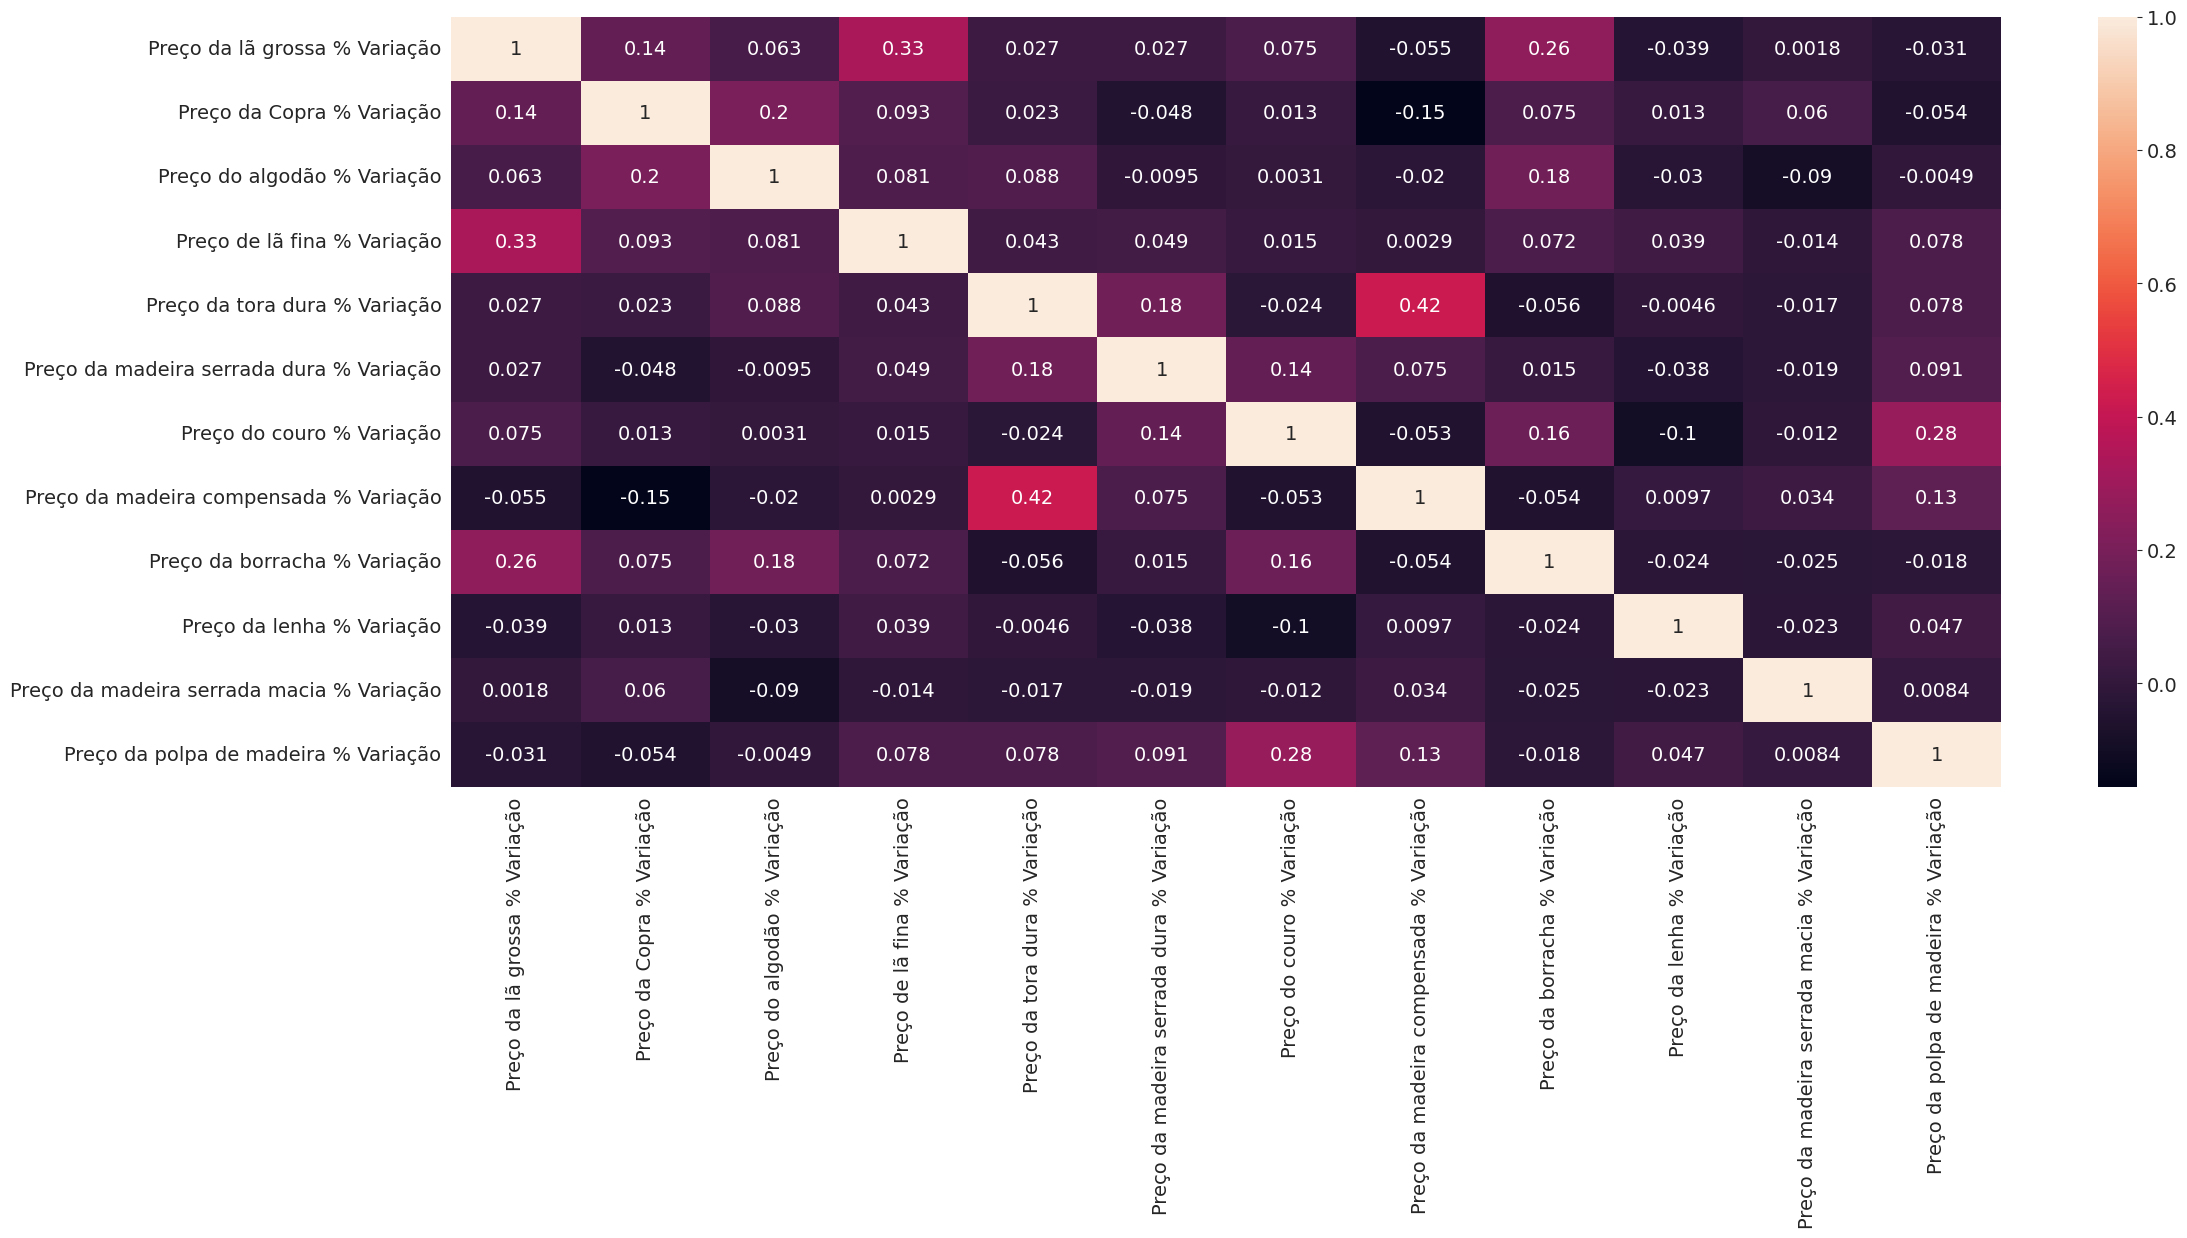

In [75]:
# Selecionando colunas de variação
changelist=['Preço da lã grossa % Variação', 'Preço da Copra % Variação', 'Preço do algodão % Variação', 'Preço de lã fina % Variação',
'Preço da tora dura % Variação', 'Preço da madeira serrada dura % Variação', 'Preço do couro % Variação',
'Preço da madeira compensada % Variação', 'Preço da borracha % Variação', 'Preço da lenha % Variação', 'Preço da madeira serrada macia % Variação',
'Preço da polpa de madeira % Variação']

# Criando a Figura e Subplots
plt.figure(figsize=(25,10))

#gera uma matriz de correlação para todo o conjunto de dados
corrMatrix = materiaPrima[changelist].corr()
sns.heatmap(corrMatrix, annot=True)
plt.show()

Os gráficos gerado mostra a série temporal do preço e da variação percentual para cada matéria-prima individualmente ao longo do tempo.

Para cada par de gráficos de uma matéria-prima (como "Preço da lã grossa" e "Preço da lã grossa % Variação"), você vê:

 * Gráfico de Preço: Uma linha mostrando como o preço absoluto daquela matéria-prima mudou ao longo dos anos (no eixo X). O eixo Y representa o preço em dólares ($). Isso permite observar a tendência geral do preço, picos, quedas e ciclos ao longo do tempo.
 * Gráfico de Variação Percentual: Uma linha mostrando a mudança percentual mensal no preço daquela matéria-prima ao longo do tempo. O eixo Y representa a variação percentual. Este gráfico destaca a volatilidade do preço, mostrando quão grandes e frequentes são as oscilações de preço de um mês para o outro. Valores positivos indicam um aumento no preço em relação ao mês anterior, e valores negativos (embora você tenha tratado os negativos para se tornarem positivos) indicam uma diminuição.

Ao visualizar esses gráficos juntos para cada matéria-prima, você pode:

 * Ver como a variação percentual se relaciona com os movimentos de preço. Por exemplo, grandes picos ou quedas no gráfico de preço geralmente correspondem a grandes variações (positivas ou negativas) no gráfico de variação percentual.
 * Comparar a volatilidade de diferentes matérias-primas observando a amplitude das oscilações nos gráficos de variação percentual.

O comentário sobre a lã grossa ("Preços diversificados com baixa variação") é uma observação baseada nesses gráficos: você vê o preço variando (preços "diversificados") e, ao mesmo tempo, a linha de variação percentual mostrando oscilações relativamente menores em comparação com outras matérias-primas.

<h1><b> Preços e suas Variações </b></h1>


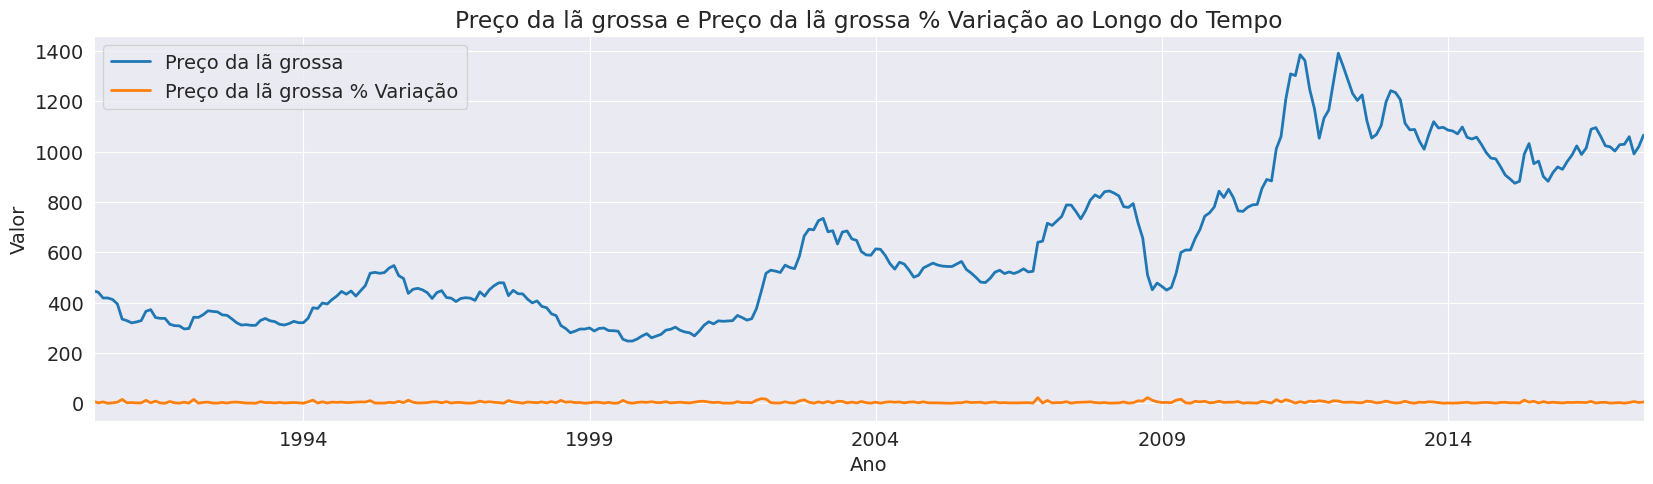

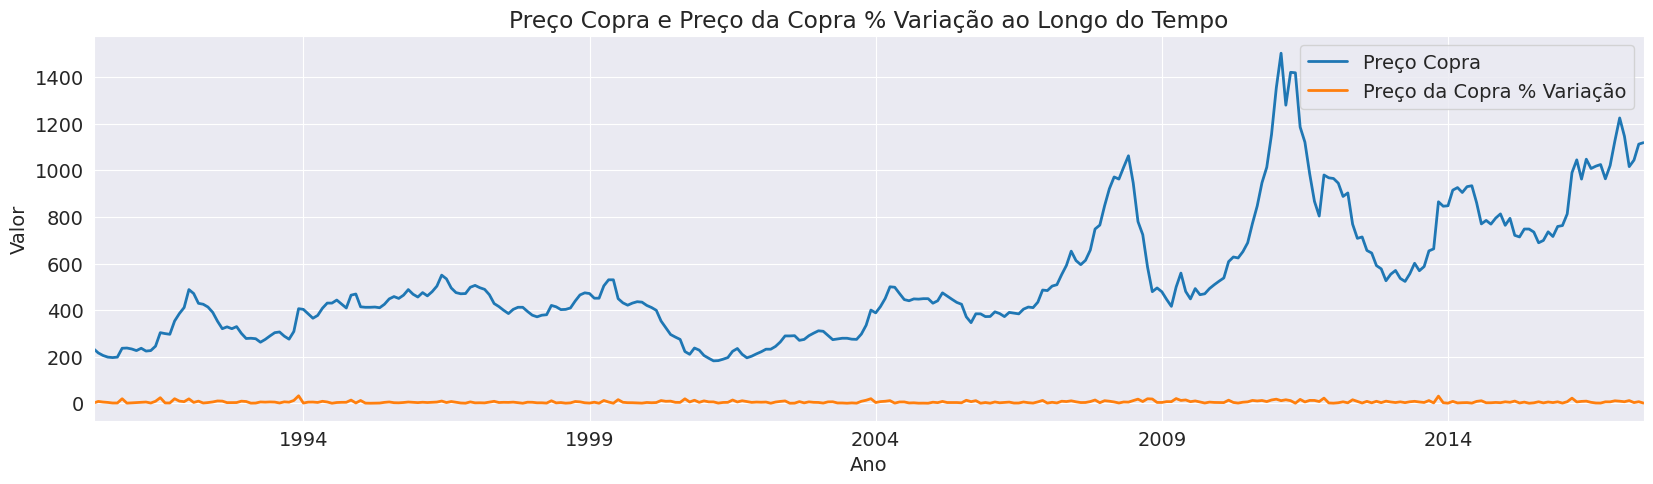

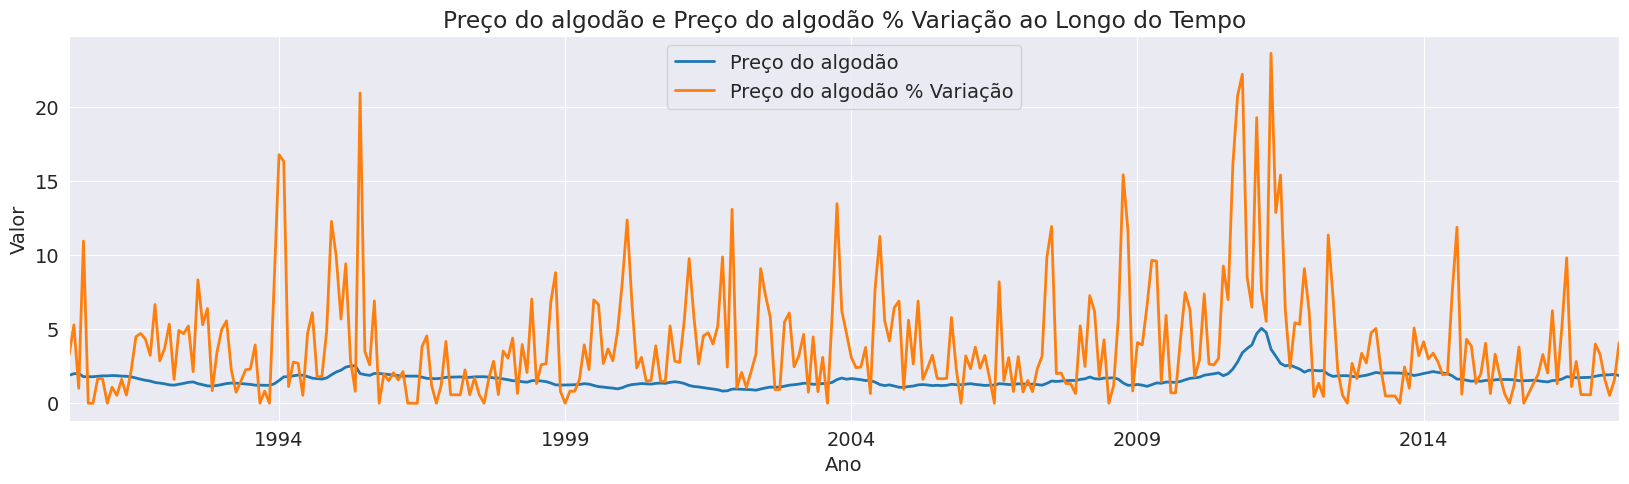

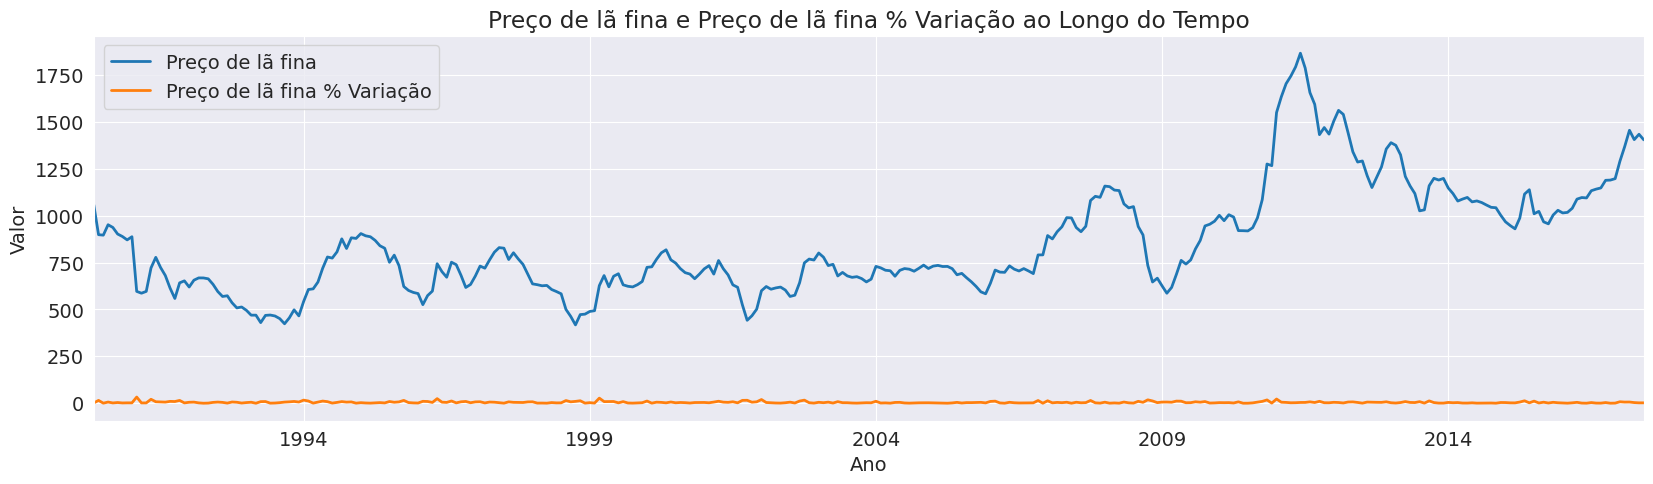

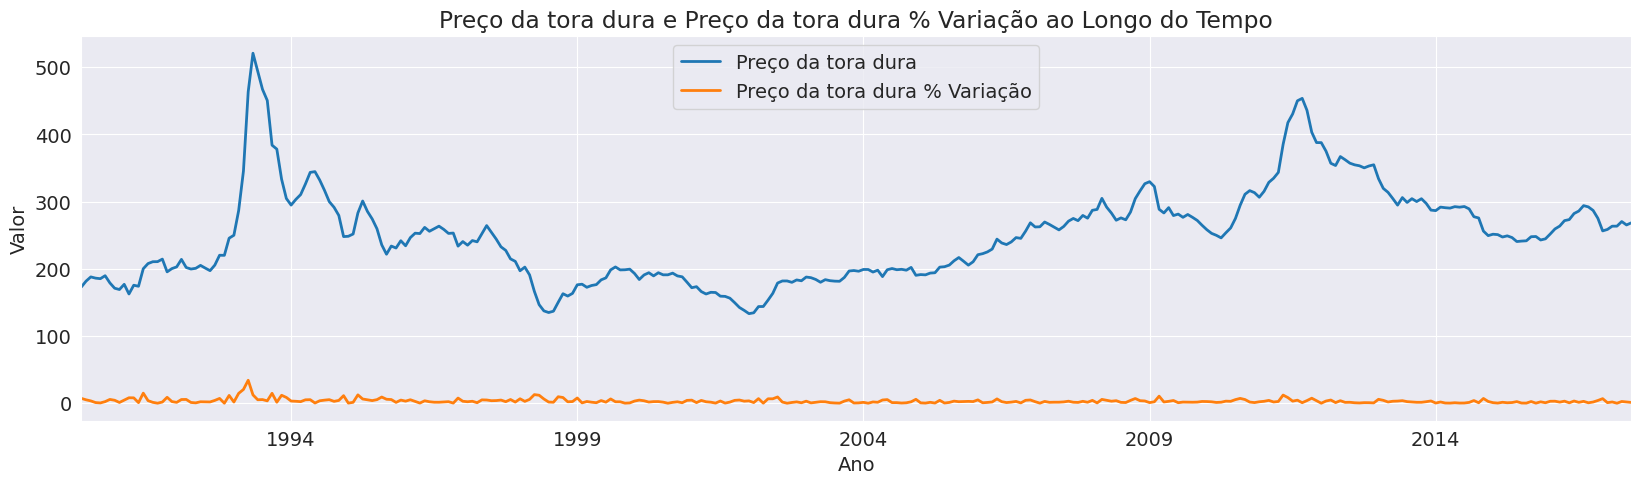

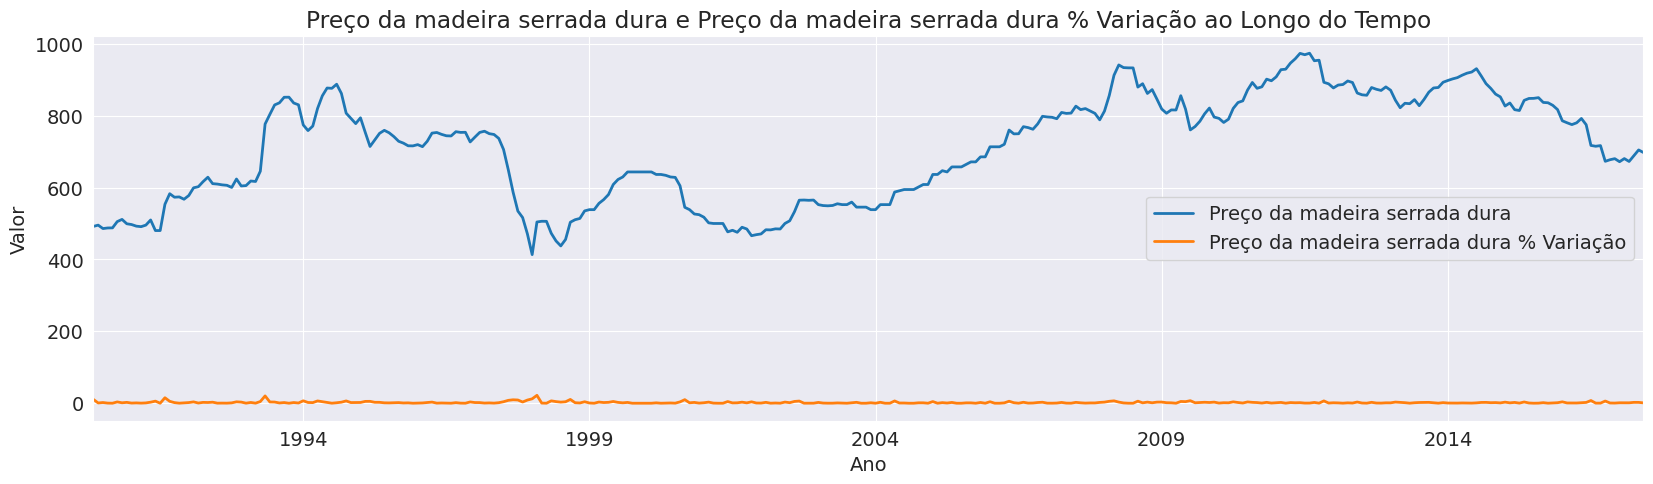

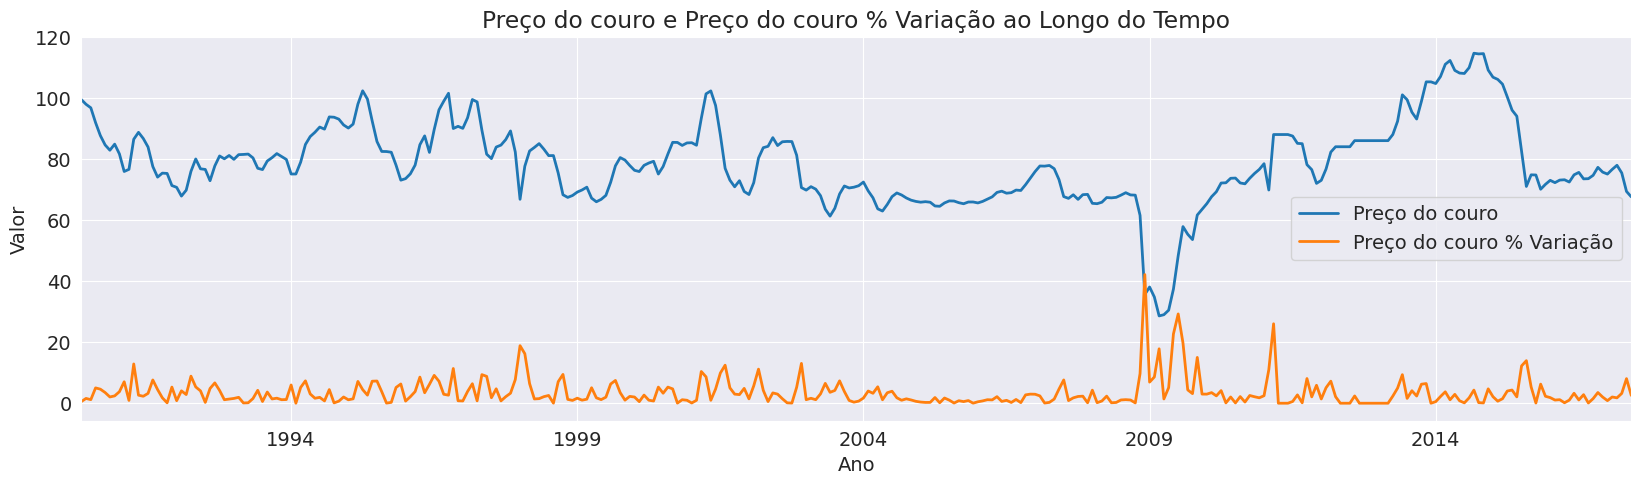

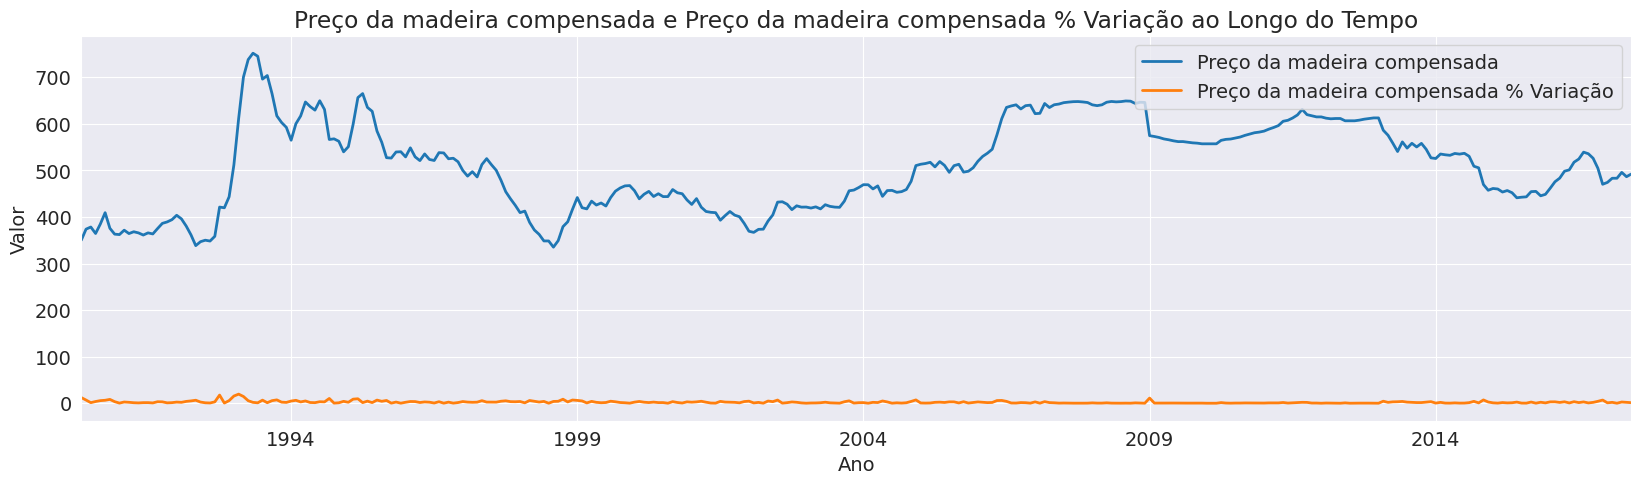

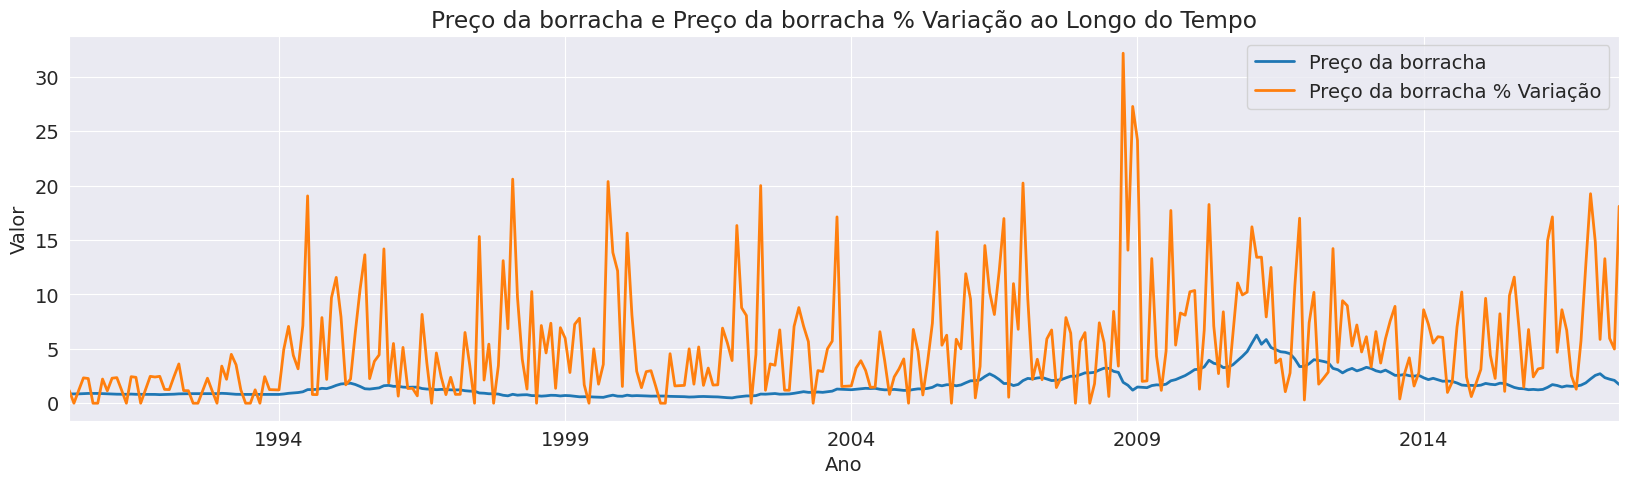

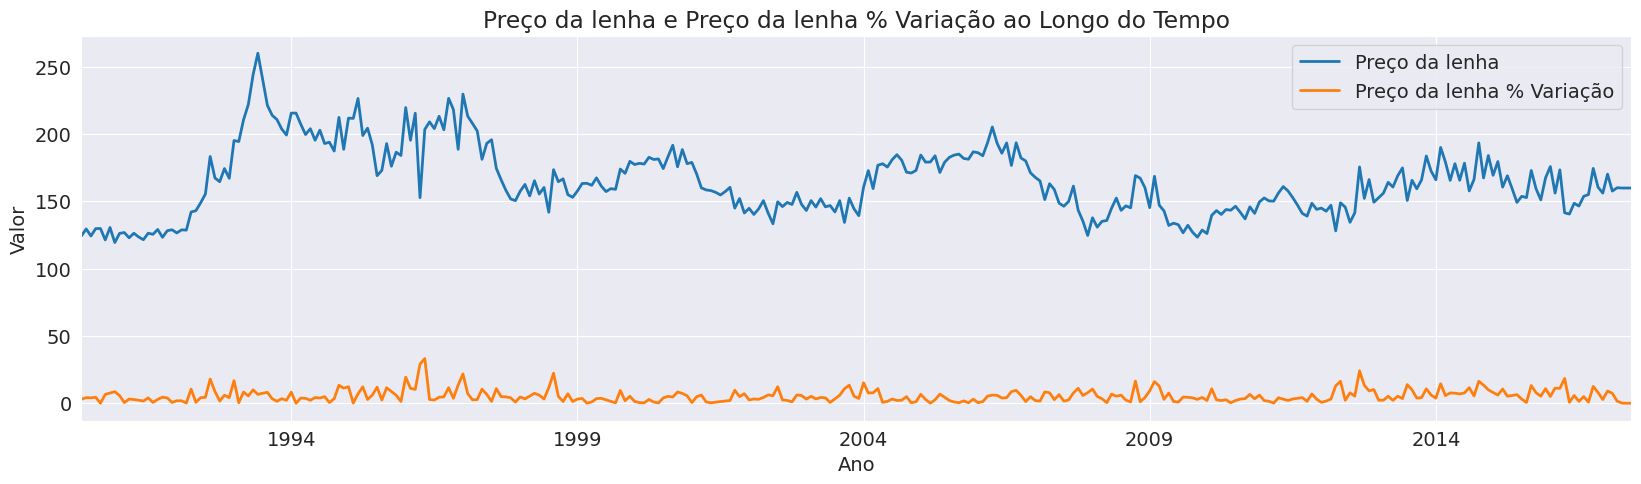

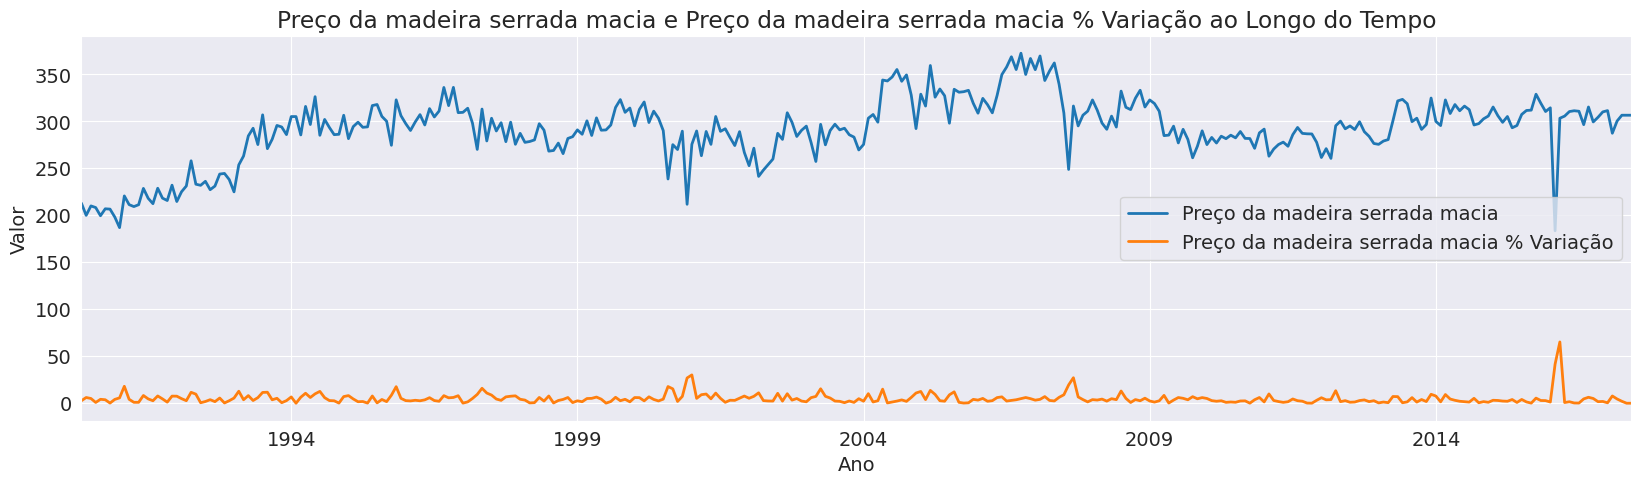

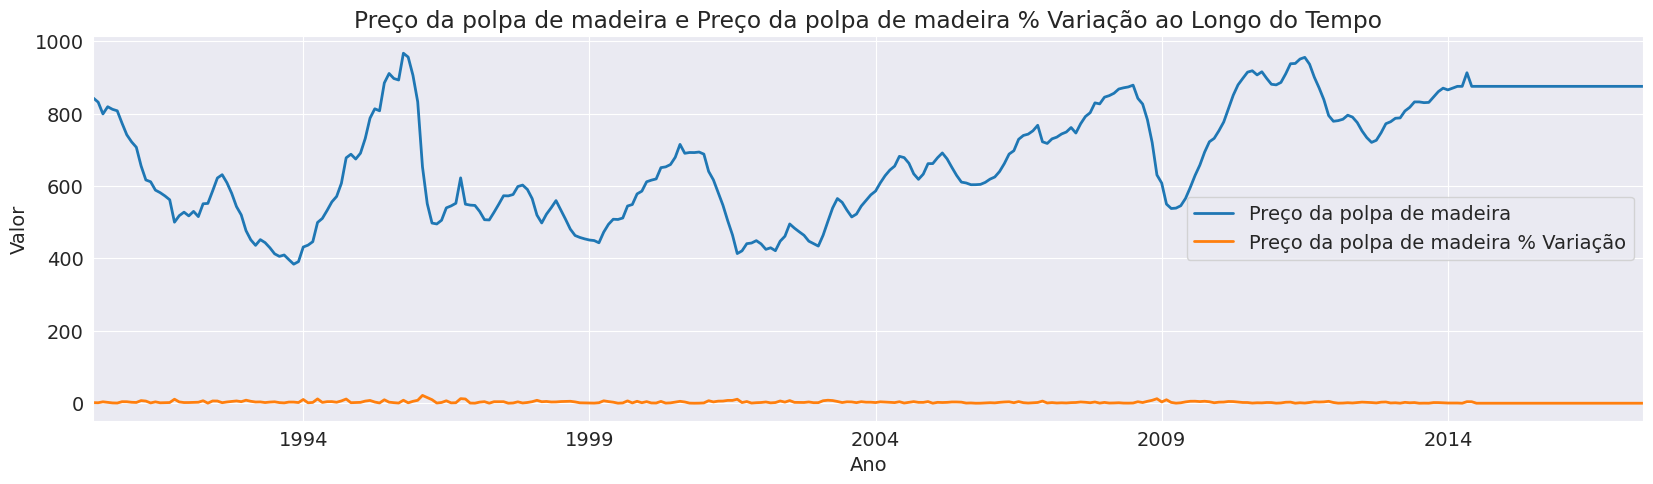

In [76]:
# Função para plotar Preço e % Variação para uma matéria-prima
def plot_price_and_change(dataframe, price_col, change_col):
    """
    Plota a série temporal do preço e da variação percentual para uma matéria-prima.

    Args:
        dataframe (pd.DataFrame): O DataFrame contendo os dados.
        price_col (str): O nome da coluna de preço.
        change_col (str): O nome da coluna de variação percentual.
    """
    axes = dataframe[[price_col, change_col]].plot(figsize=(20, 5), subplots=False, linewidth=2)
    axes.set_ylabel('Valor') # Rótulo genérico para o eixo Y, pois contém preço e variação
    axes.set_xlabel('Ano')
    plt.title(f'{price_col} e {change_col} ao Longo do Tempo') # Título para cada gráfico
    plt.show()

# Lista de matérias-primas e suas colunas de variação percentual correspondentes
materials_and_change_cols = [
    ("Preço da lã grossa", "Preço da lã grossa % Variação"),
    ("Preço Copra", "Preço da Copra % Variação"),
    ("Preço do algodão", "Preço do algodão % Variação"),
    ("Preço de lã fina", "Preço de lã fina % Variação"),
    ("Preço da tora dura", "Preço da tora dura % Variação"),
    ("Preço da madeira serrada dura", "Preço da madeira serrada dura % Variação"),
    ("Preço do couro", "Preço do couro % Variação"),
    ("Preço da madeira compensada", "Preço da madeira compensada % Variação"),
    ("Preço da borracha", "Preço da borracha % Variação"),
    ("Preço da lenha",  "Preço da lenha % Variação"),
    ("Preço da madeira serrada macia", "Preço da madeira serrada macia % Variação"),
    ("Preço da polpa de madeira", "Preço da polpa de madeira % Variação")
]

# Gerando os gráficos usando a função
for price_col, change_col in materials_and_change_cols:
    plot_price_and_change(materiaPrima, price_col, change_col)

Os gráficos qgerados mostram a série temporal do preço e da variação percentual para cada matéria-prima individualmente ao longo do tempo.

Para cada par de gráficos de uma matéria-prima (como "Preço da lã grossa" e "Preço da lã grossa % Variação"), você vê:

 * **Gráfico de Preço:** Uma linha mostrando como o preço absoluto daquela matéria-prima mudou ao longo dos anos (no eixo X). O eixo Y representa o preço em dólares ($). Isso permite observar a tendência geral do preço, picos, quedas e ciclos ao longo do tempo.
 * **Gráfico de Variação Percentual:** Uma linha mostrando a mudança percentual mensal no preço daquela matéria-prima ao longo do tempo. O eixo Y representa a variação percentual. Este gráfico destaca a volatilidade do preço, mostrando quão grandes e frequentes são as oscilações de preço de um mês para o outro. Valores positivos indicam um aumento no preço em relação ao mês anterior, e valores negativos (embora você tenha tratado os negativos para se tornarem positivos) indicam uma diminuição.

Ao visualizar esses gráficos juntos para cada matéria-prima, você pode:

 * Ver como a variação percentual se relaciona com os movimentos de preço. Por exemplo, grandes picos ou quedas no gráfico de preço geralmente correspondem a grandes variações (positivas ou negativas) no gráfico de variação percentual.
 * Comparar a volatilidade de diferentes matérias-primas observando a amplitude das oscilações nos gráficos de variação percentual.

Podemos ver o preço da lã grossa, copra, lã fina, tora dura, madeira serrada dura, couro, madeira compensada, lenha, madeira serrada macia e polpa de madeira variando, ao mesmo tempo, a linha de variação percentual mostrando oscilações relativamente menores em comparação com outras matérias-primas. O inverso dessa análise fica com as matérias primas como preço do algodão e preço da borracha, onde a variação e muito maior que a oscilação de preço.

<h1><b> Respondendo as perguntas </b></h1>

## **1) Descubra a variação normal do preço de cada matéria-prima**

/tmp/ipython-input-77-3252961410.py:9: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(10,10))


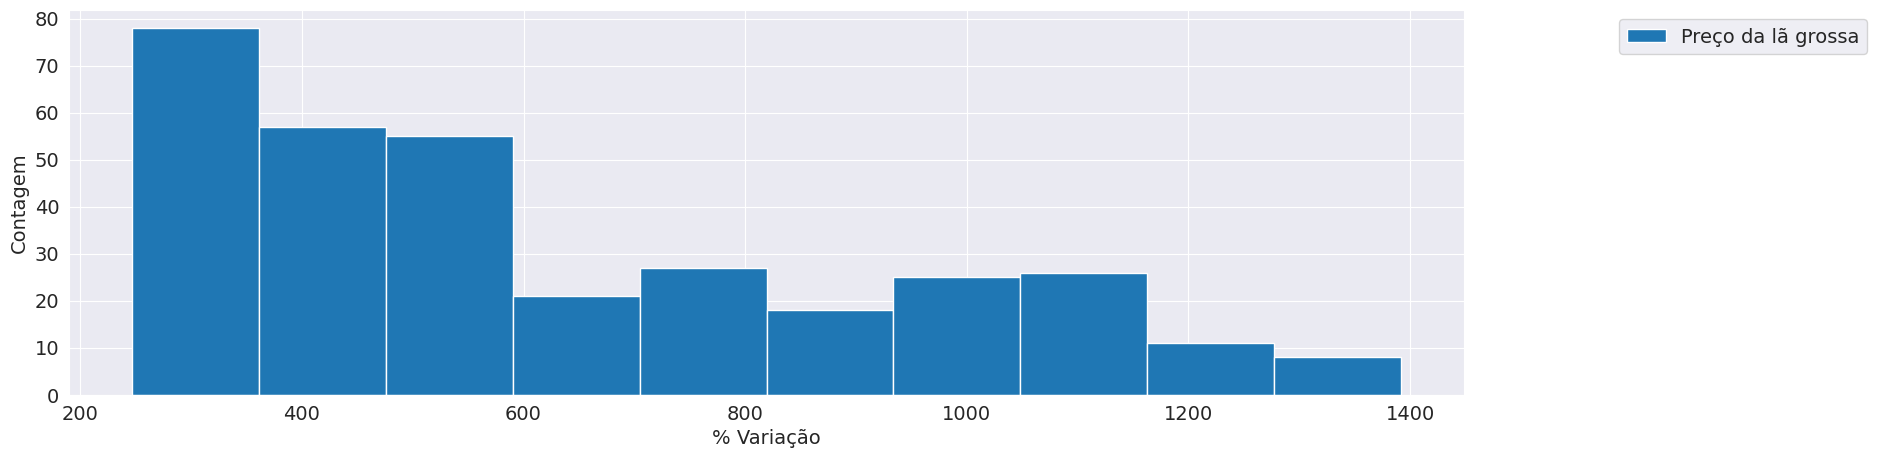

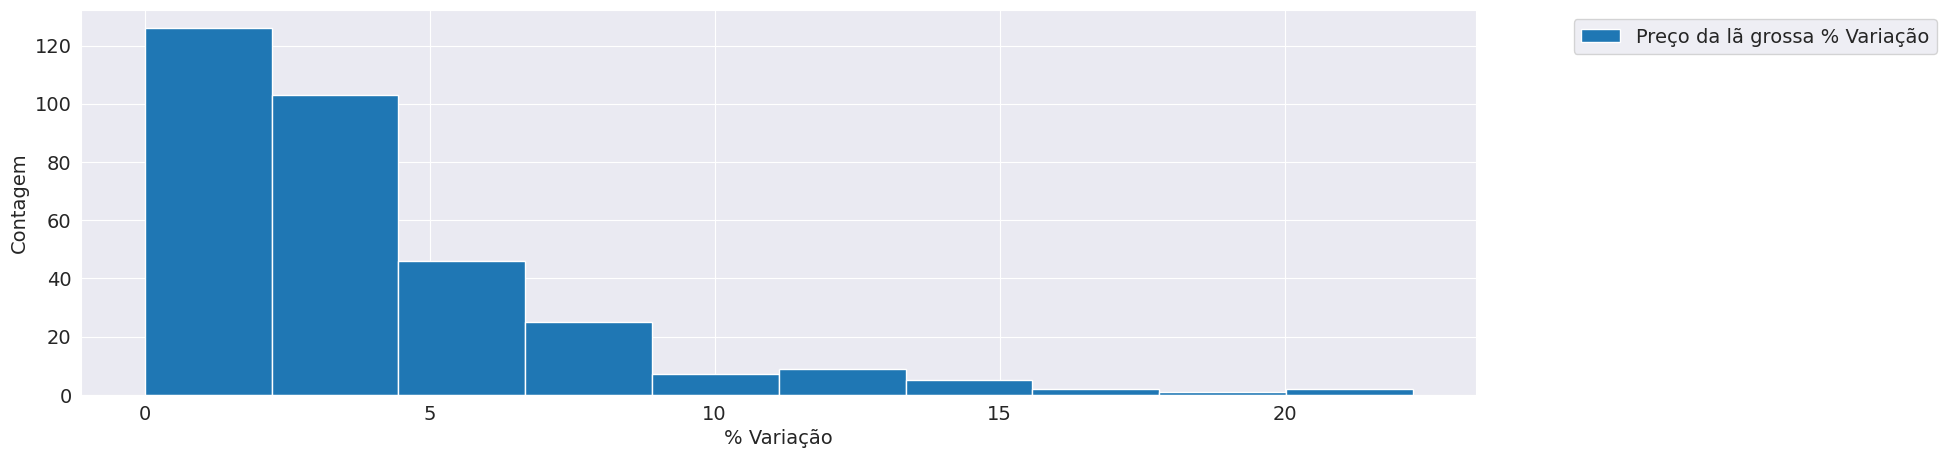

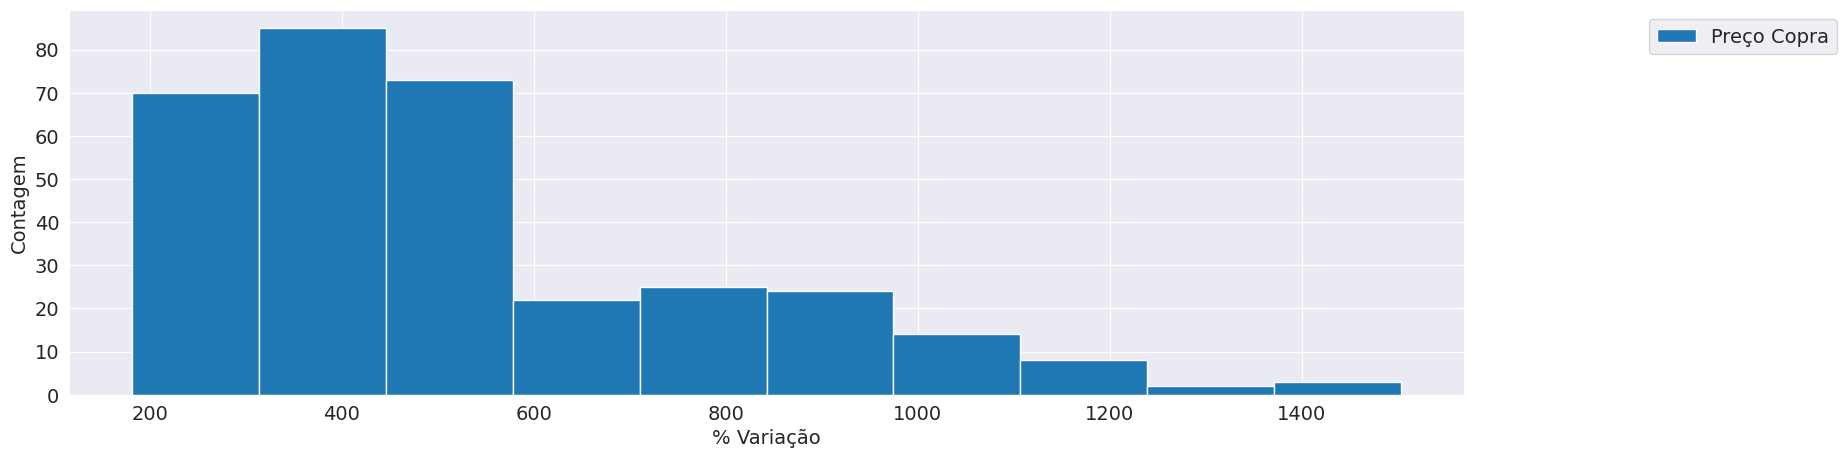

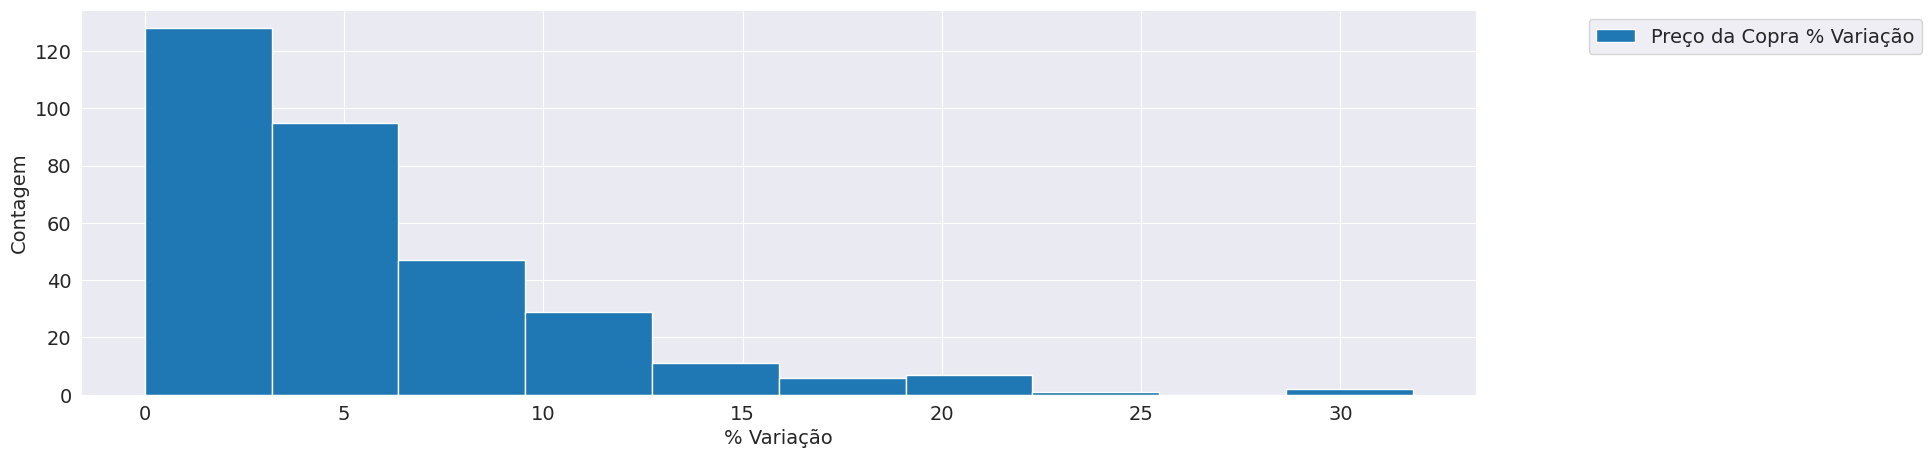

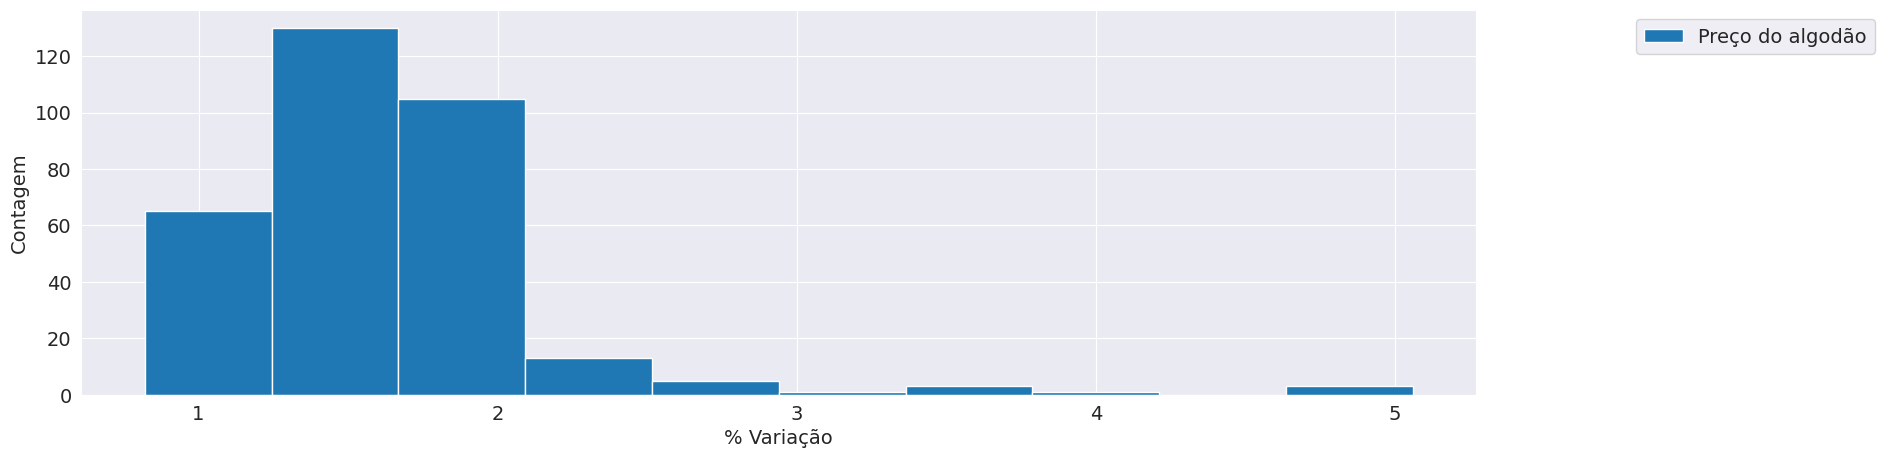

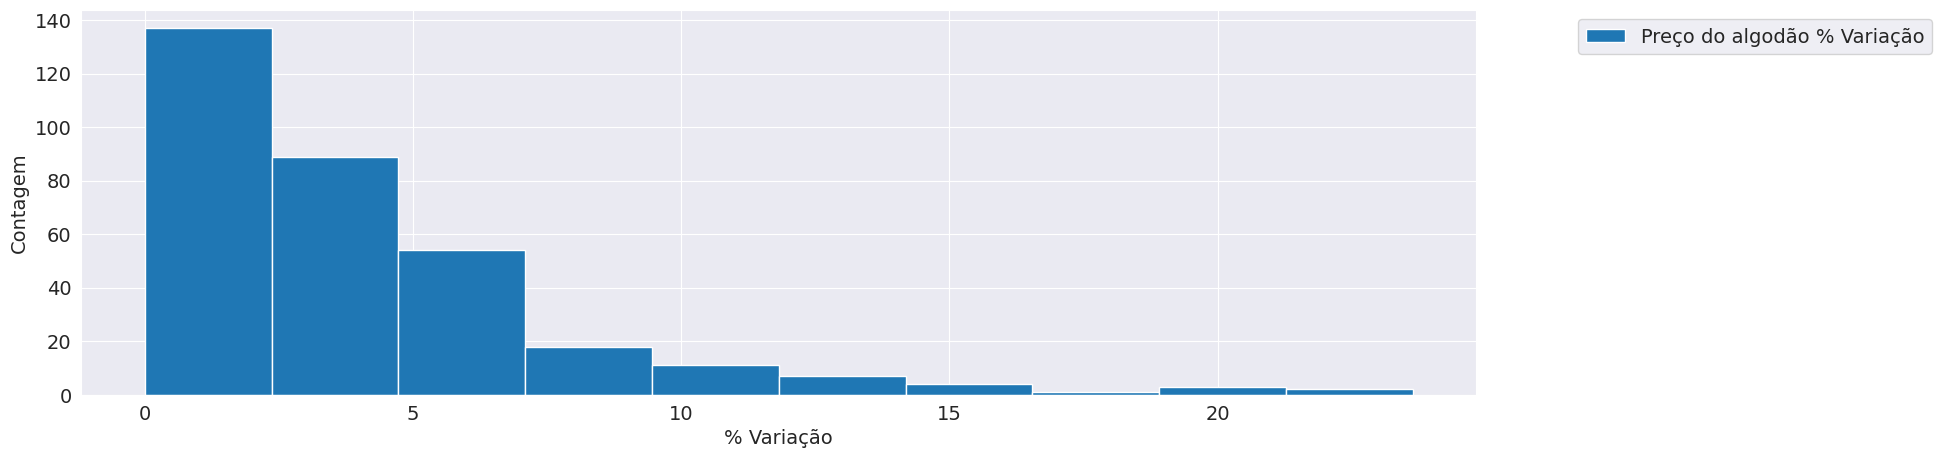

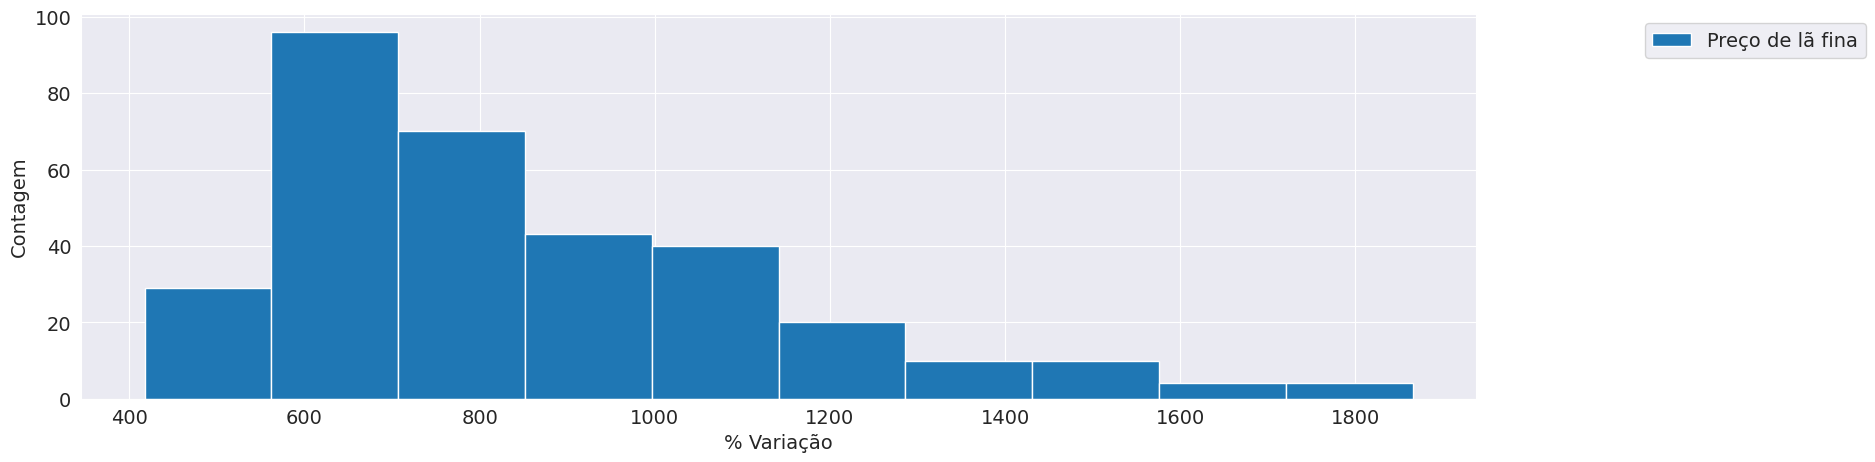

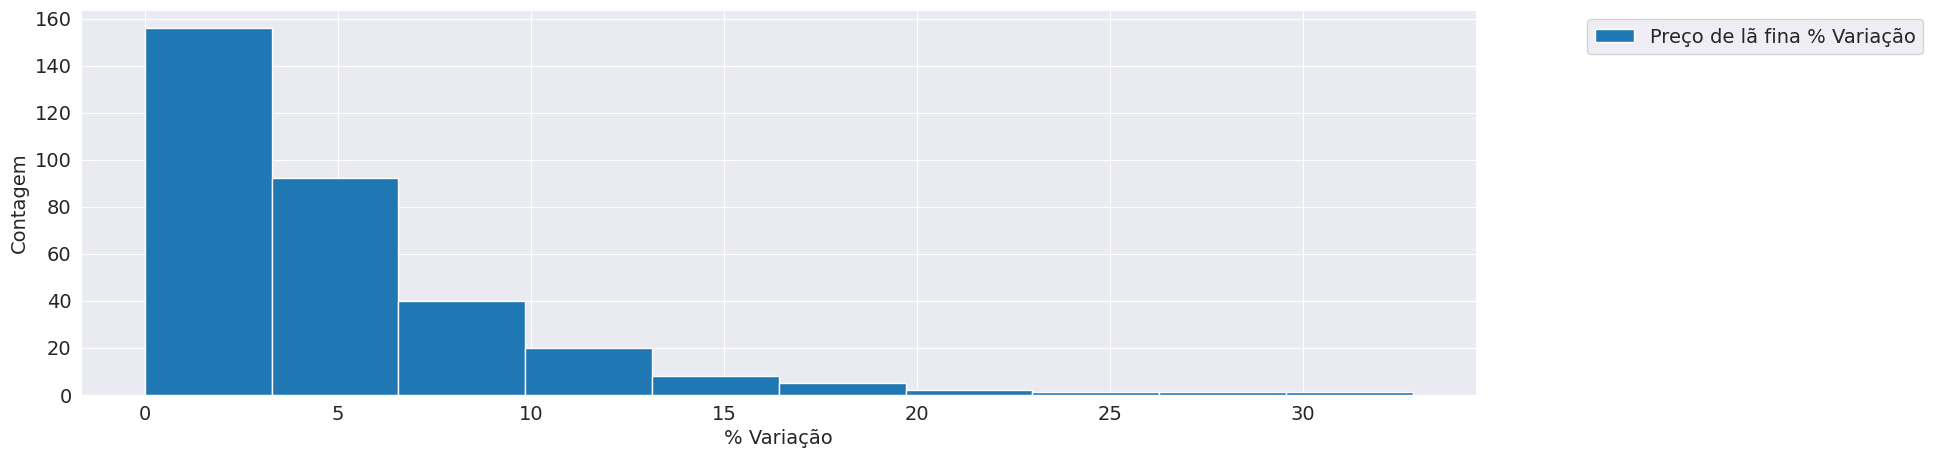

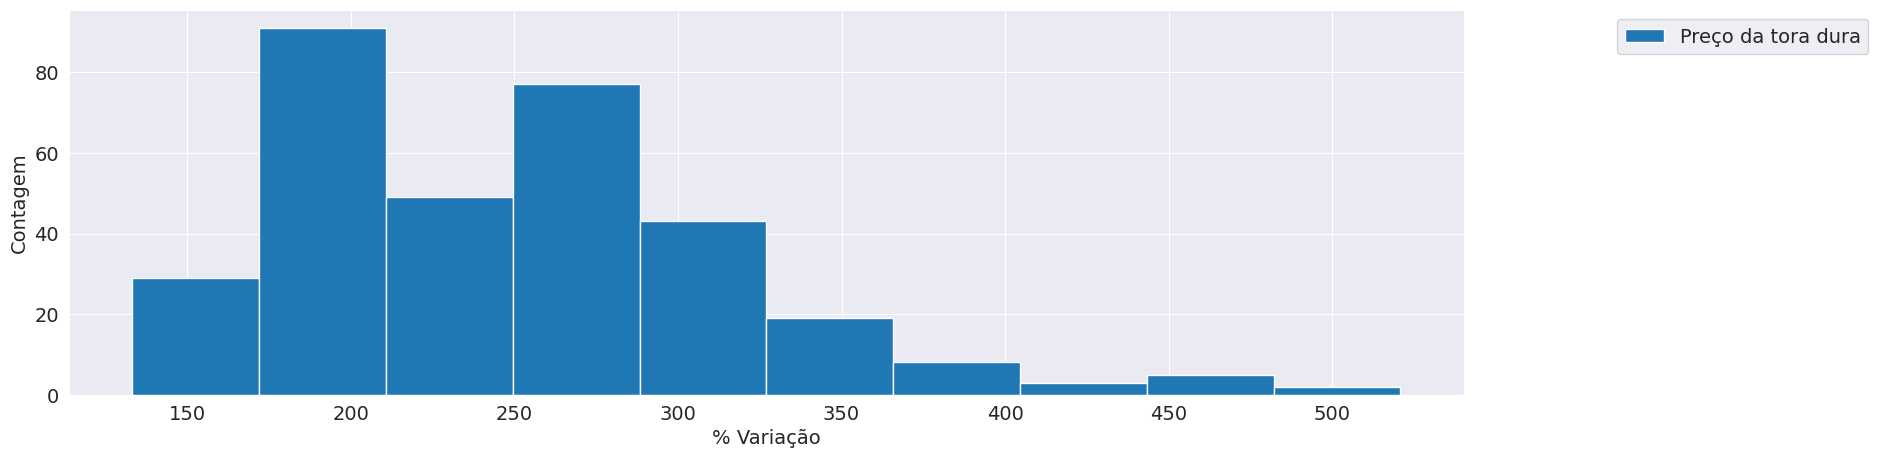

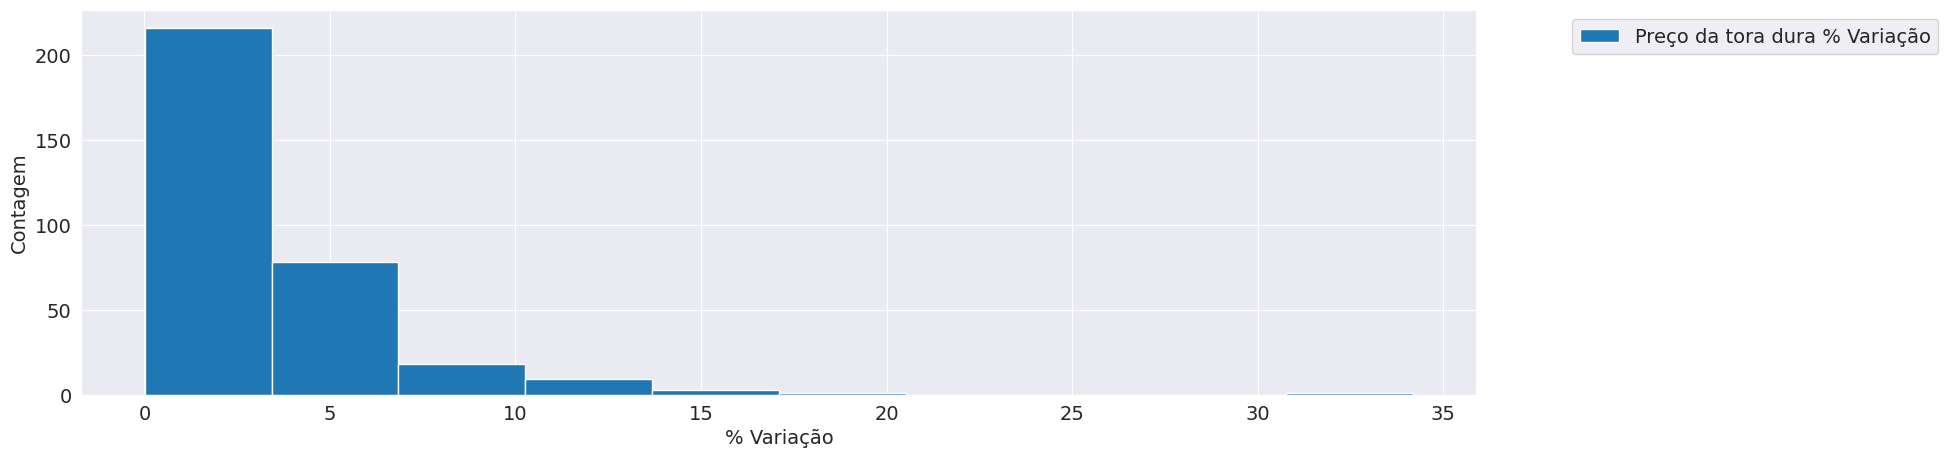

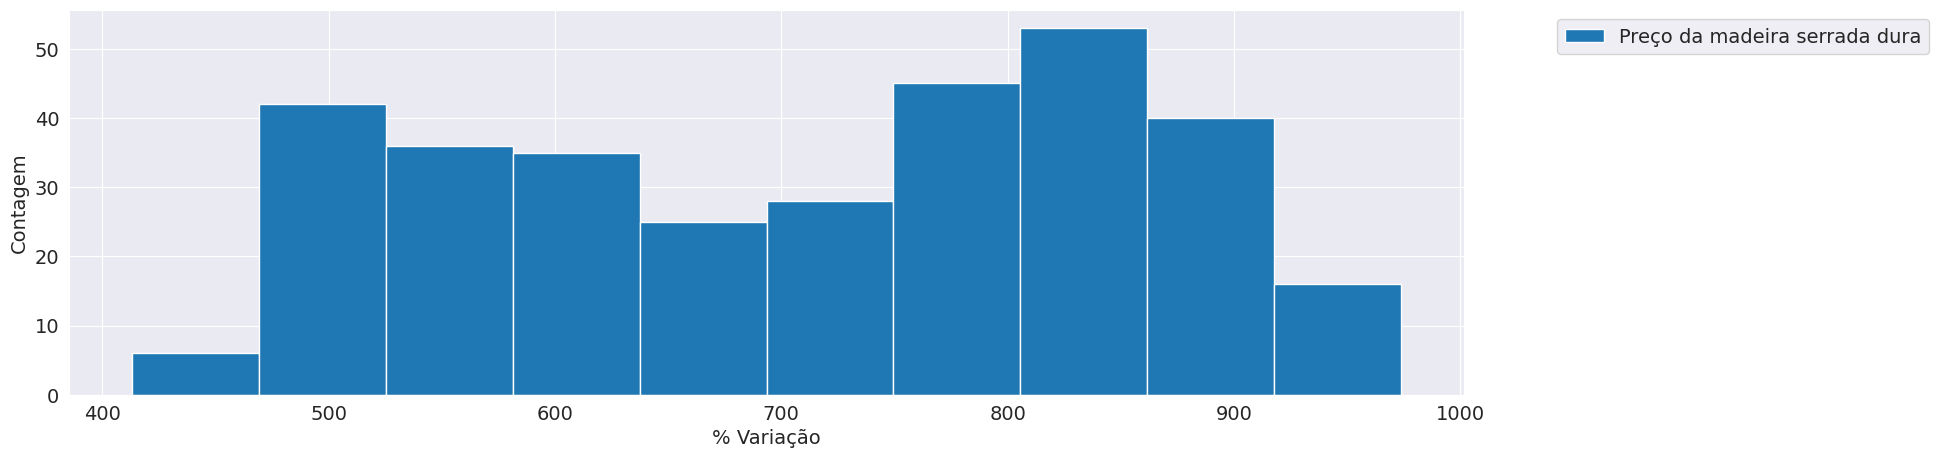

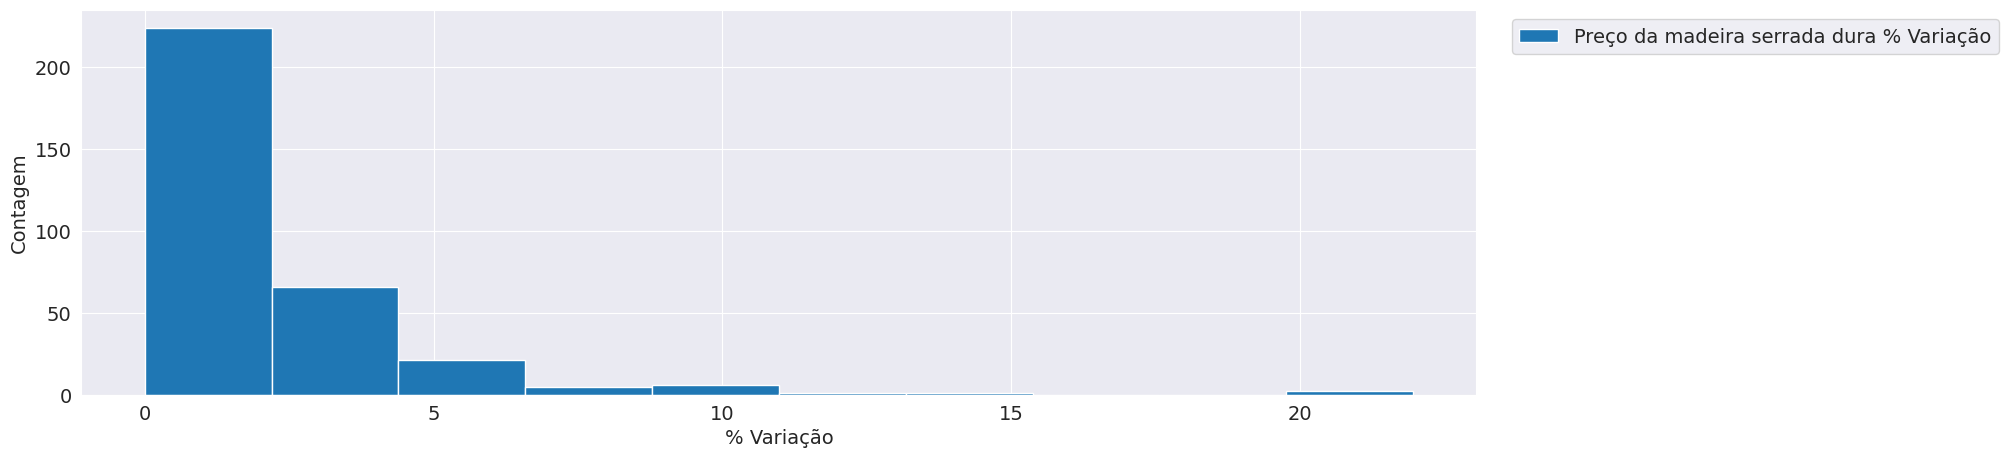

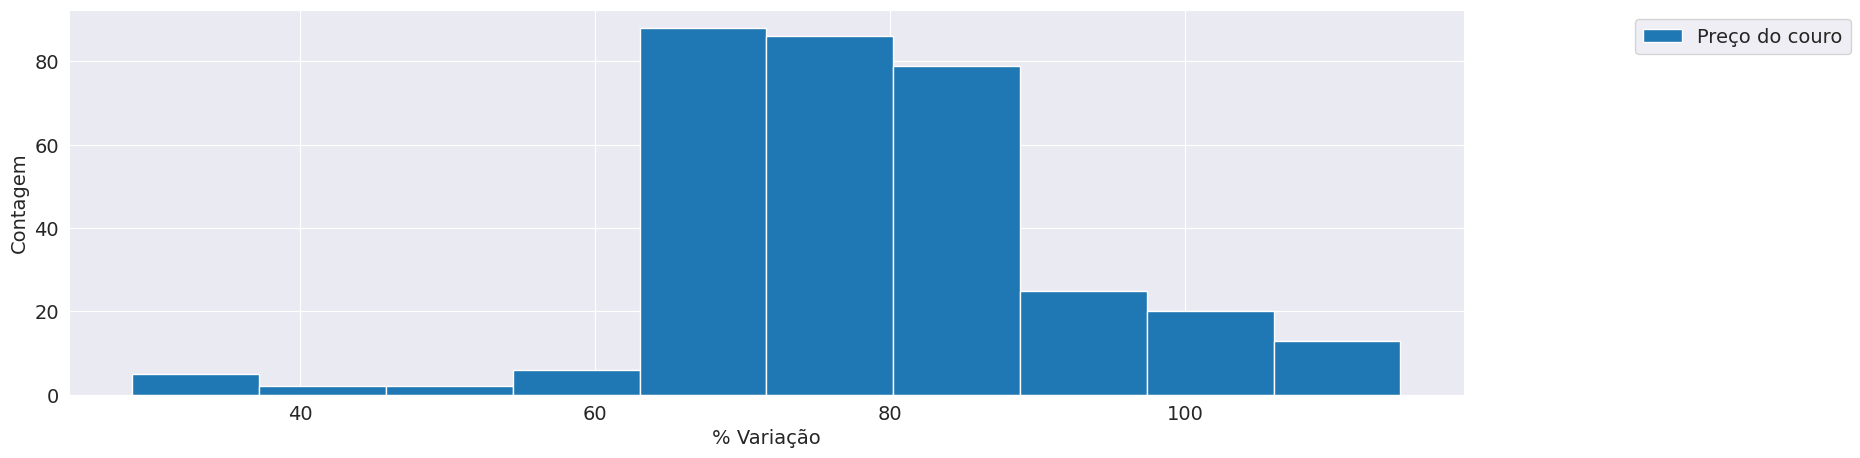

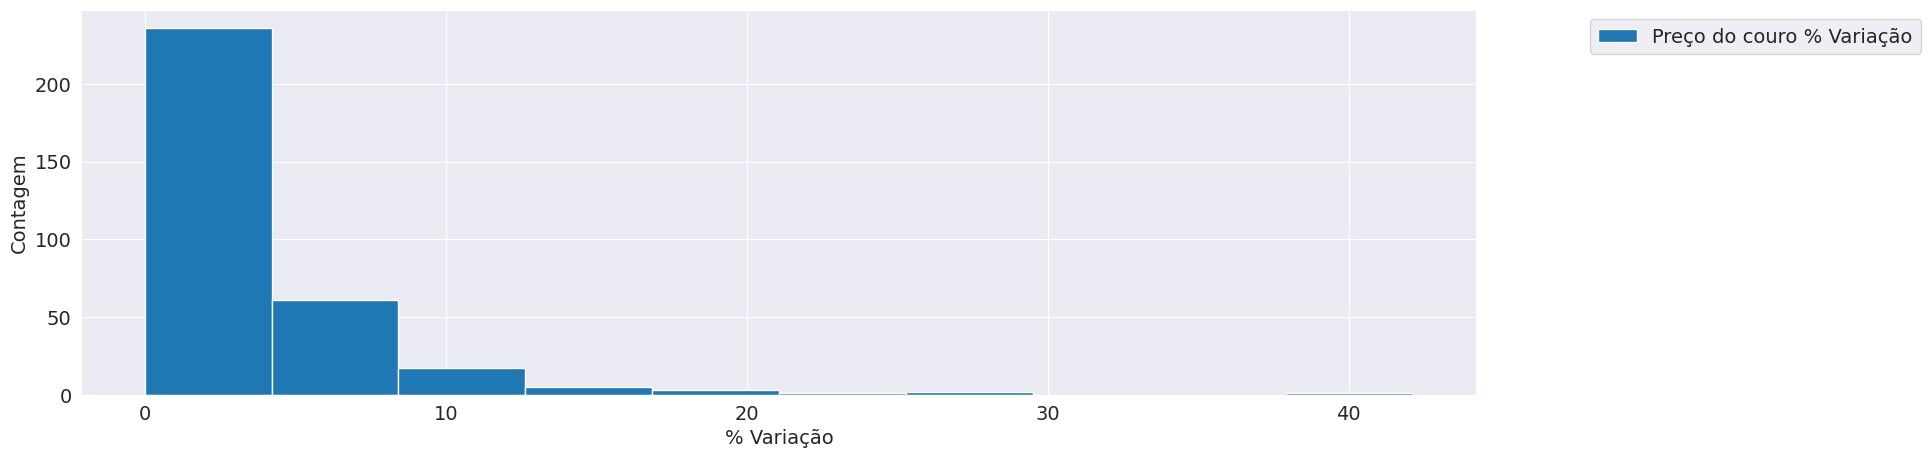

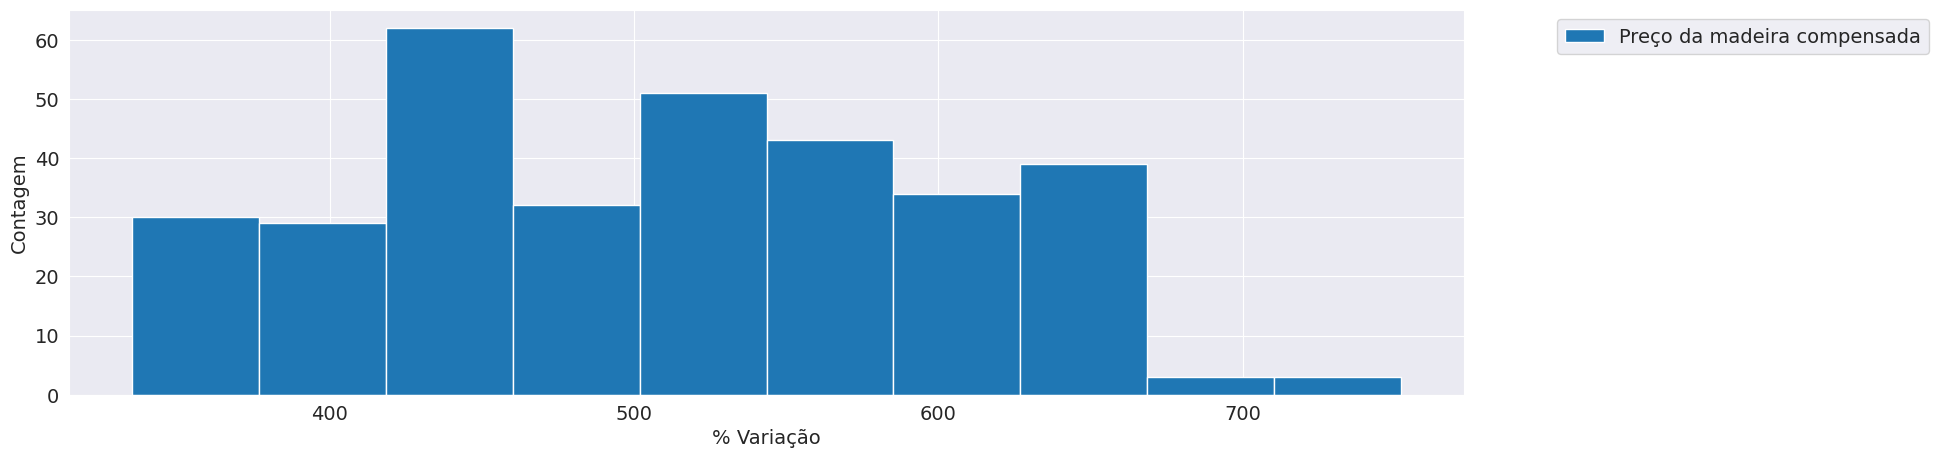

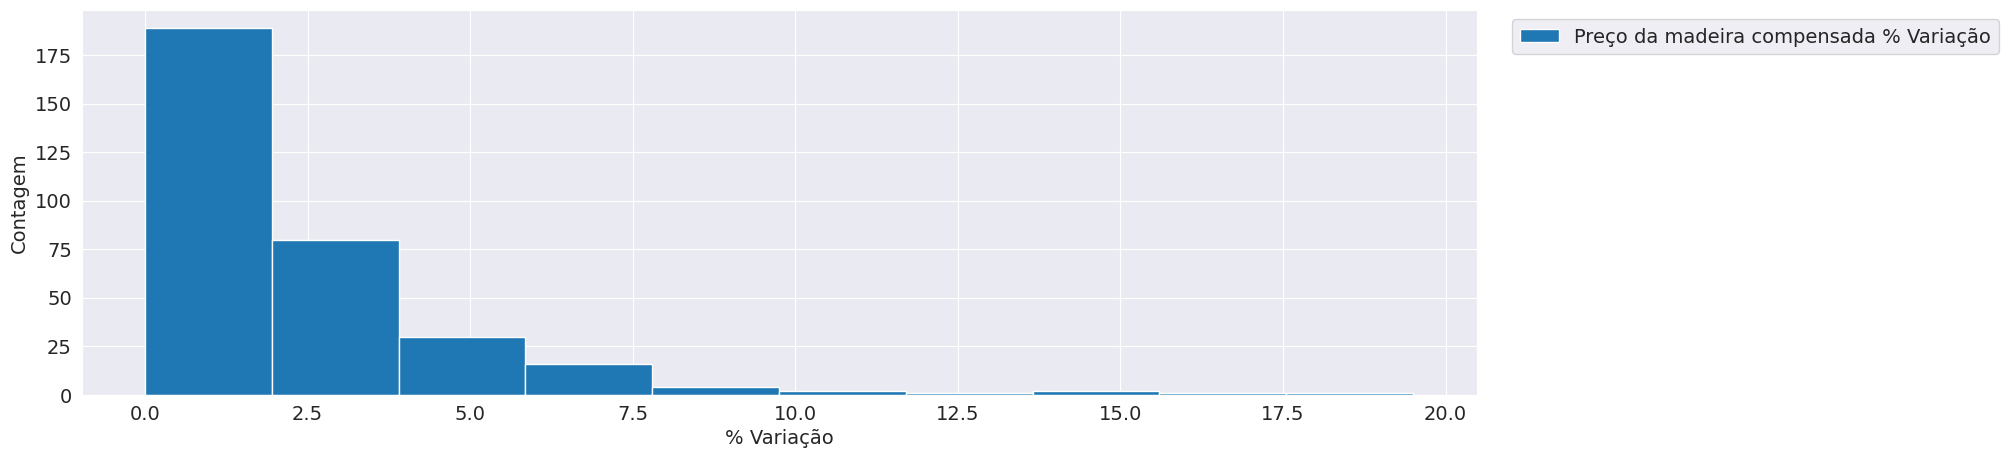

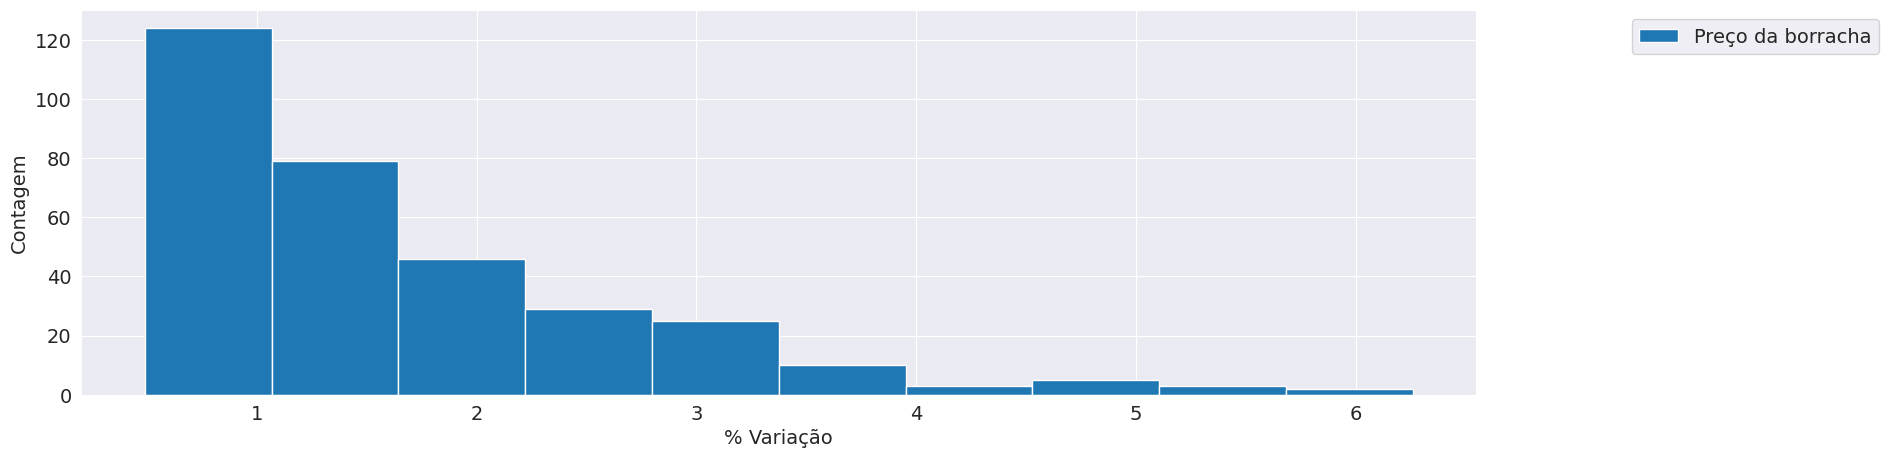

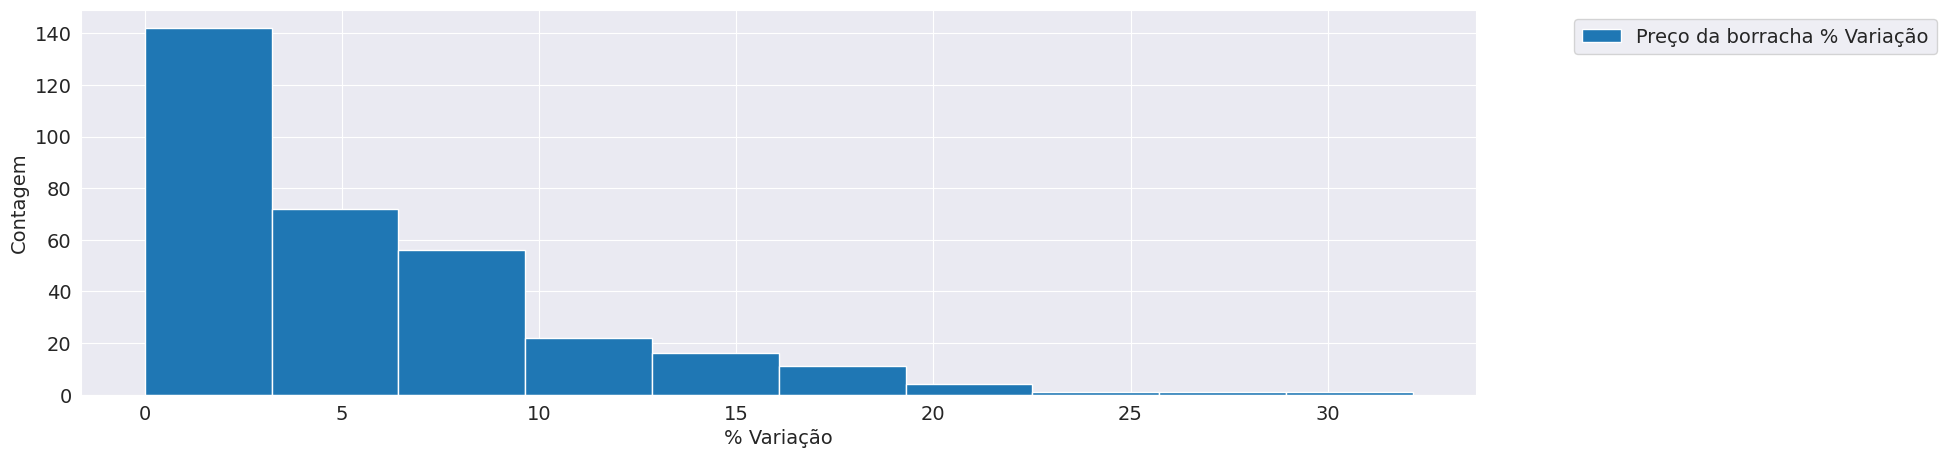

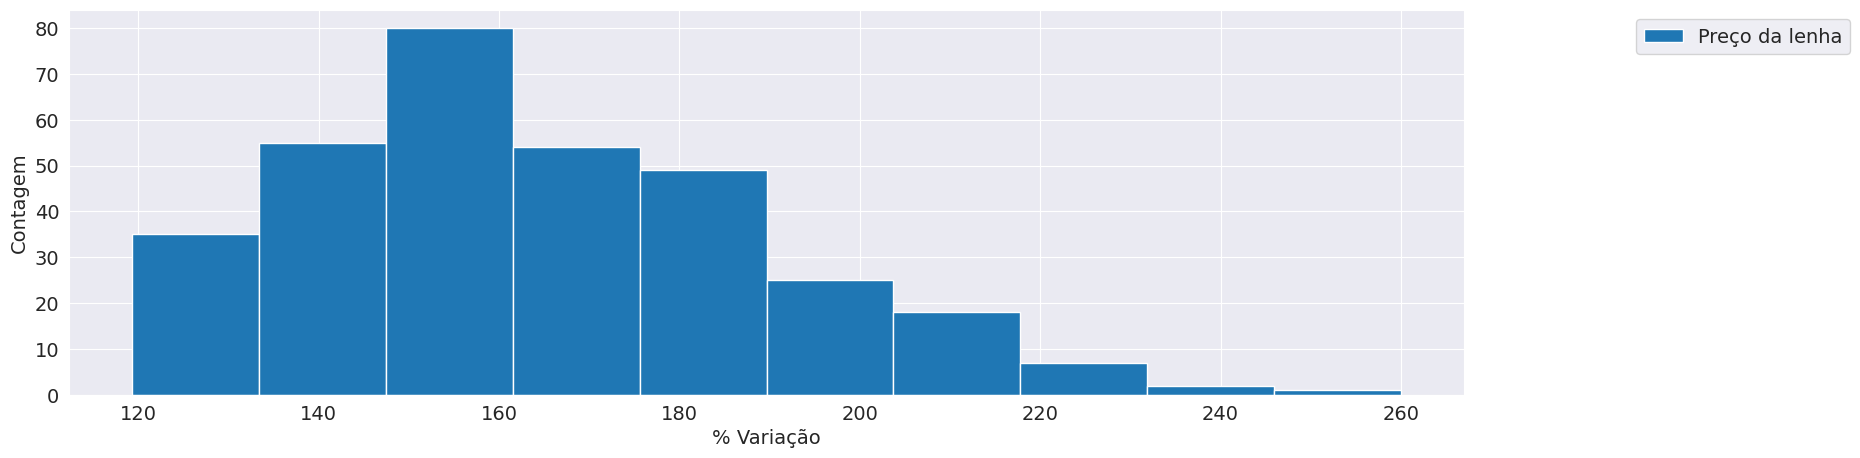

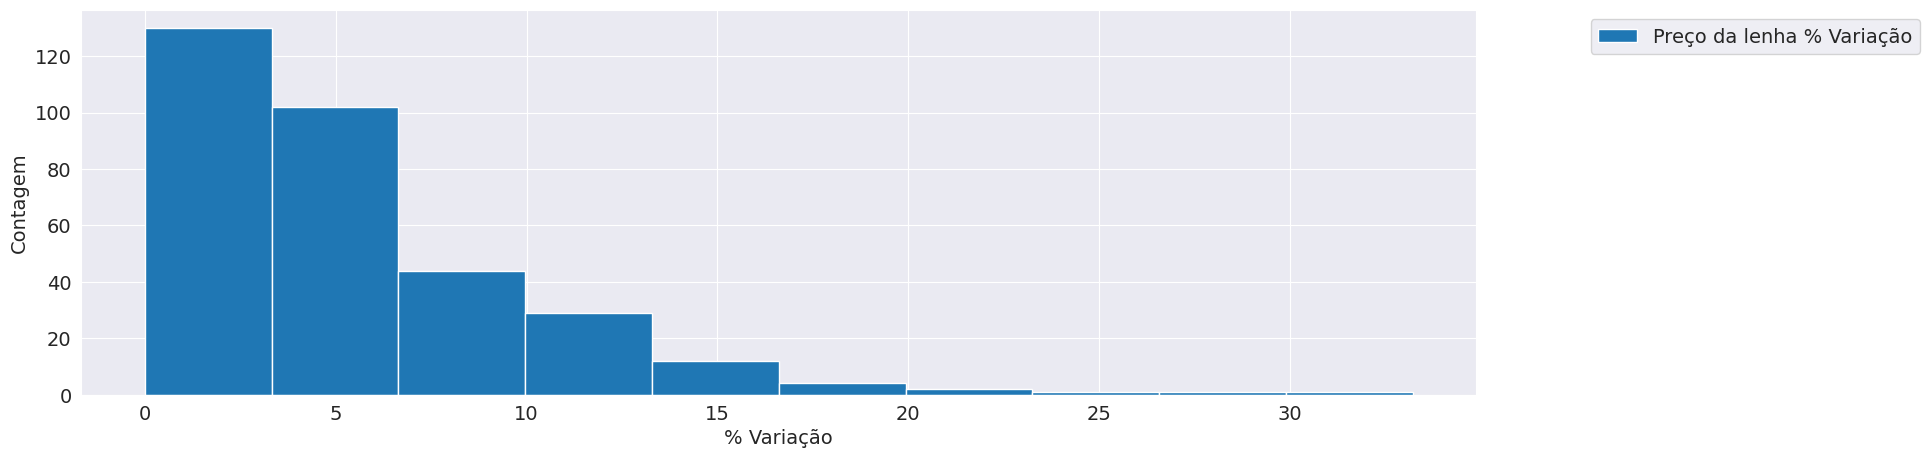

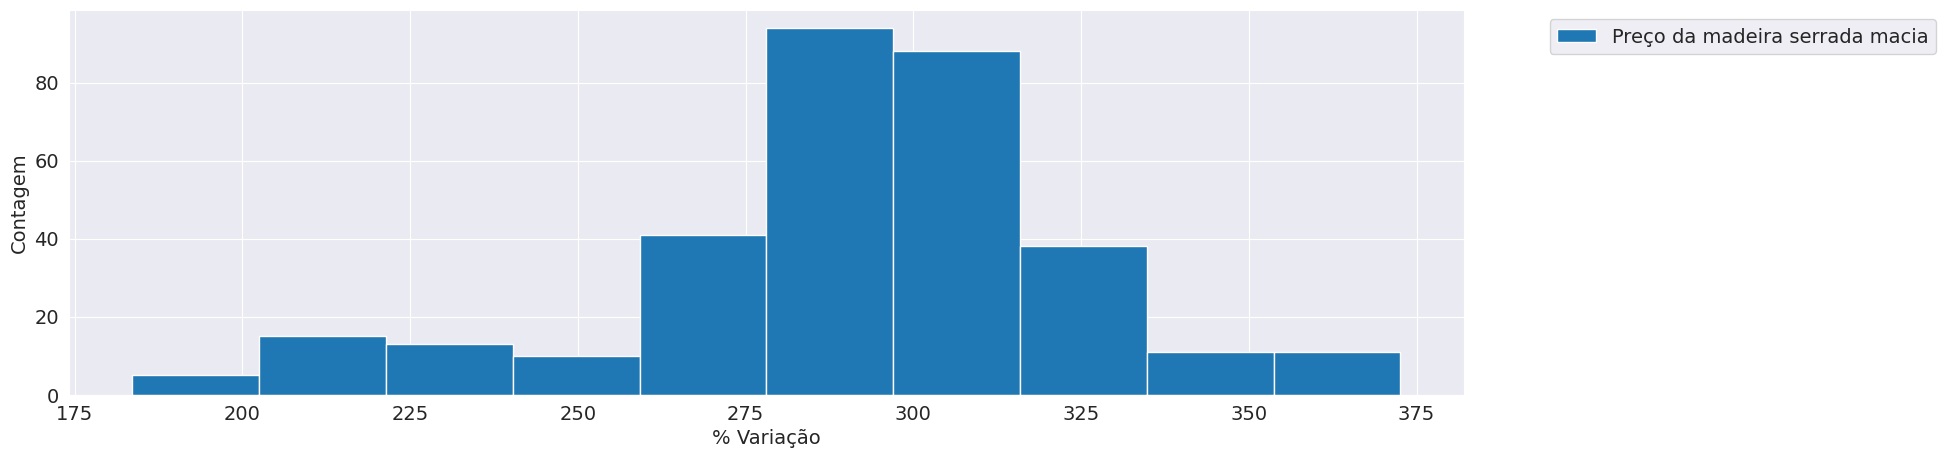

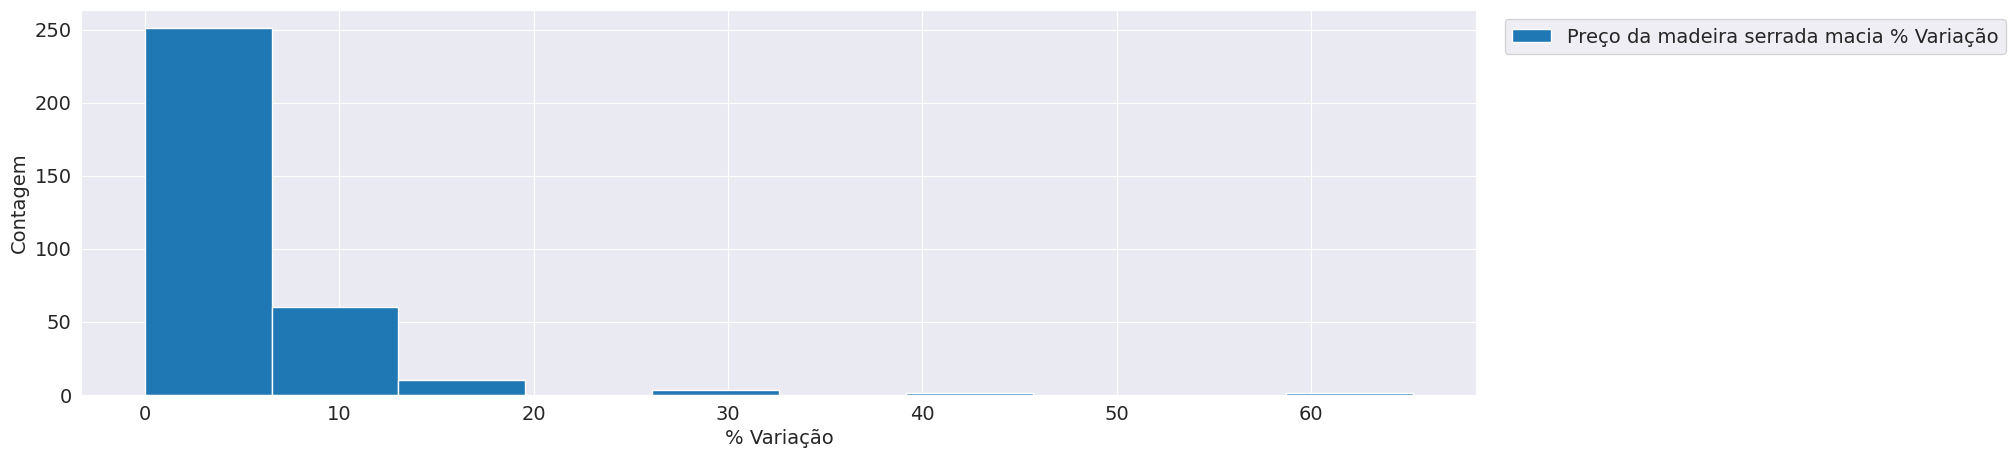

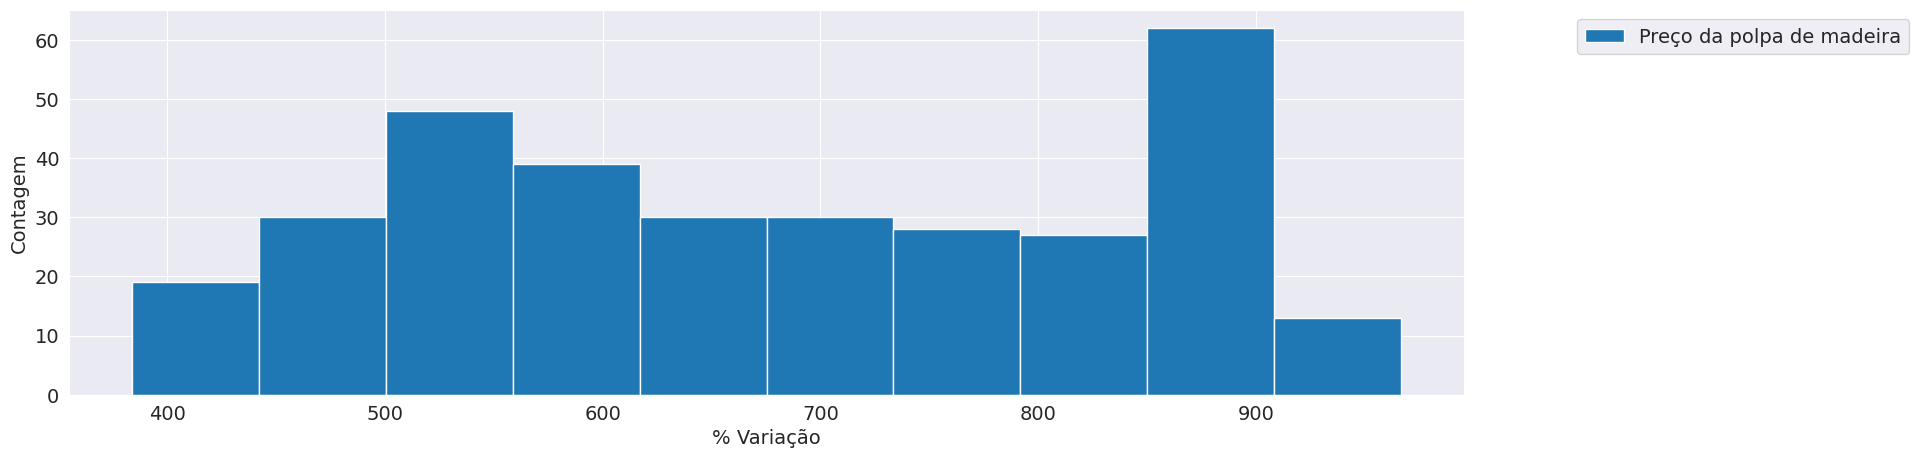

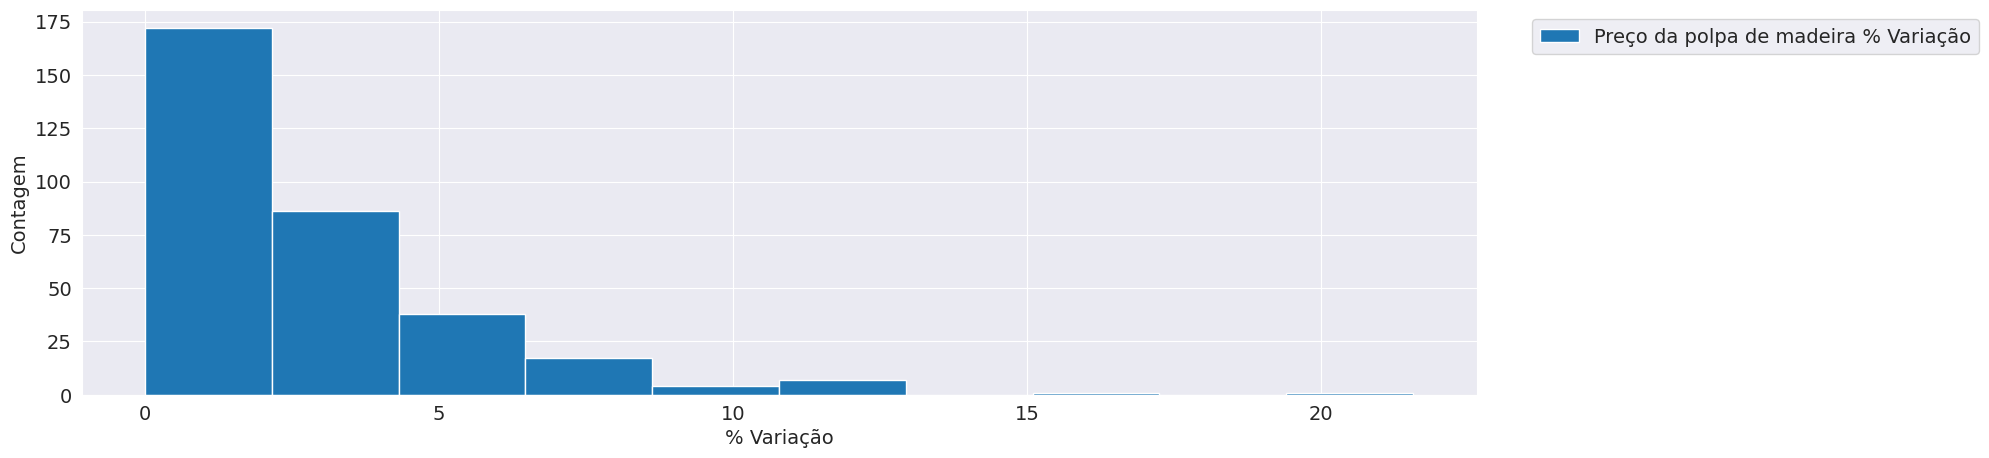

In [77]:
# Selecionando as colunas
changelist=["Preço da lã grossa", "Preço da lã grossa % Variação", "Preço Copra", "Preço da Copra % Variação", "Preço do algodão", "Preço do algodão % Variação","Preço de lã fina", "Preço de lã fina % Variação",
"Preço da tora dura", "Preço da tora dura % Variação", "Preço da madeira serrada dura", "Preço da madeira serrada dura % Variação", "Preço do couro", "Preço do couro % Variação", "Preço da madeira compensada",
"Preço da madeira compensada % Variação", "Preço da borracha", "Preço da borracha % Variação", "Preço da lenha",  "Preço da lenha % Variação", "Preço da madeira serrada macia", "Preço da madeira serrada macia % Variação",
"Preço da polpa de madeira", "Preço da polpa de madeira % Variação"]

# Plotando gráfico
for i in range(len(changelist)):
    plt.figure(figsize=(10,10))
    materiaPrima[changelist[i]].hist(figsize=(18, 5), linewidth=1)
    plt.xlabel('% Variação')
    plt.ylabel('Contagem')
    plt.legend(changelist[i:],loc='upper center',bbox_to_anchor=(1.2,1))

Podemos observar que a maioria das matérias-primas tem % de mudança frequente ideal inferior a 5%, significando que, para a maioria dos materiais, os picos dos histogramas estão localizados nos intervalos de variação percentual abaixo de 5%. Isso sugere que a variação mensal mais comum para essas matérias-primas é relativamente baixa.

## **2) Encontre a matéria-prima que tem o menor preço ao longo dos anos**

Text(0.5, 0.98, 'Comparação de preços de matérias-primas')

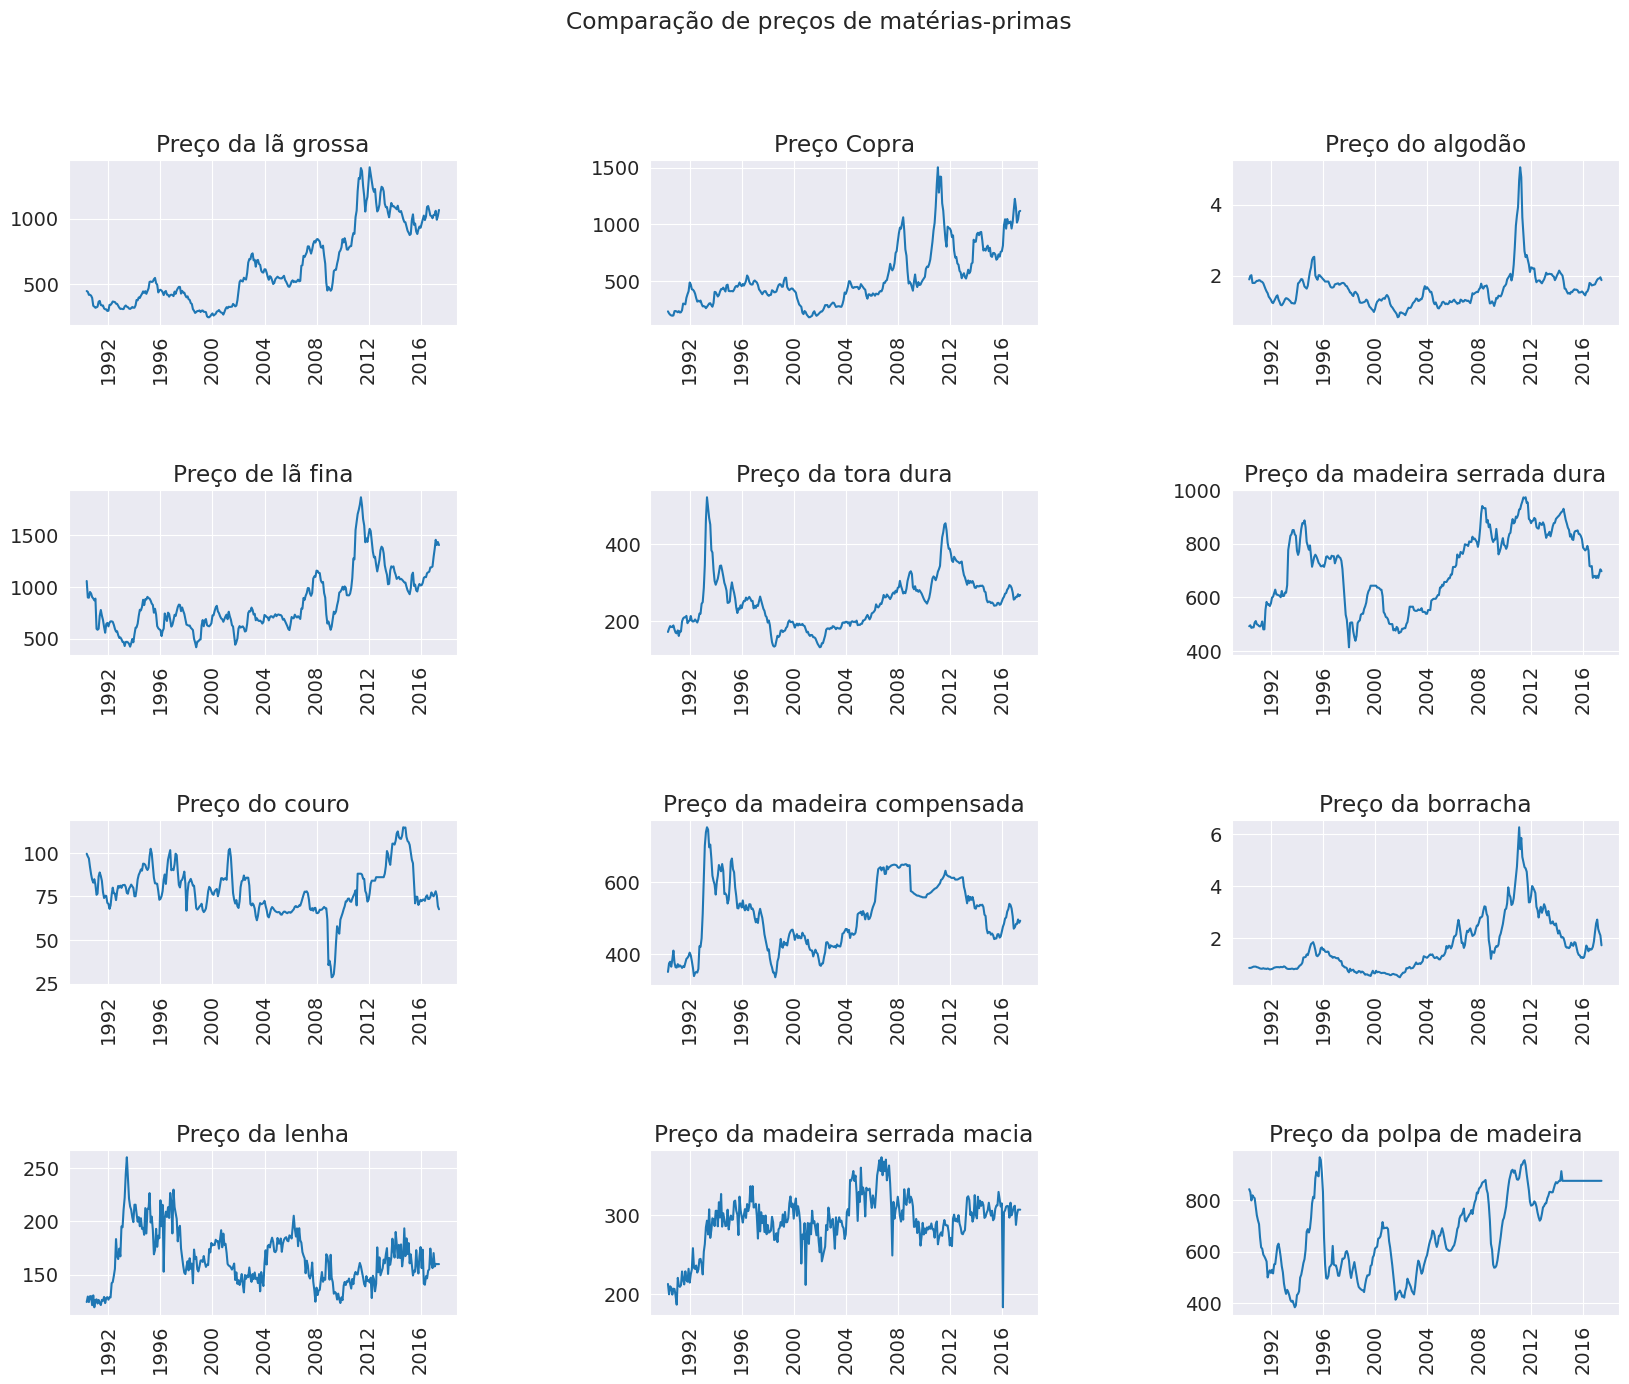

In [78]:
# Selecionando lista de materias-primas
materialslist=['Preço da lã grossa',  'Preço Copra', 'Preço do algodão', 'Preço de lã fina', 'Preço da tora dura', 'Preço da madeira serrada dura', 'Preço do couro', 'Preço da madeira compensada', 'Preço da borracha',
'Preço da lenha', 'Preço da madeira serrada macia', 'Preço da polpa de madeira']

# Criando a Figura e Subplots
plt.figure(figsize=(20, 15))

# Plotando gráfico
for i in range(len(materialslist)):
    plt.subplot(4,3,i+1)
    plt.subplots_adjust( hspace=1 ,wspace=0.5)
    plt.title(materialslist[i])
    plt.plot(materiaPrima[materialslist[i]])
    plt.xticks(rotation=90)
plt.suptitle("Comparação de preços de matérias-primas")

Podemos ver que o algodão e a borracha são de preços mais baixos vamos comparar preços para entender melhor qual é o mais baixo.

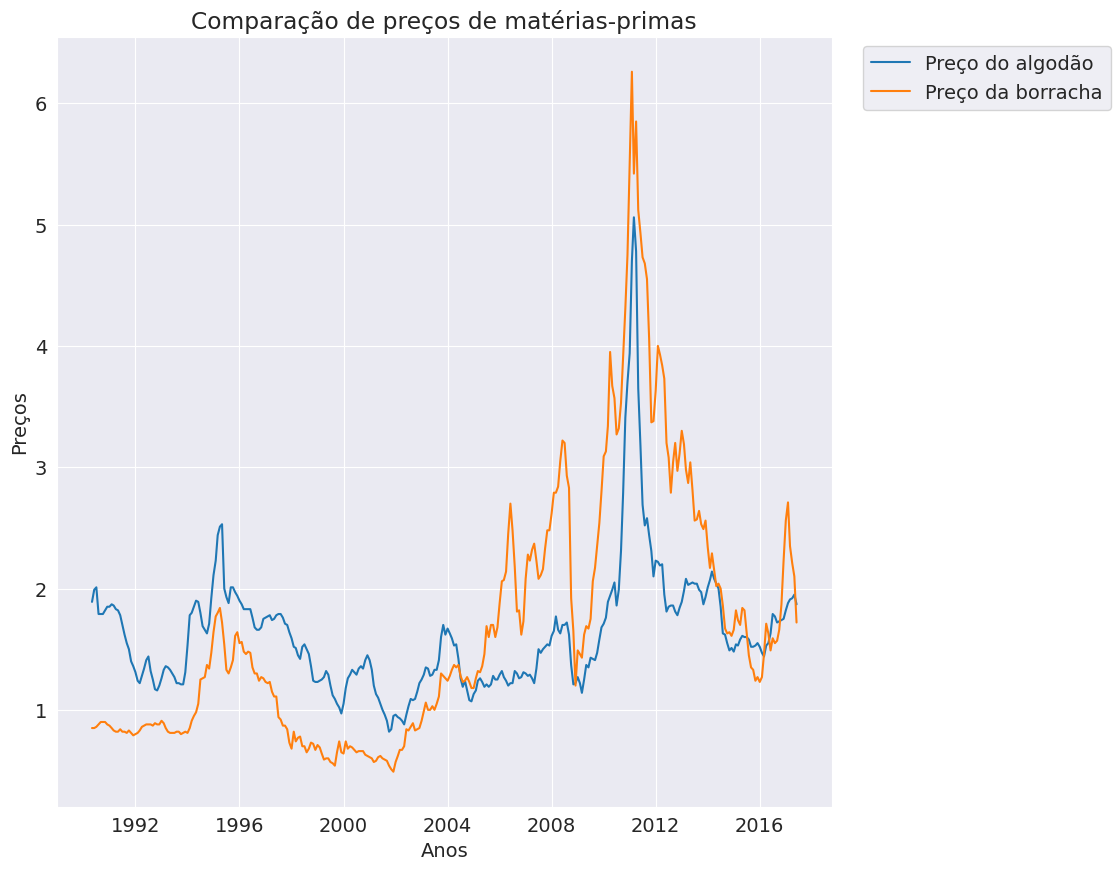

In [79]:
# Criando a Figura e Subplots
plt.figure(figsize=(10, 10))

# Selecionando lista de materias-primas
plt.plot(materiaPrima[['Preço do algodão', 'Preço da borracha']])

# Plotando gráfico
plt.title("Comparação de preços de matérias-primas")
plt.xlabel('Anos')
plt.ylabel('Preços')
plt.legend(['Preço do algodão', 'Preço da borracha'],loc='upper center',bbox_to_anchor=(1.2,1))

Algodão é matéria-prima de menor preço nos últimos anos.



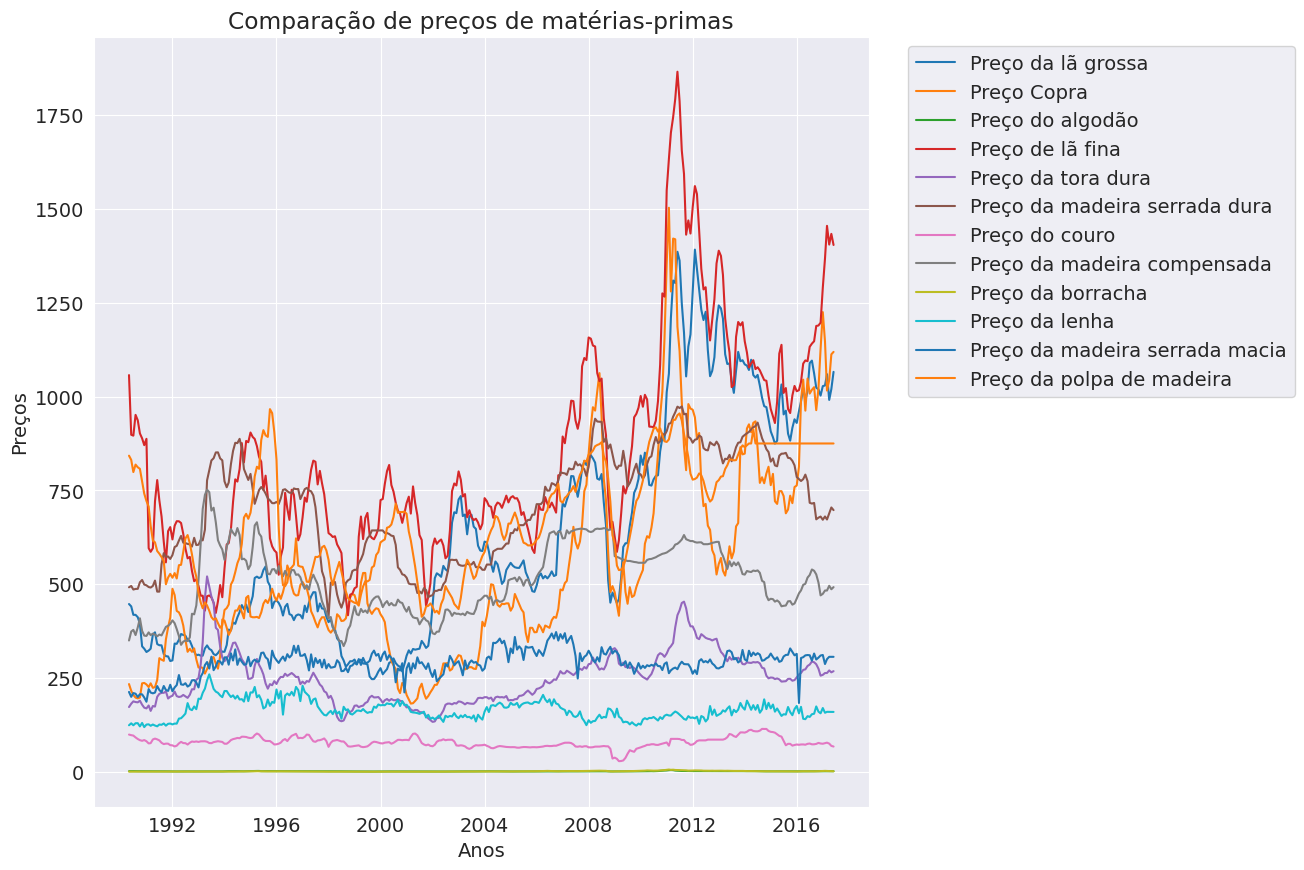

In [80]:
# Criando a Figura e Subplots
plt.figure(figsize=(10, 10))

# Selecionando lista de materias-primas
plt.plot(materiaPrima[['Preço da lã grossa',  'Preço Copra', 'Preço do algodão', 'Preço de lã fina', 'Preço da tora dura', 'Preço da madeira serrada dura', 'Preço do couro', 'Preço da madeira compensada', 'Preço da borracha',
'Preço da lenha', 'Preço da madeira serrada macia', 'Preço da polpa de madeira']])

# Plotando gráfico
plt.title("Comparação de preços de matérias-primas")
plt.xlabel('Anos')
plt.ylabel('Preços')
plt.legend(['Preço da lã grossa',  'Preço Copra', 'Preço do algodão', 'Preço de lã fina', 'Preço da tora dura', 'Preço da madeira serrada dura', 'Preço do couro', 'Preço da madeira compensada', 'Preço da borracha',
'Preço da lenha', 'Preço da madeira serrada macia', 'Preço da polpa de madeira'],loc='upper center',bbox_to_anchor=(1.3,1))

O gráfico que compara o preço de todas as matérias-primas ao longo do tempo mostra a evolução dos preços de cada uma das 12 matérias-primas listadas em um único plano cartesiano.

 * O eixo X representa o tempo (Anos).
 * O eixo Y representa o preço em dólares ($).
 * Cada linha colorida no gráfico representa o preço de uma matéria-prima específica ao longo do tempo. A legenda ao lado do gráfico identifica qual cor corresponde a qual matéria-prima.

Ao observarmos este gráfico, podemos:

 * Comparar as magnitudes dos preços: Veja quais matérias-primas geralmente têm preços mais altos ou mais baixos em relação às outras. Isso confirma a observação anterior sobre matérias-primas de "baixo preço" e "alto preço".
 * Identificar tendências gerais: Observar se os preços de certas matérias-primas estão em tendência de alta, baixa ou se são relativamente estáveis ao longo dos anos.
 * Visualizar a volatilidade: Embora os gráficos individuais de variação percentual mostrem a volatilidade de forma mais direta, neste gráfico você pode ver as oscilações nos preços absolutos e ter uma ideia de quão volátil é o preço de cada matéria-prima em termos de valores monetários.
 * Detectar picos e quedas: Identificar períodos em que os preços de matérias-primas específicas atingiram seus valores máximos ou mínimos.

Este gráfico é útil para ter uma visão geral de como os preços de diferentes matérias-primas se comportaram em relação umas às outras ao longo do período analisado.

Materiais de baixo preço:

-algodão, couro, lenha, tora dura, madeira serrada macia, borracha

Materiais de alto preço:

-lã grossa, copra, lã fina, madeira serrada dura, polpa de madeira, madeira compensada

## **3) qual matéria-prima tem a maior e menor variação de % de preço**

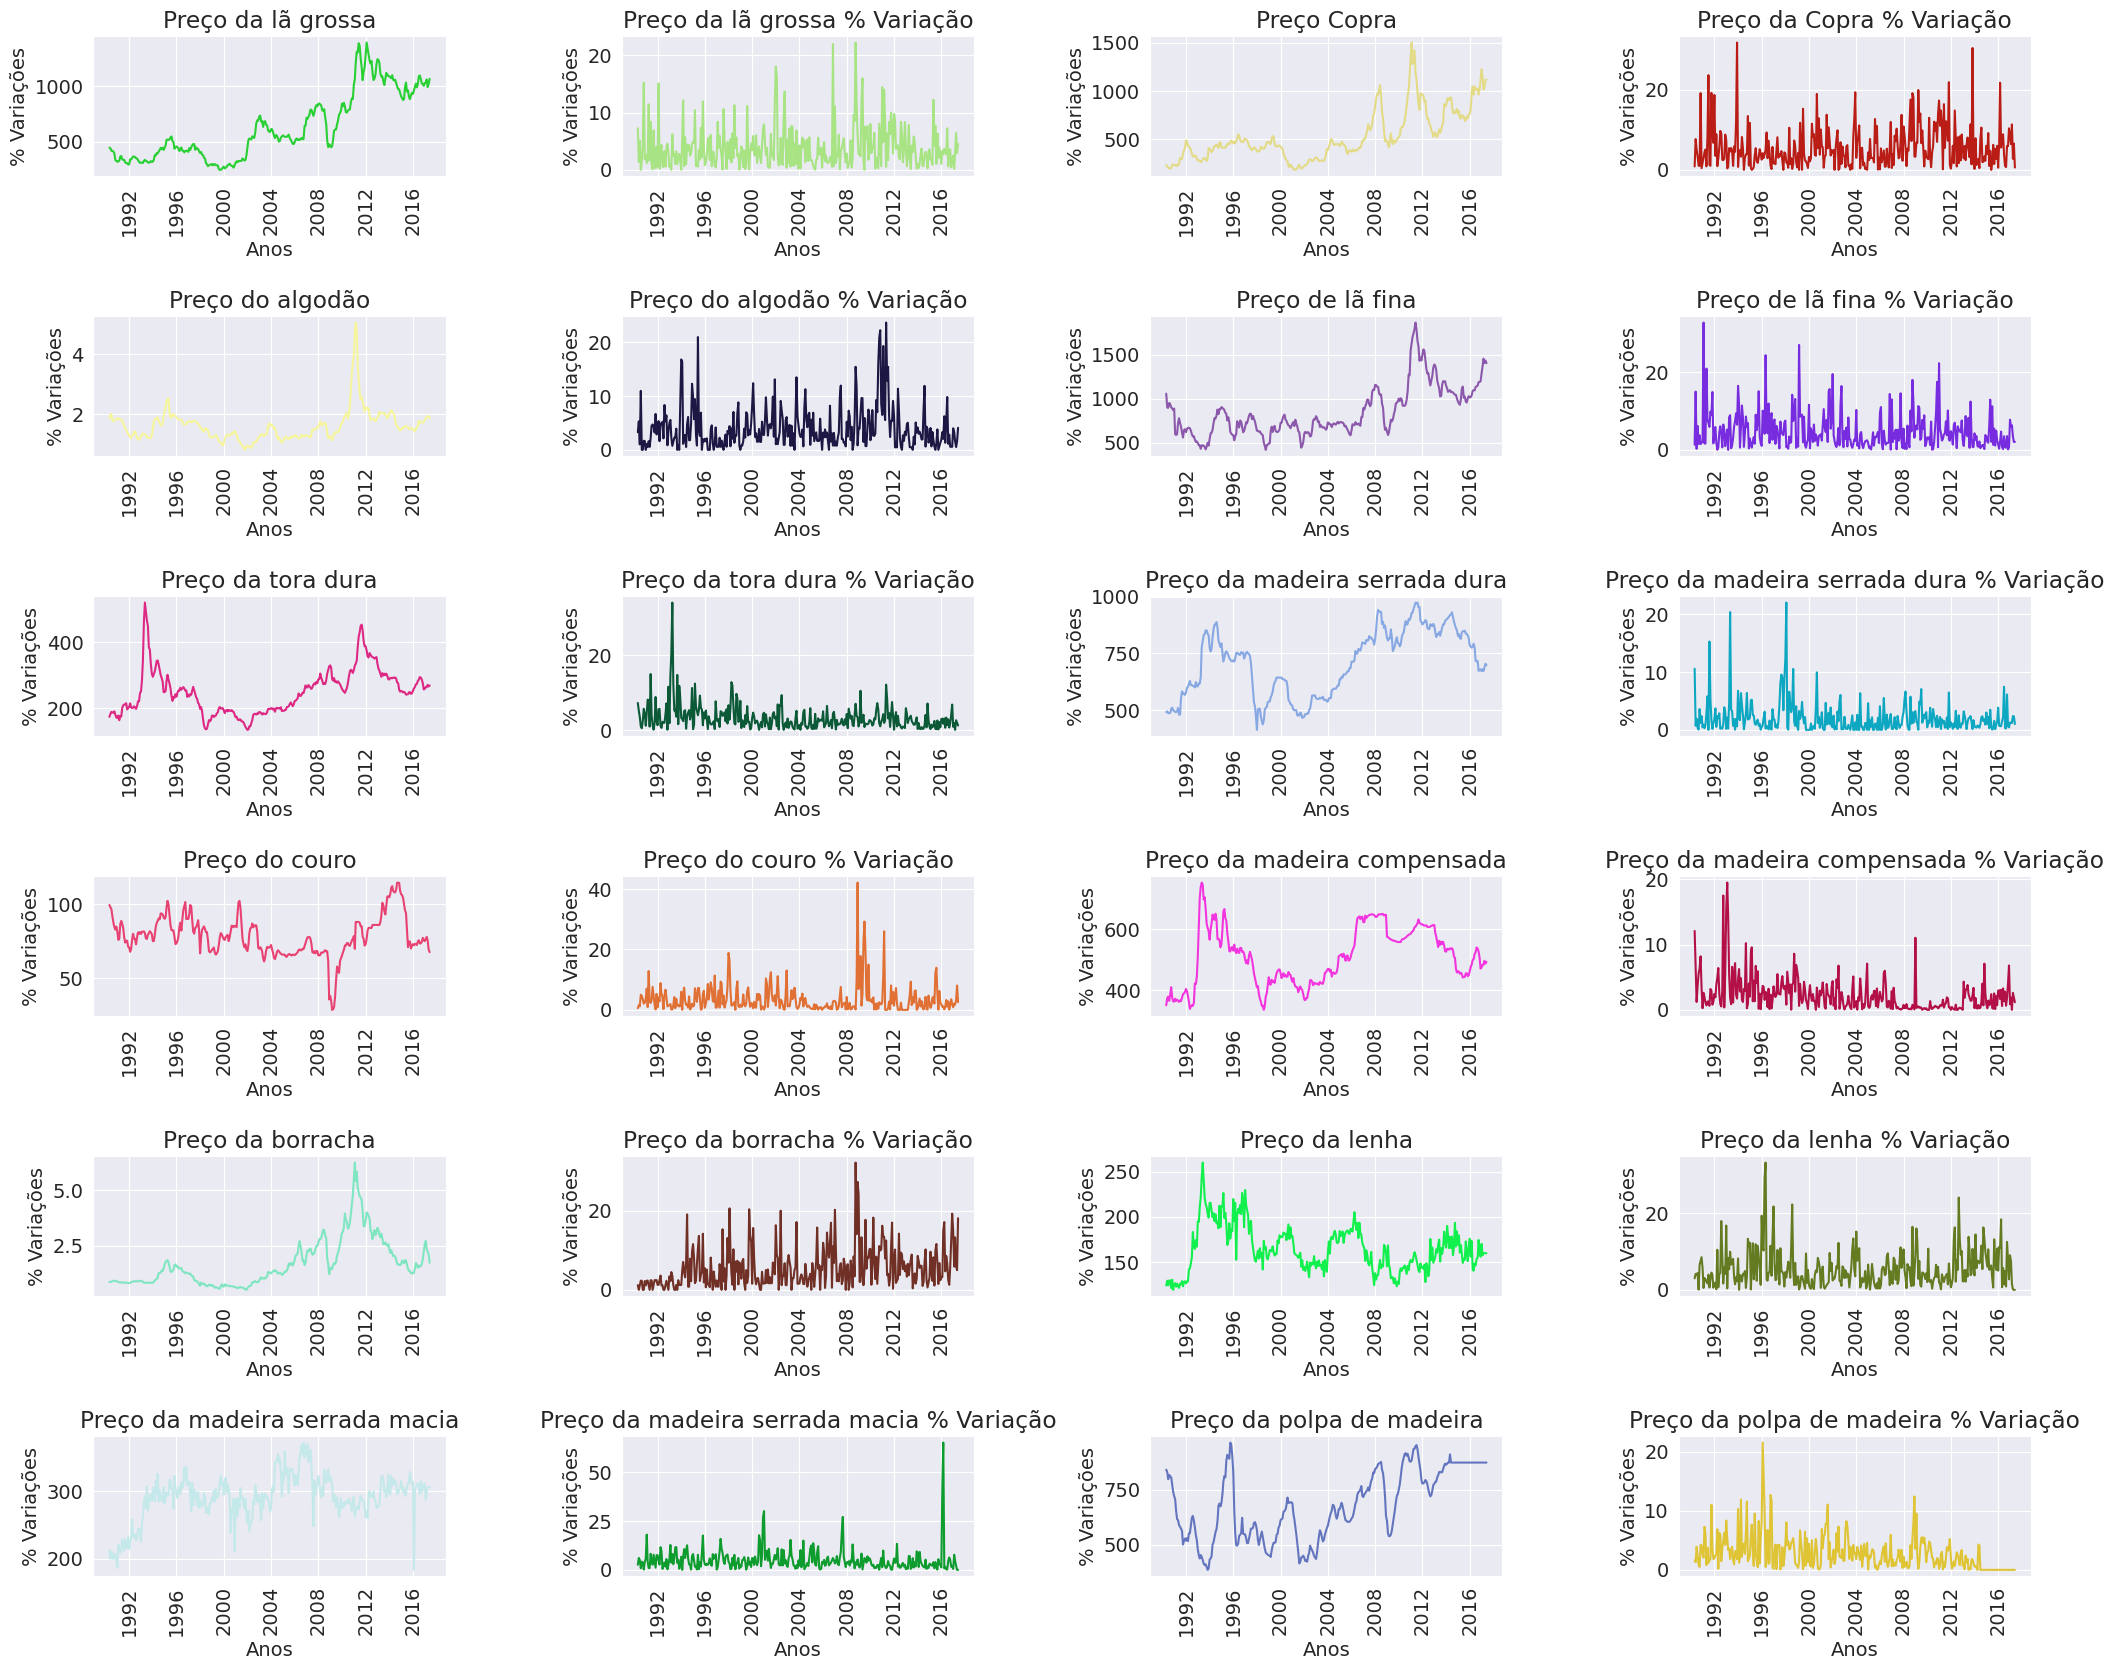

In [81]:
# Criando a Figura e Subplots
plt.figure(figsize=(25,20))

# Plotando gráficos
for i in range(len(changelist)):

    r = random.random()
    b = random.random()
    g = random.random()
    color = (r, g, b)
    plt.subplot(6, 4, i + 1)
    plt.subplots_adjust( hspace=1 ,wspace=0.5)
    plt.plot(materiaPrima[changelist[i]],c=color)
    plt.xticks(rotation=90)
    plt.title(changelist[i])
    plt.xlabel('Anos')
    plt.ylabel('% Variações')

Análise visual dos gráficos:

 * A matéria-prima com a maior variação percentual parece ser a madeira serrada macia, que em alguns momentos atingiu picos de variação acima de 60%.
 * A matéria-prima com a menor variação percentual parece ser a madeira compensada, cujas variações percentuais parecem se manter abaixo de 20% na maioria do tempo.

Vamos gerar a estatísticas descritivas sobre as colunas de "% Variação", como o desvio padrão ou o intervalo máximo, para confirmar essas observações.

In [82]:
# Lista de colunas de variação percentual
changelist=['Preço da lã grossa % Variação', 'Preço da Copra % Variação', 'Preço do algodão % Variação', 'Preço de lã fina % Variação',
'Preço da tora dura % Variação', 'Preço da madeira serrada dura % Variação', 'Preço do couro % Variação',
'Preço da madeira compensada % Variação', 'Preço da borracha % Variação', 'Preço da lenha % Variação', 'Preço da madeira serrada macia % Variação',
'Preço da polpa de madeira % Variação']

# Selecionando apenas as colunas de variação percentual
materiaPrima_change = materiaPrima[changelist]

# Calculando estatísticas descritivas focando no desvio padrão e valor máximo
change_stats = materiaPrima_change.describe().loc[['std', 'max']]

# Exibindo as estatísticas
print("Estatísticas descritivas para as colunas de % Variação (Desvio Padrão e Máximo):")
display(change_stats)

Estatísticas descritivas para as colunas de % Variação (Desvio Padrão e Máximo):


,Preço da lã grossa % Variação,Preço da Copra % Variação,Preço do algodão % Variação,Preço de lã fina % Variação,Preço da tora dura % Variação,Preço da madeira serrada dura % Variação,Preço do couro % Variação,Preço da madeira compensada % Variação,Preço da borracha % Variação,Preço da lenha % Variação,Preço da madeira serrada macia % Variação,Preço da polpa de madeira % Variação
std,3.62882,5.091321,3.930971,4.698225,3.423842,2.653746,4.535649,2.659446,5.185055,4.768734,5.7737,2.890238
max,22.25000,31.820000,23.640000,32.840000,34.190000,21.960000,42.140000,19.500000,32.160000,33.210000,65.2400,21.570000


Podemos ver na linha 'max' que a 'Preço da madeira serrada macia % Variação' tem o maior valor (65.24), o que confirma a observação de que ela teve os picos de variação mais altos. O desvio padrão para 'Preço da madeira serrada macia % Variação' (5.77) também é um dos mais altos, indicando alta volatilidade.

Olhando para a linha 'max', a 'Preço da madeira compensada % Variação' tem um valor máximo relativamente baixo (19.50), e seu desvio padrão (2.66) também é um dos menores, confirmando a observação de que ela teve menor variação.

## **4) Encontre as matérias-primas com mudança drástica de preço**

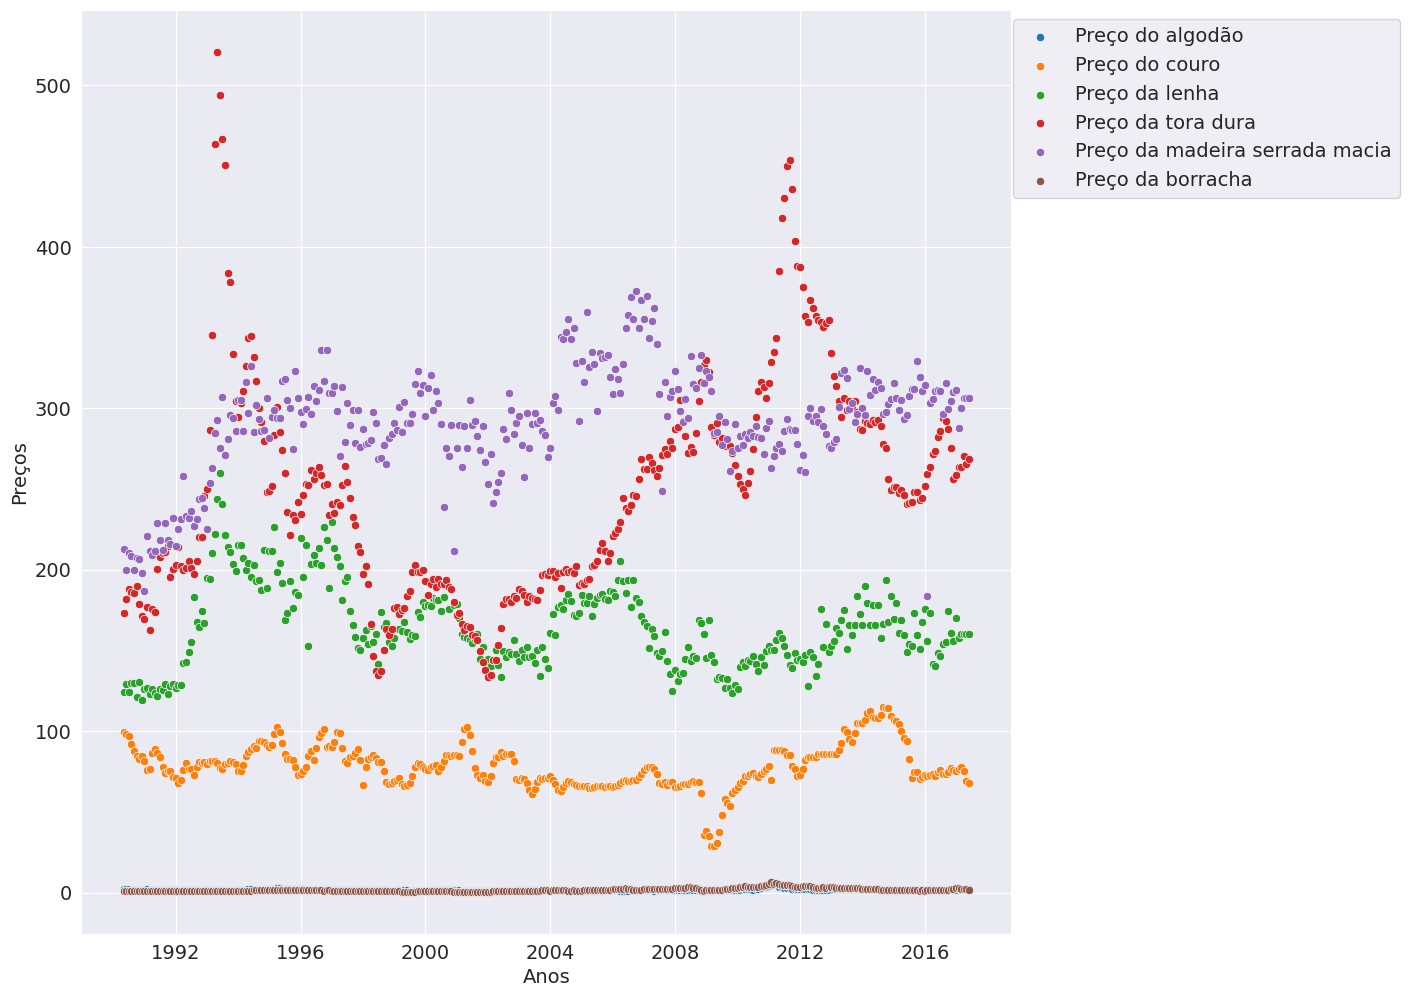

In [83]:
# Lista de materiais de baixo preço
lowlist=['Preço do algodão','Preço do couro','Preço da lenha','Preço da tora dura','Preço da madeira serrada macia','Preço da borracha']

# Criando a Figura e Subplots
plt.figure(figsize=(12,12))
plt.ylabel('Preços')
plt.xlabel('Anos')

# Plotando o gráfico de dispersão
for i in range(len(lowlist)):
    sns.scatterplot(y=materiaPrima[lowlist[i]],x=materiaPrima.index);
    plt.legend(lowlist,loc='upper center',bbox_to_anchor=(1.21,1))

Ao observar esse gráfico, você pode analisar a evolução do preço de cada matéria-prima de baixo preço individualmente ao longo do tempo. Você pode identificar tendências, picos, quedas e a dispersão dos preços para cada material sem a sobreposição que ocorreria se todos fossem plotados no mesmo gráfico. Isso facilita a visualização de padrões específicos para cada matéria-prima neste grupo.

O material com a mudança de preço mais drástica é o 'Preço da tora dura'.

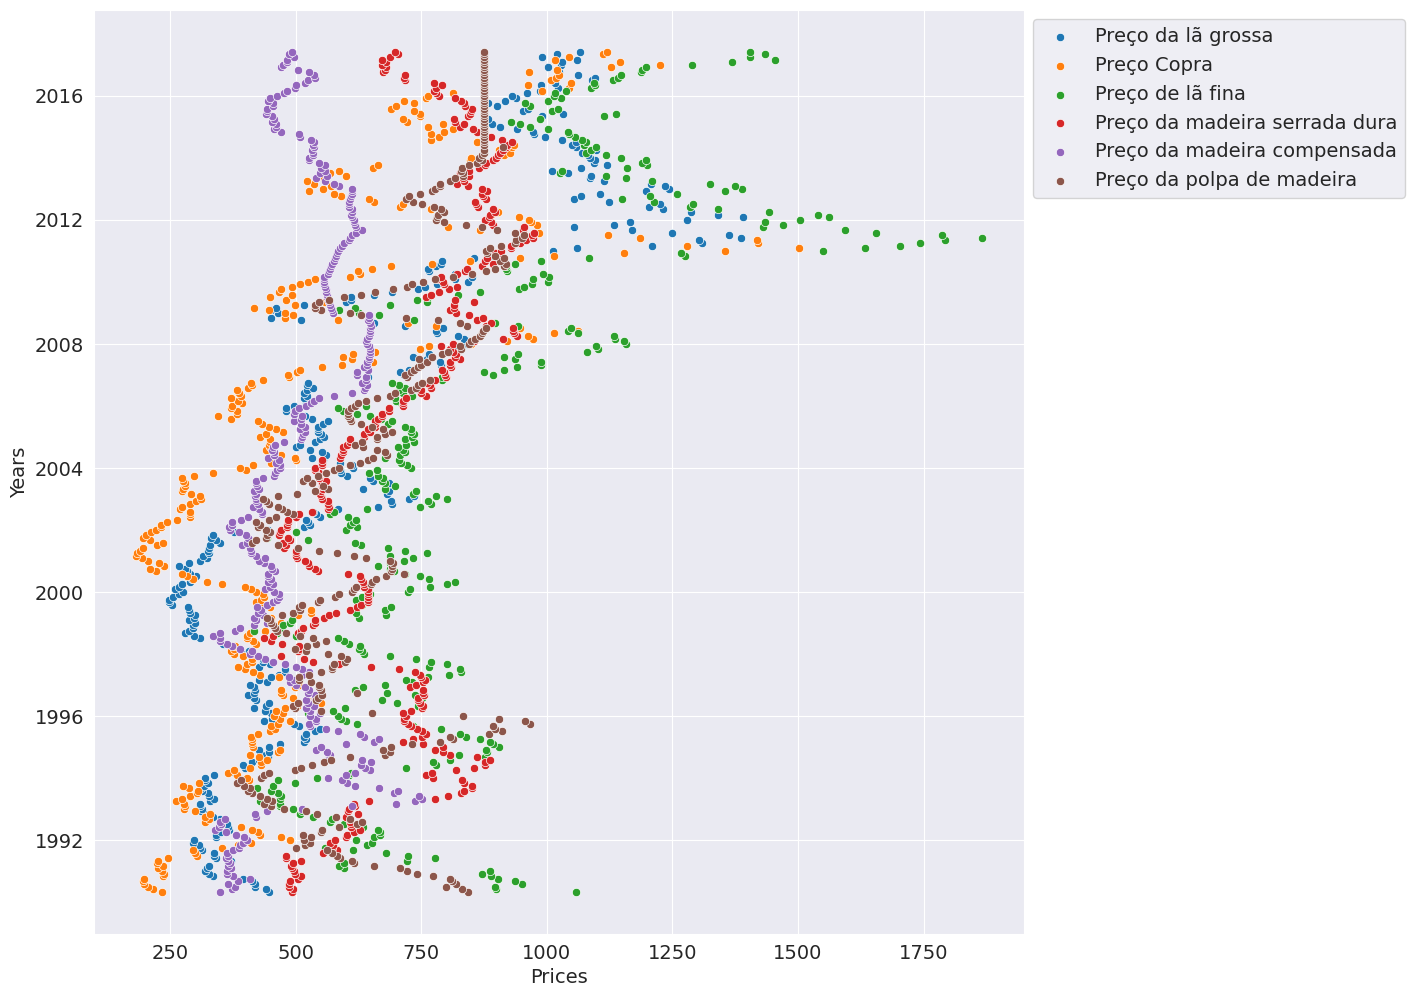

In [84]:
# Lista de materiais de alto preço
highlist=['Preço da lã grossa', 'Preço Copra', 'Preço de lã fina', 'Preço da madeira serrada dura', 'Preço da madeira compensada', 'Preço da polpa de madeira']

# Criando a Figura e Subplots
plt.figure(figsize=(12,12))
plt.xlabel('Prices')
plt.ylabel('Years')

#plotando o gráfico de dispersão
for i in range(len(highlist)):
    sns.scatterplot(x=materiaPrima[highlist[i]],y=materiaPrima.index);
    plt.legend(highlist,loc='upper center',bbox_to_anchor=(1.21,1))

Ao observar esse gráfico, você pode analisar a evolução do preço de cada matéria-prima de alto preço individualmente ao longo do tempo. Isso permite identificar tendências, picos, quedas e a dispersão dos preços para cada material neste grupo específico, facilitando a comparação visual do comportamento dos preços entre eles. Você pode notar que a escala do eixo Y nesses gráficos tende a ser maior do que nos gráficos dos materiais de baixo preço, refletindo seus preços mais elevados.

O material com a mudança de preço mais drástica é o 'Preço de lã fina'.

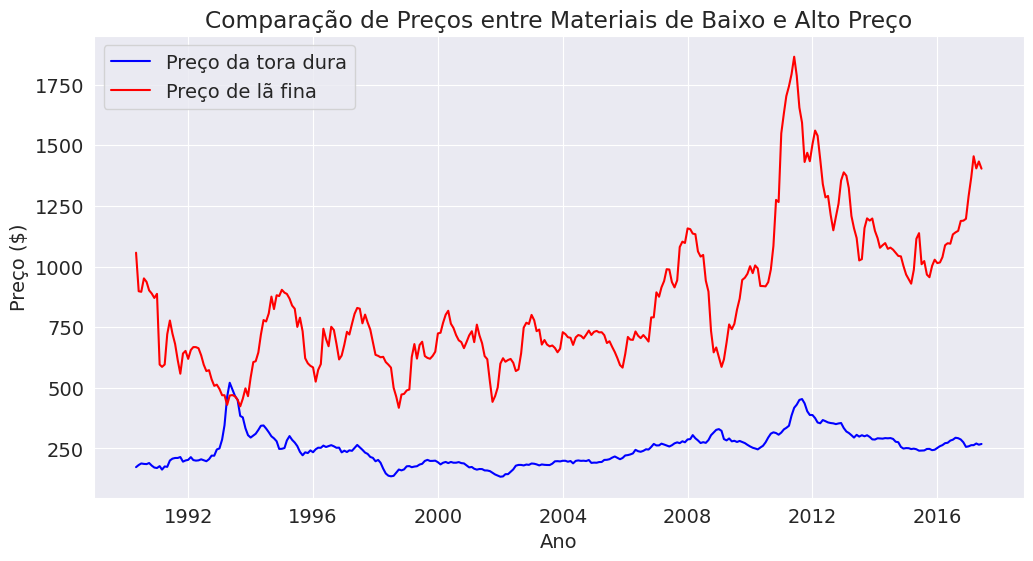

In [85]:
# Selecionando um material de baixo preço e um de alto preço para comparação
material_baixo_preco = 'Preço da tora dura'
material_alto_preco = 'Preço de lã fina'

# Criando a Figura e Subplots
plt.figure(figsize=(12, 6))

# Plotando a série temporal dos preços
plt.plot(materiaPrima.index, materiaPrima[material_baixo_preco], label=material_baixo_preco, color='blue')
plt.plot(materiaPrima.index, materiaPrima[material_alto_preco], label=material_alto_preco, color='red')

plt.title('Comparação de Preços entre Materiais de Baixo e Alto Preço')
plt.xlabel('Ano')
plt.ylabel('Preço ($)')
plt.legend()
plt.grid(True)
plt.show()

O gráfico gerado, mostra a série temporal do preço para o 'Preço da tora dura' (representante dos materiais de baixo preço com mudança drástica) e o 'Preço de lã fina' (representante dos materiais de alto preço com mudança drástica) em um único gráfico para comparação visual.

 * O eixo X representa o tempo (Ano).
 * O eixo Y representa o preço em dólares ($).
 * A linha azul mostra a evolução do 'Preço da tora dura' ao longo do tempo.
 * A linha vermelha mostra a evolução do 'Preço de lã fina' ao longo do tempo.

Ao observar este gráfico, podemos comparar diretamente:

 * A escala de preços: Veja a diferença geral na faixa de preço entre a tora dura e a lã fina. A lã fina opera em uma faixa de preço significativamente mais alta.
 * A magnitude das mudanças: Embora ambos tenham sido identificados como tendo mudanças drásticas dentro de seus grupos, você pode comparar visualmente a amplitude das oscilações de preço em termos de valores absolutos. A lã fina, por ter um preço base mais alto, pode apresentar variações absolutas maiores, mesmo que a variação percentual não seja necessariamente a mais alta de todas as matérias-primas.

Este gráfico ajuda a colocar as "mudanças drásticas" em perspectiva, comparando a volatilidade de preços entre um material de baixa faixa de preço e um de alta faixa de preço no mesmo período.

A mudança de preço é drástica para o preço de tora dura entre materiais de baixa faixa de preço e entre materiais de alto preço, são os preços de lã fina.

## **5) Descobrir a faixa de preço de matérias-primas de baixo preço**

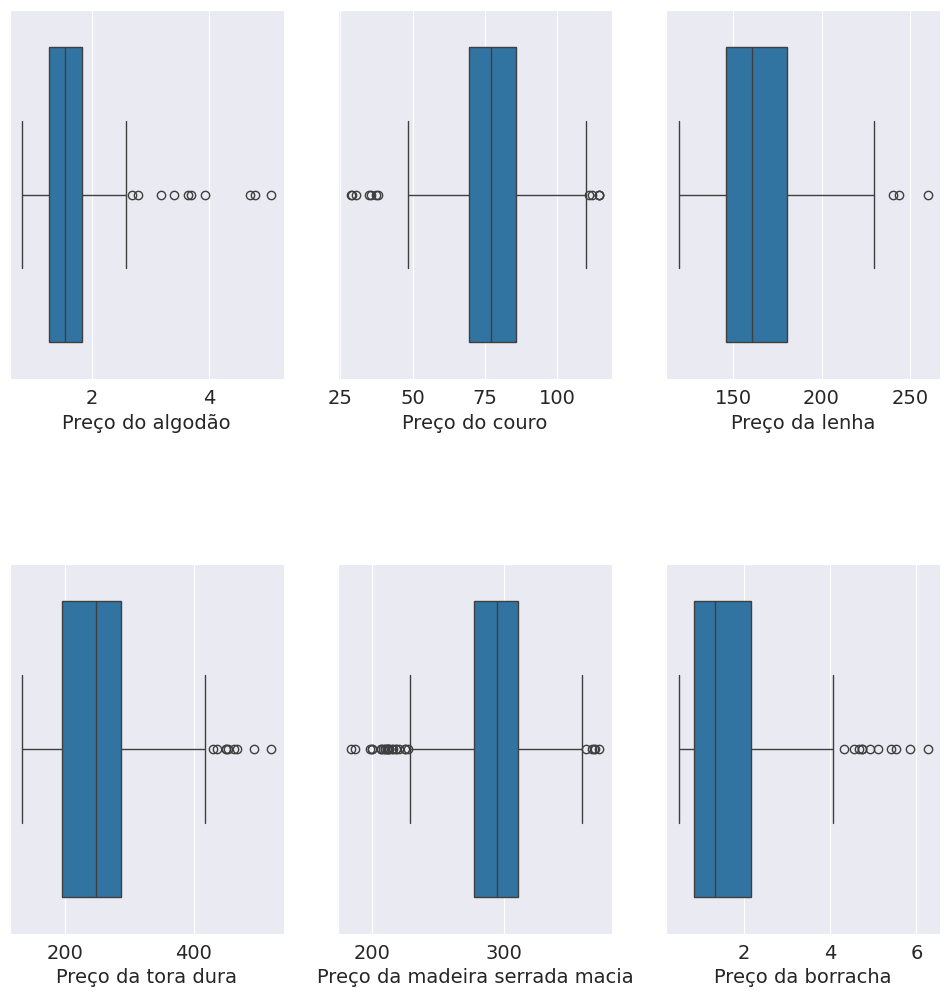

In [86]:
# Lista de materiais de baixo preço
lowlist=['Preço do algodão','Preço do couro','Preço da lenha','Preço da tora dura','Preço da madeira serrada macia','Preço da borracha']

# Criando a Figura e Subplots
plt.figure(figsize=(12,12))

#Plotando gráfico
for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.subplots_adjust( hspace=0.5 )
    sns.boxplot(x=materiaPrima[lowlist[i]])

Observando cada box plot no gráfico:

 * **Preço do algodão:** A faixa de preço (excluindo outliers) parece variar aproximadamente de 1.2 a 1.9 dólares. A caixa (50% central dos dados) está mais concentrada entre cerca de 1.3 e 1.8 dólares. Há alguns outliers acima de 2.5 e abaixo de 1.0.
 * **Preço do couro:** A faixa típica de preço (excluindo outliers) parece estar entre 60 e 90 dólares. A maioria dos dados (caixa) se encontra entre aproximadamente 70 e 85 dólares. Há outliers abaixo de 50 e acima de 100.
 * **Preço da lenha:** A faixa de preço (excluindo outliers) parece variar aproximadamente de 140 a 180 dólares. A caixa está mais concentrada entre cerca de 150 e 175 dólares.
 * **Preço da tora dura:** A faixa típica de preço parece estar entre 180 e 300 dólares (excluindo outliers). A caixa está entre aproximadamente 190 e 280 dólares. Há alguns outliers acima de 350.
 * **Preço da madeira serrada macia:** A faixa de preço (excluindo outliers) parece variar aproximadamente de 260 a 320 dólares. A caixa está mais concentrada entre cerca de 270 e 310 dólares. Há outliers abaixo de 200.
 * **Preço da borracha:** A faixa de preço (excluindo outliers) parece variar aproximadamente de 0.7 a 2.2 dólares. A caixa está mais concentrada entre cerca de 0.8 e 2.1 dólares. Há outliers acima de 3.0.

Analisando os box plots, podemos visualizar a distribuição dos preços para cada matéria-prima de baixo preço, identificando a mediana, os quartis, a faixa típica de variação e a presença de outliers, o que nos permite entender a faixa de preço observada ao longo do tempo para este grupo.
Preço do algodão apresenta a faixa de preço mais baixa entre este grupo.

## **6) Descobrir a faixa de preço de matérias-primas de alto preço**

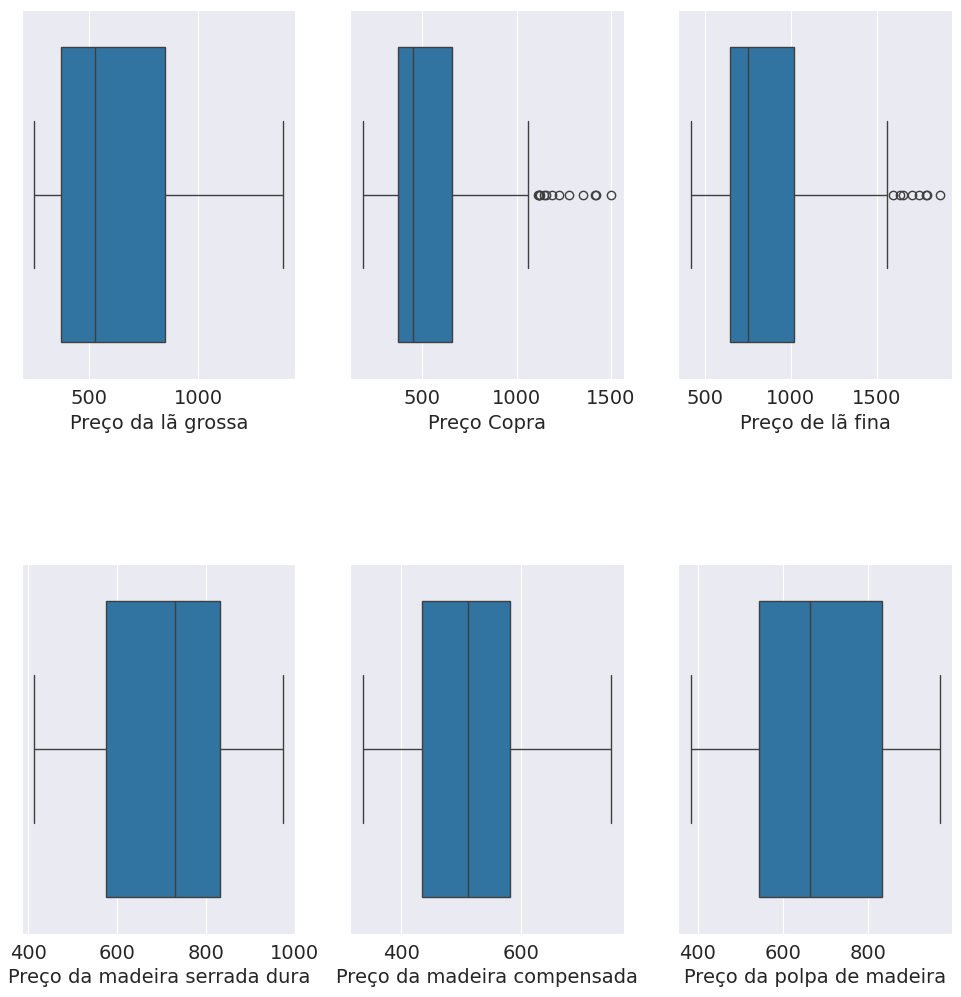

In [87]:
highlist=['Preço da lã grossa', 'Preço Copra', 'Preço de lã fina', 'Preço da madeira serrada dura', 'Preço da madeira compensada', 'Preço da polpa de madeira']

# Criando a Figura e Subplots
plt.figure(figsize=(12,12))

#Plotando gráfico
for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.subplots_adjust( hspace=0.5 )
    sns.boxplot(x=materiaPrima[highlist[i]])

Observando cada box plot no gráfico:

 * **Preço da lã grossa:** A faixa de preço (excluindo outliers) parece variar aproximadamente de 350 a 1100 dólares. A caixa (50% central dos dados) está mais concentrada entre cerca de 400 e 900 dólares. Há alguns outliers acima de 1200 dólares.
 * **Preço Copra:** A faixa típica de preço (excluindo outliers) parece estar entre 350 e 1000 dólares. A maioria dos dados (caixa) se encontra entre aproximadamente 370 e 660 dólares. Há outliers acima de 1200 dólares.
 * **Preço de lã fina:** Este material tem a faixa de preço mais alta entre os mostrados, variando aproximadamente de 600 a 1600 dólares (excluindo outliers). A caixa está concentrada entre cerca de 650 e 1000 dólares. Há outliers acima de 1700 dólares.
 * **Preço da madeira serrada dura:** A faixa típica de preço parece estar entre 450 e 850 dólares (excluindo outliers). A caixa está entre aproximadamente 550 e 750 dólares.
 * **Preço da madeira compensada:** A faixa de preço (excluindo outliers) parece variar de 400 a 650 dólares. A caixa está mais concentrada entre cerca de 450 e 580 dólares.
 * **Preço da polpa de madeira:** A faixa de preço (excluindo outliers) parece variar de 400 a 950 dólares. A caixa está concentrada entre cerca de 550 e 830 dólares. Há outliers abaixo de 400 dólares.

Analisando os box plots, podemos visualizar a distribuição dos preços para cada matéria-prima de alto preço, identificando a mediana, os quartis, a faixa típica de variação e a presença de outliers, o que nos permite entender a faixa de preço observada ao longo do tempo. O Preço de lã fina apresenta a faixa de preço mais elevada entre este grupo.

## **Conclusão**
Este estudo realizou uma análise exploratória abrangente do dataset de Preços de Matérias-Primas Agrícolas entre 1990 e 2020, abordando desde o pré-processamento dos dados até a visualização de tendências e relações.

Inicialmente, os dados foram carregados e submetidos a um rigoroso processo de tratamento para lidar com valores ausentes, inconsistências de formato (como vírgulas e símbolos de porcentagem) e a padronização dos nomes das colunas para português, garantindo a qualidade e a usabilidade do dataset para análises subsequentes. A etapa de pré-processamento foi crucial para transformar os dados brutos em um formato limpo e estruturado, essencial para a extração de insights confiáveis.

A análise exploratória revelou características importantes dos preços das matérias-primas. Observamos que a maioria das matérias-primas apresenta uma variação percentual mensal relativamente baixa, com os picos de frequência dos histogramas concentrados abaixo de 5%. Isso indica uma estabilidade mensal predominante nos preços para grande parte dos materiais ao longo do período estudado.

Através da análise das estatísticas descritivas e dos gráficos de série temporal, foi possível categorizar as matérias-primas em grupos de "baixo preço" (como algodão, couro e borracha) e "alto preço" (incluindo lã grossa, lã fina e polpa de madeira), identificando o algodão como a matéria-prima de menor preço médio ao longo dos anos.

A investigação da volatilidade, quantificada pelo desvio padrão e valor máximo das variações percentuais, confirmou a madeira serrada macia como a matéria-prima com os picos de variação percentual mais elevados e maior volatilidade geral, enquanto a madeira compensada demonstrou ser a menos volátil. A identificação de matérias-primas com mudanças de preço "drásticas" — notavelmente a tora dura no grupo de baixo preço e a lã fina no grupo de alto preço — ressalta a importância de analisar a volatilidade tanto em termos percentuais quanto absolutos e dentro de suas faixas de preço características.

A análise de correlação, visualizada através do mapa de calor, foi fundamental para entender as relações lineares entre os preços das diferentes matérias-primas. Foi confirmado que o preço da lã grossa e da lã fina possuem uma forte correlação positiva (aproximadamente 0.89), indicando que seus preços tendem a se mover na mesma direção. Em contraste, pares como couro e borracha apresentaram correlação muito baixa, sugerindo pouca ou nenhuma relação linear em seus movimentos de preço.

Adicionalmente, a divisão dos dados em conjuntos de treinamento e teste baseada no tempo foi implementada, uma prática essencial para a modelagem preditiva de séries temporais, garantindo que o modelo seja treinado com dados históricos e avaliado em um período futuro simulado. A padronização das features foi aplicada posteriormente para escalar os dados, preparando-os para algoritmos de machine learning sensíveis à escala, enquanto se manteve a ordem temporal crucial para a análise de séries.

Em suma, este trabalho forneceu uma análise robusta do dataset de preços de matérias-primas agrícolas, revelando padrões de variação, volatilidade, faixas de preço e correlações entre os materiais. Os insights derivados são valiosos para a compreensão do comportamento histórico desses mercados e servem como base sólida para futuras análises preditivas ou financeiras.